# Imports

In [1]:
import numpy as np
import ripser
import gudhi as gd
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
import gudhi.representations as grepr
from tqdm import tqdm
import ruptures as rpt
import statsmodels.api as sm
from scipy.signal import welch

# Henon map

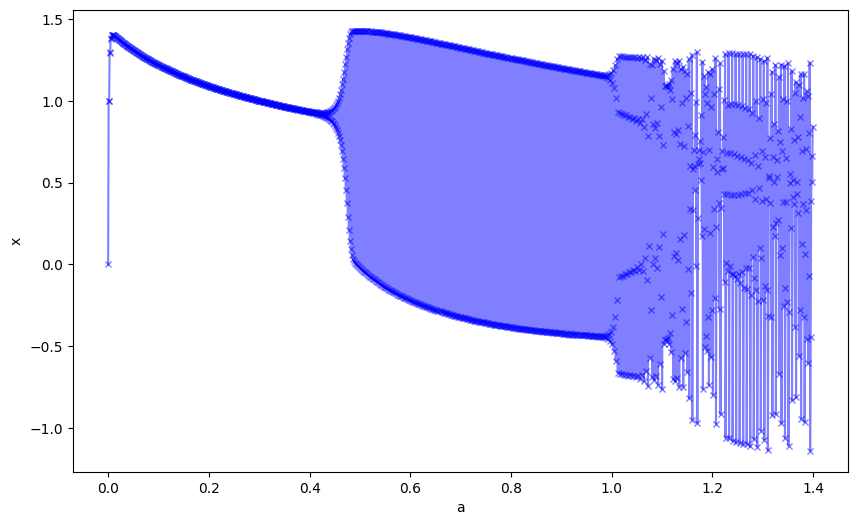

In [2]:
# parameters
b = 0.3
sigma = 0.01
step = 0.001
n_points = 1400

# initialize arrays
x = np.zeros(n_points)
y = np.zeros(n_points)
a = np.zeros(n_points)
gaussian_noise = np.random.normal(0, 1, n_points)

# compute henon map with varying 'a' parameter
for i in range(1, n_points):
    x[i] = 1 - a[i-1] * x[i-1]**2 + b * y[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step)
    y[i] = x[i-1] + sigma * gaussian_noise[i-1] * np.sqrt(step) 
    a[i] = a[i-1] + step

# plot the trajectory (x vs a)
plt.figure(figsize=(10, 6))
plt.plot(a, x, marker='x', markersize=4, linestyle='-', color='blue', alpha=0.5)
plt.xlabel("a")
plt.ylabel("x")
plt.savefig("plots/henon_map.png", dpi=300)
plt.show()

c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\gudhi\persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Figure size 800x600 with 0 Axes>

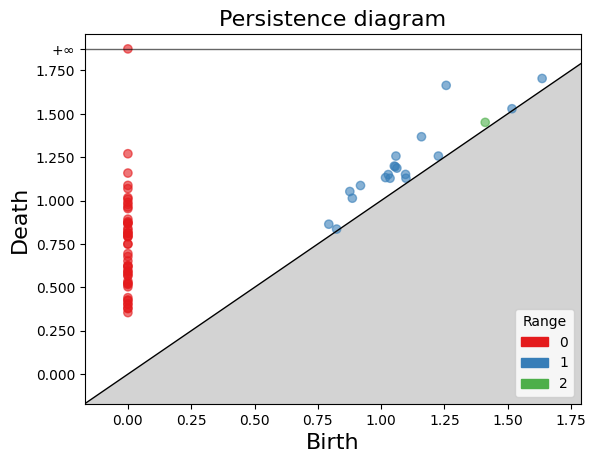

In [3]:
w = 50 # sliding window size
b_values = [0.27, 0.28, 0.29, 0.3] 

# initialize arrays for multiple b values
x = np.zeros((n_points, len(b_values)))
y = np.zeros((n_points, len(b_values)))
a = np.zeros((n_points, len(b_values)))
gaussian_noise = np.random.normal(0, 1, (n_points, len(b_values)))

# compute henon map for multiple b values
for j, b in enumerate(b_values):
    for i in range(1, n_points):
        x[i, j] = 1 - a[i-1, j] * x[i-1, j]**2 + b * y[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step)
        y[i, j] = x[i-1, j] + sigma * gaussian_noise[i-1, j] * np.sqrt(step) 
        a[i, j] = a[i-1, j] + step

# compute the persistence diagrams
diagrams = []
for i in range(w, n_points):
    window = x[i-w:i, :]  # shape (w, 4)
    rips = ripser.ripser(window, maxdim=2)
    diagrams.append(rips['dgms'])

# plot the persistence diagram of the last sliding window
plt.figure(figsize=(8, 6))
gd.plot_persistence_diagram(diagrams[-1])
plt.savefig("plots/henon_persistence_diagram.png", dpi=300)
plt.show()

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

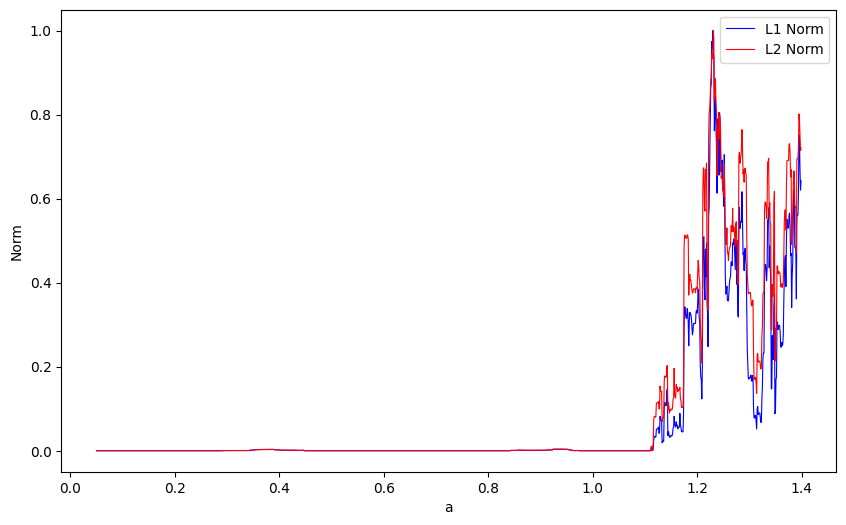

In [4]:
# compute the persistence landscapes L^1 and L^2 norms
l1_norms = []
l2_norms = []
for diag in diagrams:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms.append(np.sum(np.abs(landscape)))
    l2_norms.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms
l1_norms = (np.array(l1_norms) - np.min(l1_norms)) / (np.max(l1_norms) - np.min(l1_norms) + 1e-10)
l2_norms = (np.array(l2_norms) - np.min(l2_norms)) / (np.max(l2_norms) - np.min(l2_norms) + 1e-10)

# plot the L^1 and L^2 norms of the persistence landscapes over time
plt.figure(figsize=(10, 6))
plt.plot(a[w:, 0], l1_norms, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(a[w:, 0], l2_norms, label='L2 Norm', color='red', linewidth=0.8)
plt.xlabel("a")
plt.ylabel("Norm")
plt.legend()
plt.savefig("plots/henon_norms.png", dpi=300)
plt.show()

# Ising model

In [5]:
def ising_model_2d(n, m, temperature):
    "generate a vector representing m steps of a 2D Ising model with interactions at a given temperature"
    def metropolis_step(spins, beta):
        for _ in range(n * n):
            i = np.random.randint(0, n)
            j = np.random.randint(0, n)
            delta_E = 2 * spins[i, j] * (
                spins[(i + 1) % n, j] + spins[(i - 1) % n, j] +
                spins[i, (j + 1) % n] + spins[i, (j - 1) % n]
            )
            if delta_E < 0 or np.random.rand() < np.exp(-beta * delta_E):
                spins[i, j] *= -1
        return spins

    beta = 1.0 / temperature
    spins = np.random.choice([-1, 1], size=(n, n))
    configurations = []

    for _ in range(m):
        spins = metropolis_step(spins, beta)
        configurations.append(spins.copy().flatten())

    # return last configuration as a numpy array
    return np.array(configurations[-1])

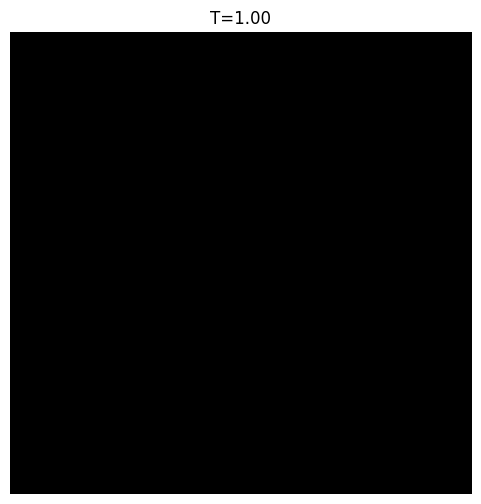

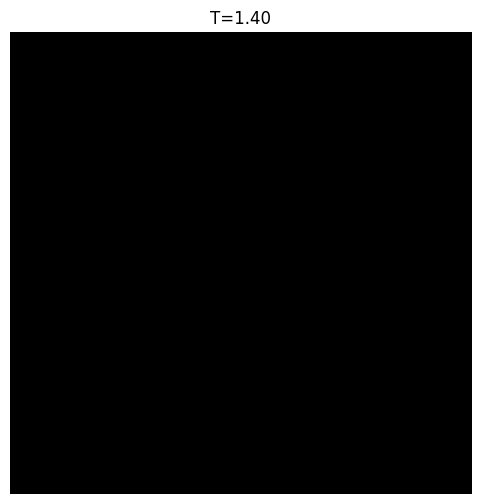

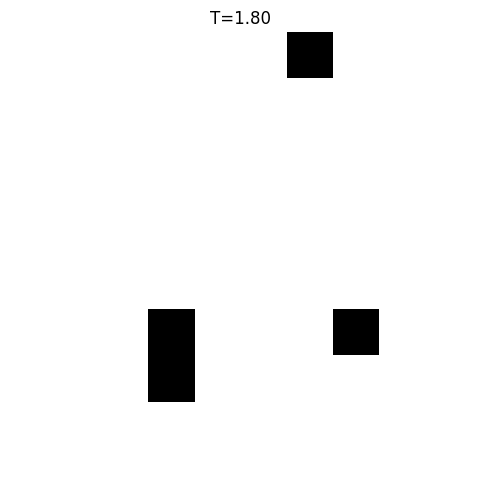

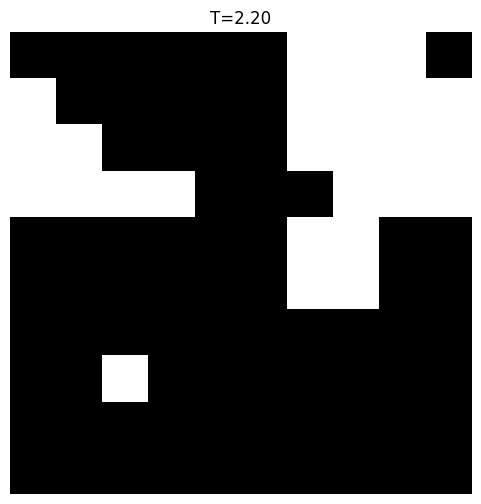

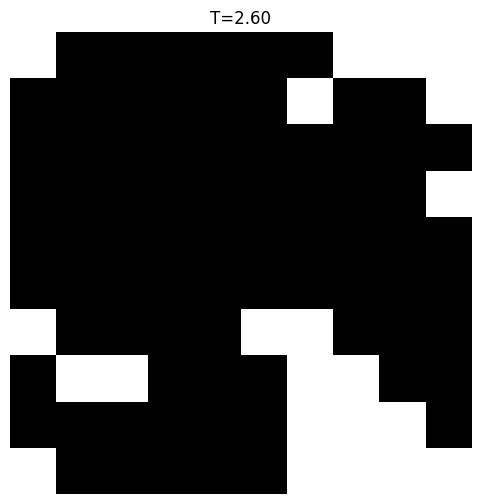

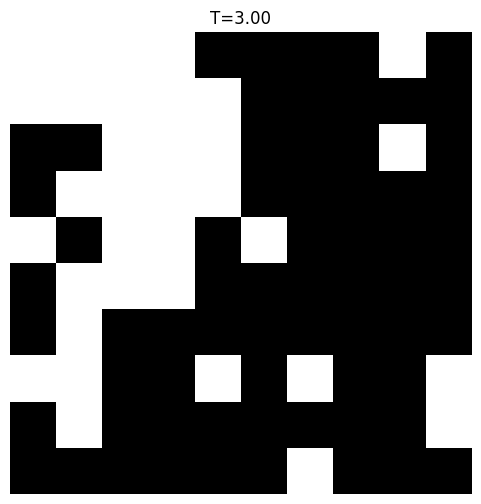

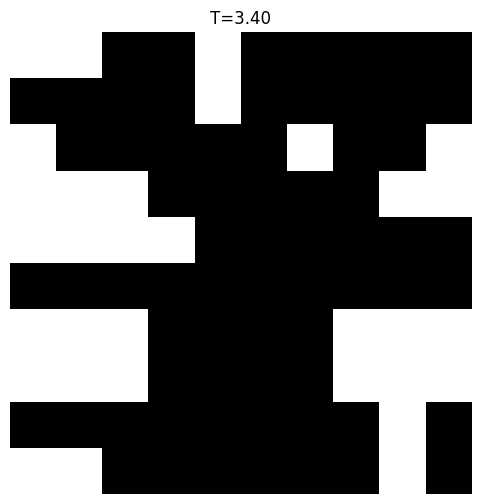

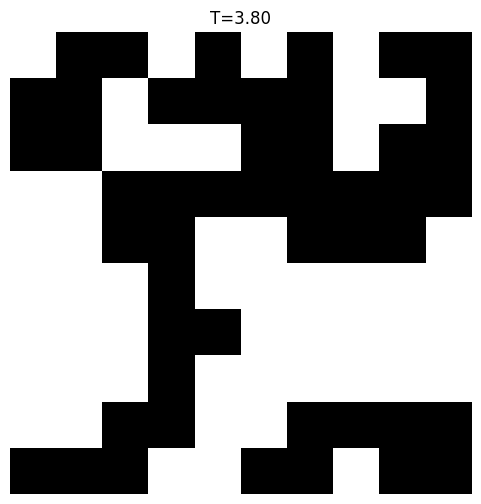

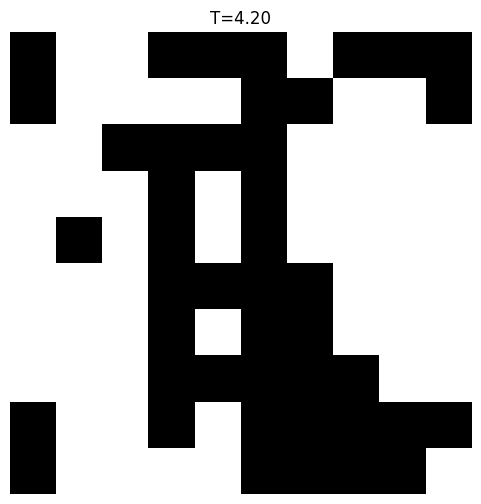

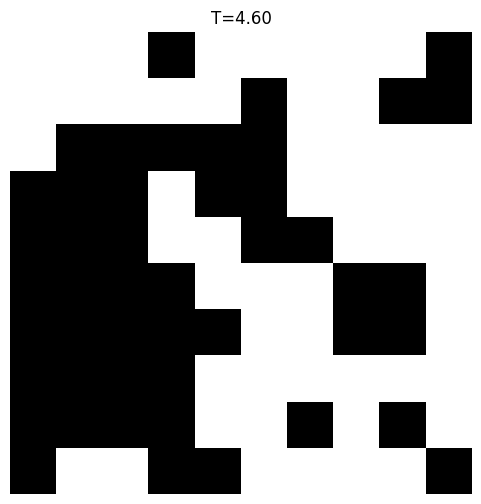

(1000, 100)


In [6]:
# generate dataset of Ising model configurations at different temperatures
X = np.zeros((1000, 100))
tempratures = np.linspace(1, 5, 1000)
for i, T in enumerate(tempratures):
    X[i] = ising_model_2d(10, 100, T).flatten()
    # visualize Ising model for every 100 steps
    if i % 100 == 0:
        plt.figure(figsize=(6, 6))
        plt.imshow(X[i].reshape(10, 10), cmap='gray')
        plt.title(f'T={T:.2f}')
        plt.axis('off')
        plt.show()
print(X.shape)

In [ ]:
# compute persistence diagrams over sliding windows
w = 50
diagrams_ising = []
for i in range(w, X.shape[0]):
    window = X[i-w:i, :]  # shape (w, n^2)
    rips = ripser.ripser(window, maxdim=2)
    diagrams_ising.append(rips['dgms'])

c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more columns than rows; did you mean to transpose?
  warnings.warn(
c:\Users\eliot\Desktop\MVA\Time Series\project\tda_finance\.venv\lib\site-packages\ripser\ripser.py:253: UserWarning: The input point cloud has more col

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is 

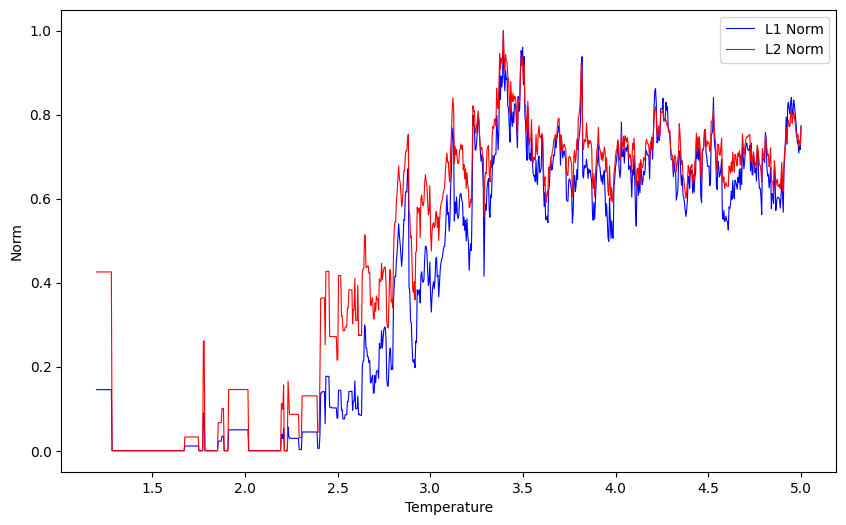

In [ ]:
# compute the persistence landscapes L^1 and L^2 norms
l1_norms_ising = []
l2_norms_ising = []

for diag in diagrams_ising:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_ising.append(np.sum(np.abs(landscape)))
    l2_norms_ising.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms
l1_norms_ising = (np.array(l1_norms_ising) - np.min(l1_norms_ising)) / (np.max(l1_norms_ising) - np.min(l1_norms_ising) + 1e-10)
l2_norms_ising = (np.array(l2_norms_ising) - np.min(l2_norms_ising)) / (np.max(l2_norms_ising) - np.min(l2_norms_ising) + 1e-10)

# plot the L^1 and L^2 norms of the persistence landscapes over temperature
plt.figure(figsize=(10, 6))
plt.plot(tempratures[w:], l1_norms_ising, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(tempratures[w:], l2_norms_ising, label='L2 Norm', color='red', linewidth=0.8)
plt.xlabel("Temperature")
plt.ylabel("Norm")
plt.legend()
plt.savefig("plots/ising_norms.png", dpi=300)
plt.show()

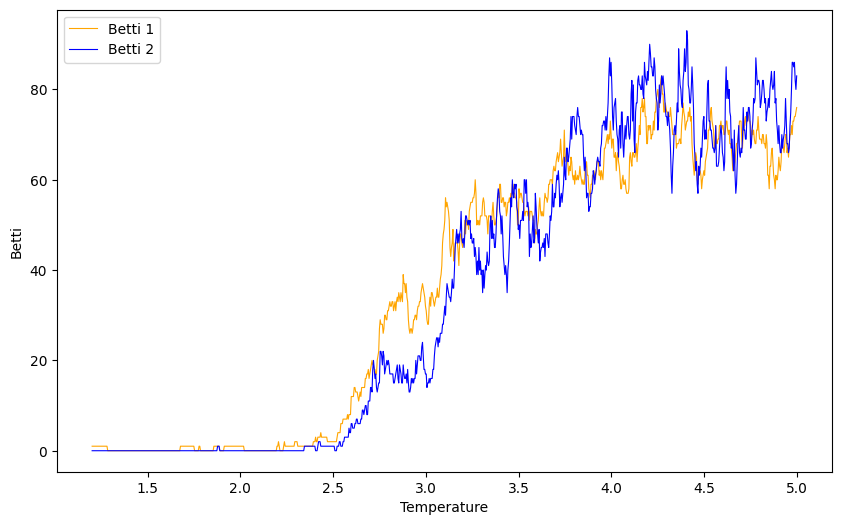

In [ ]:
# compute Betti numbers over time for Ising model
betti_1 = []
betti_2 = []
for diag in diagrams_ising:
    b1 = np.sum(diag[1][:, 1] - diag[1][:, 0] > 0)
    b2 = np.sum(diag[2][:, 1] - diag[2][:, 0] > 0)
    betti_1.append(b1)
    betti_2.append(b2)

# plot Betti numbers over temperature
plt.figure(figsize=(10, 6))
plt.plot(tempratures[w:], betti_1, label='Betti 1', color='orange', linewidth=0.8)
plt.plot(tempratures[w:], betti_2, label='Betti 2', color='blue', linewidth=0.8)
plt.xlabel("Temperature")
plt.ylabel("Betti")
plt.legend()
plt.savefig("plots/ising_betti.png", dpi=300)
plt.show()

# White noise with Gamma-distributed inverse variance

In [ ]:
X = []
num_clouds = 100
points_per_cloud = 100
scale_param = 8.0
beta_param = 1.0
M = 100 # number of Monte Carlo simulations

l1_norms_mc = []

for _ in range(M):
    X = []
    scale_param = 8.0
    for i in range(num_clouds):
        if i >= 75:
            # transition from "cold" to "heated" market state
            scale_param -= 0.25
        variances = np.random.gamma(shape=2.0, scale=scale_param, size=4)
        std_devs = np.sqrt(1 / variances)
        cloud = np.random.normal(loc=0.0, scale=std_devs, size=(points_per_cloud, 4))
        X.append(cloud)
    
    diagrams_mc = []
    for cloud in X:
        rips = ripser.ripser(cloud)
        diagrams_mc.append(rips['dgms'])

    l1_norms_temp = []
    for diag in diagrams_mc:
        pl = grepr.Landscape(num_landscapes=10, resolution=500)
        landscape = pl.fit_transform([diag[1]])[0]
        l1_norms_temp.append(np.sum(np.abs(landscape)))
    l1_norms_mc.append(l1_norms_temp)
    
l1_norms_mc = np.array(l1_norms_mc)
l1_norms = np.mean(l1_norms_mc, axis=0)
l1_norms = (l1_norms - np.mean(l1_norms)) / np.std(l1_norms)

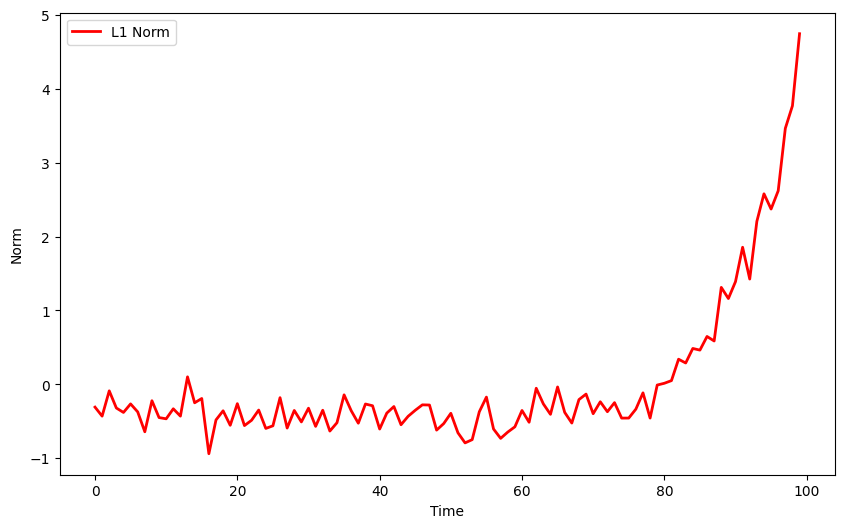

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(l1_norms, label='L1 Norm', color='red', linewidth=2)
plt.xlabel("Time")
plt.ylabel("Norm")
plt.legend()
plt.savefig("plots/invgamma_norms.png", dpi=300)
plt.show()

# Empirical analysis of financial data - Dotcom and Lehman Brothers crashes

In [12]:
# download financial data : SP500, Dow Jones, NASDAQ, Russell 2000, VIX
tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX']
data = yf.download(tickers, start='1987-12-23', end='2016-12-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_15088\2265281420.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='1987-12-23', end='2016-12-08')['Close']
[*********************100%***********************]  5 of 5 completed


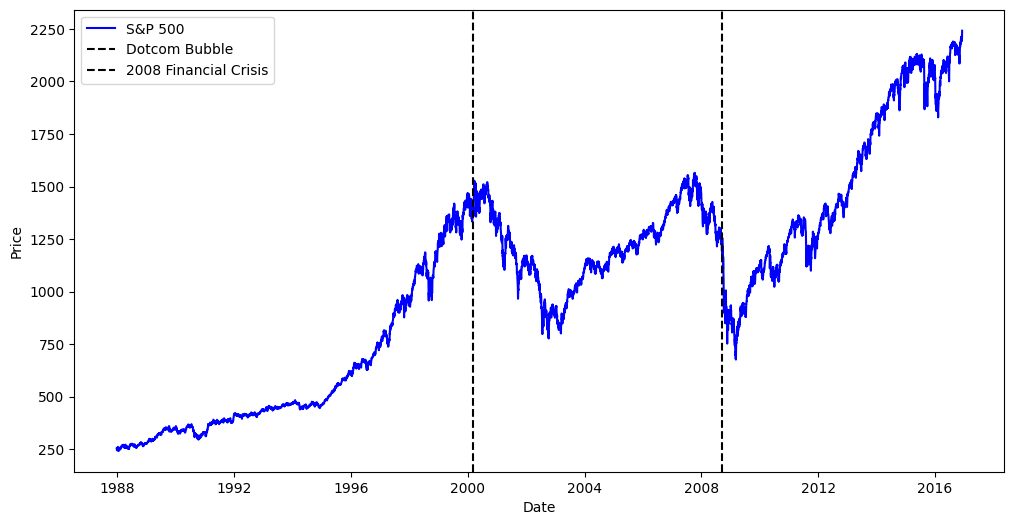

In [13]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^GSPC'], label='S&P 500', color='blue')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("plots/dotcom_sp500.png", dpi=300)
plt.show()

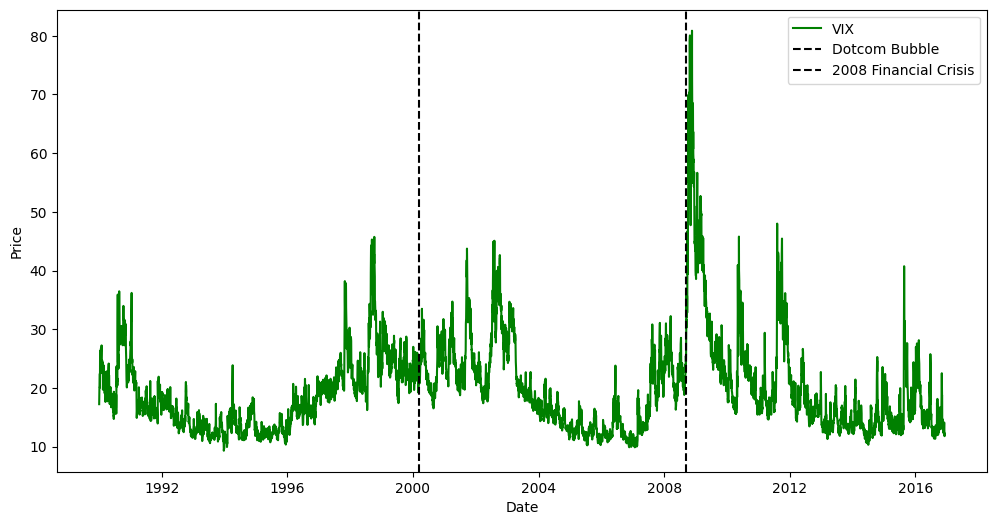

In [14]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='green')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("plots/dotcom_vix.png", dpi=300)
plt.show()

In [15]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).fillna(0)

 41%|████      | 2925/7200 [00:05<00:07, 546.98it/s]

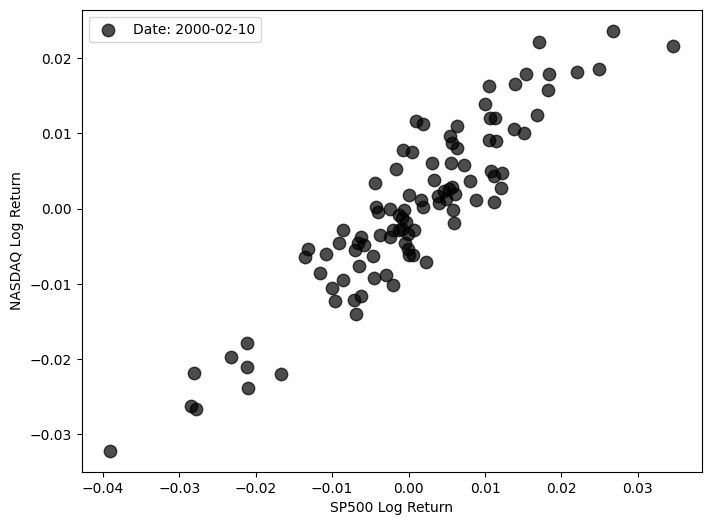

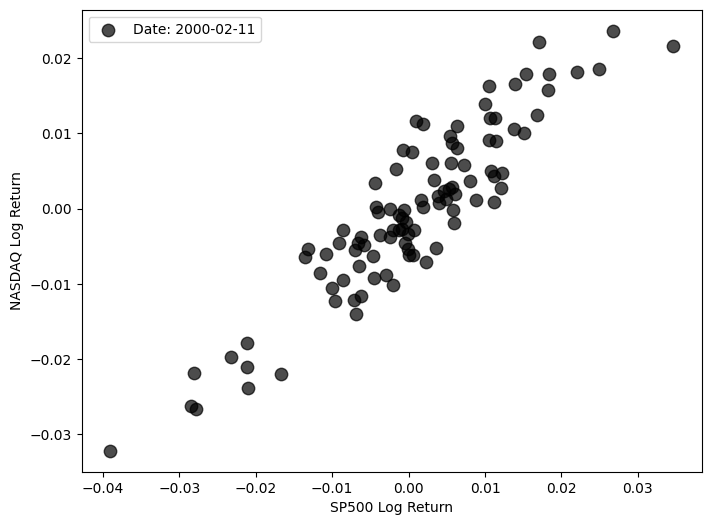

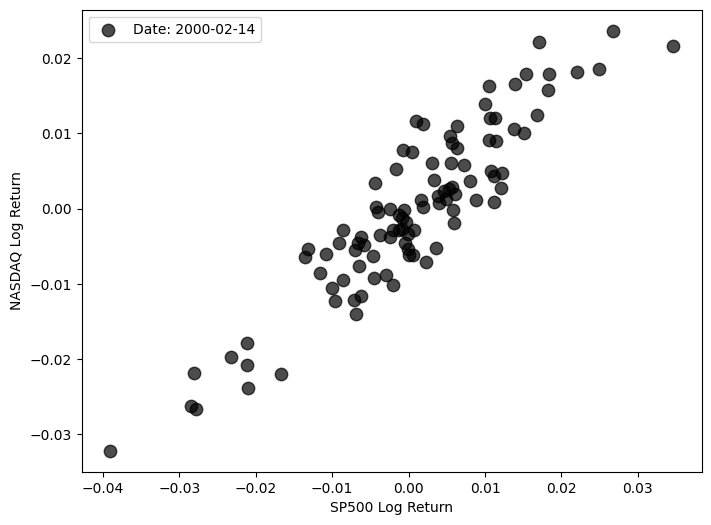

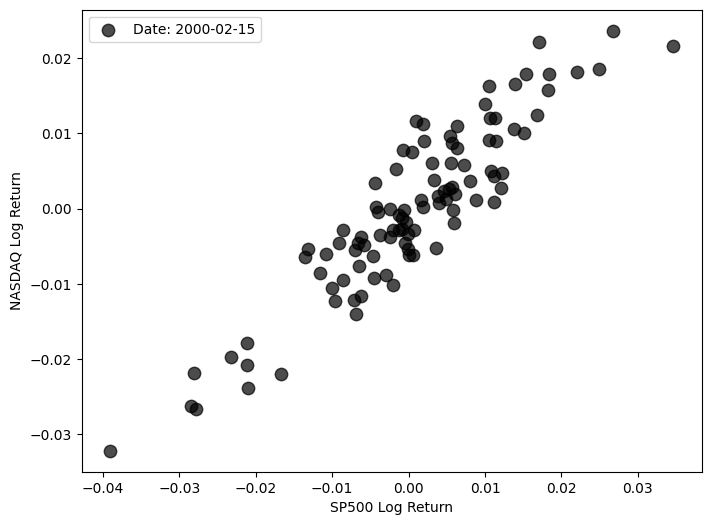

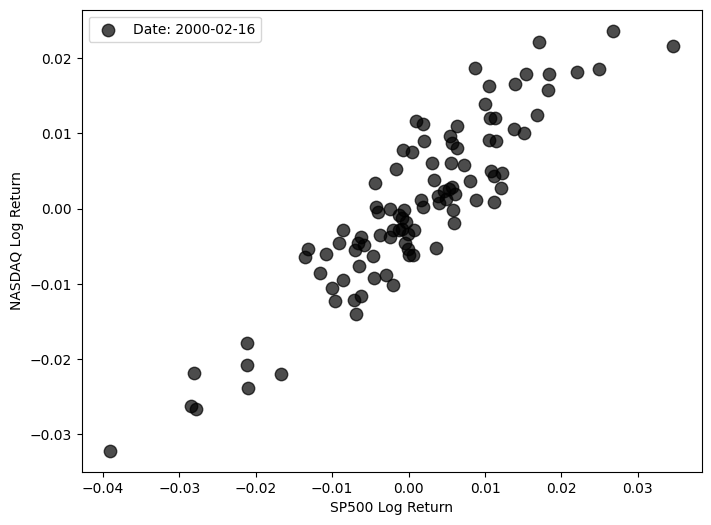

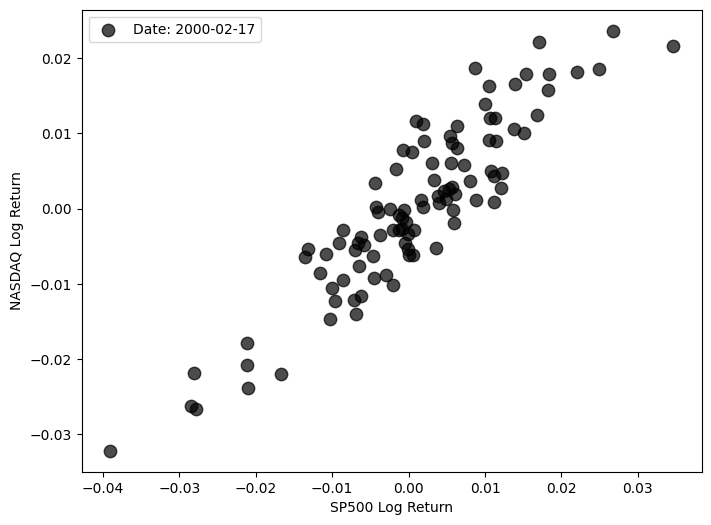

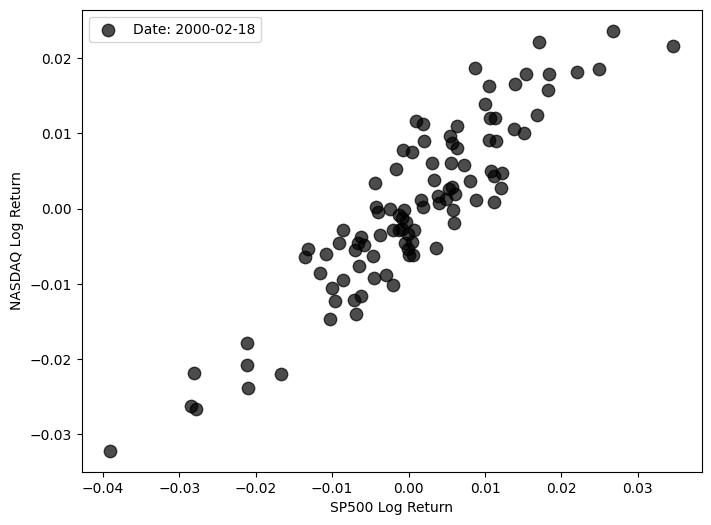

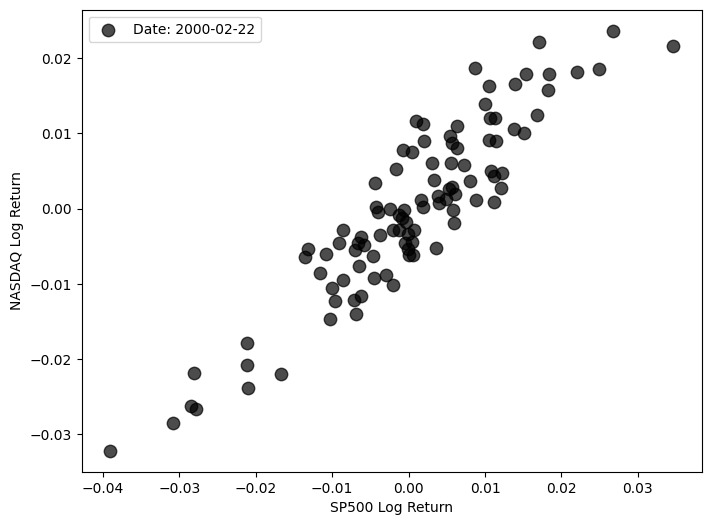

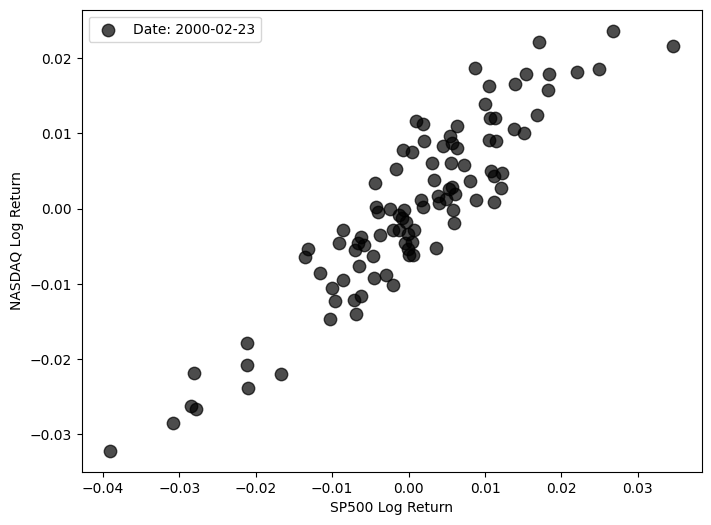

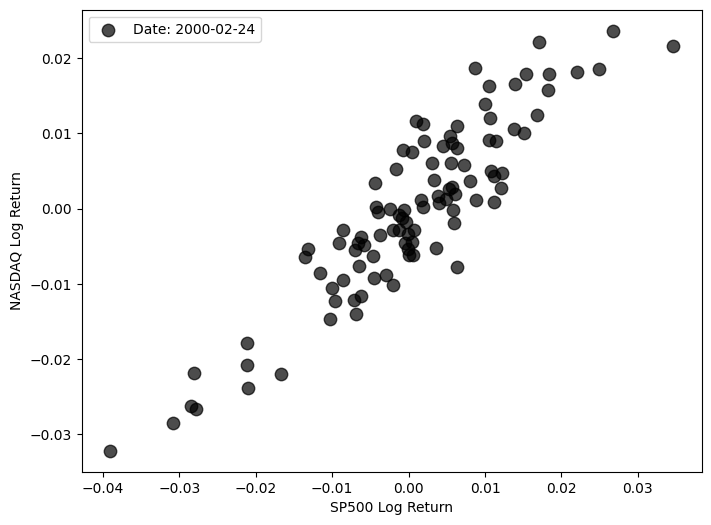

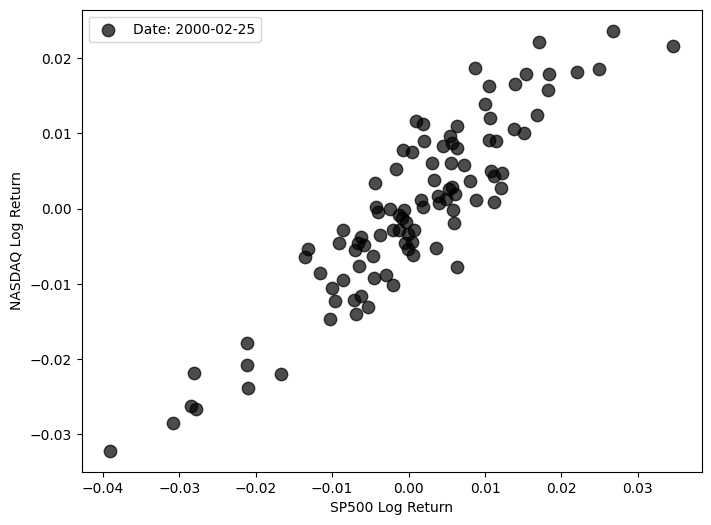

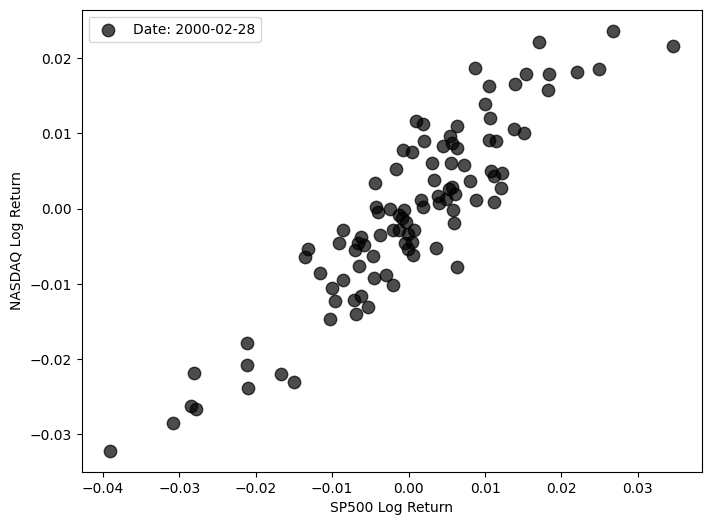

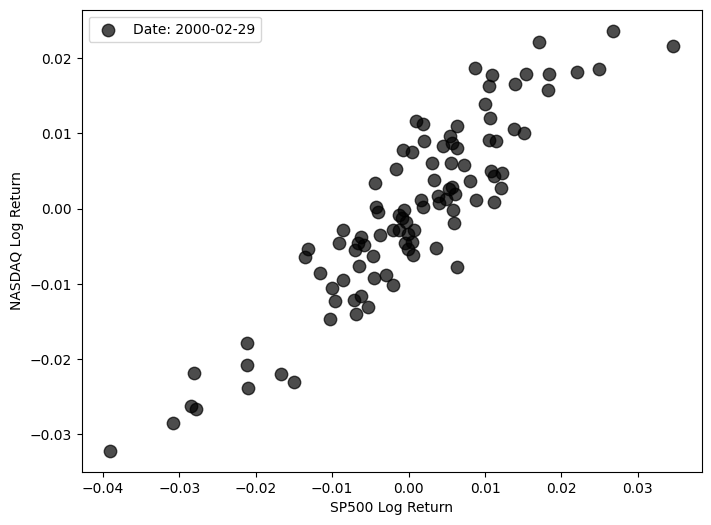

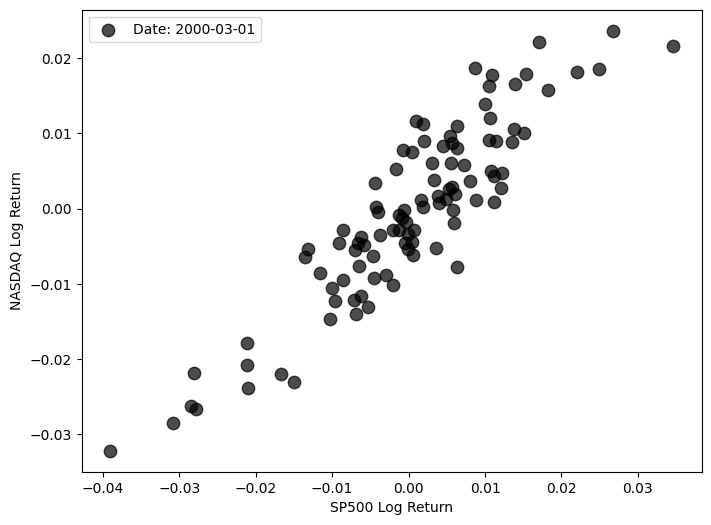

 41%|████▏     | 2980/7200 [00:06<00:24, 171.90it/s]

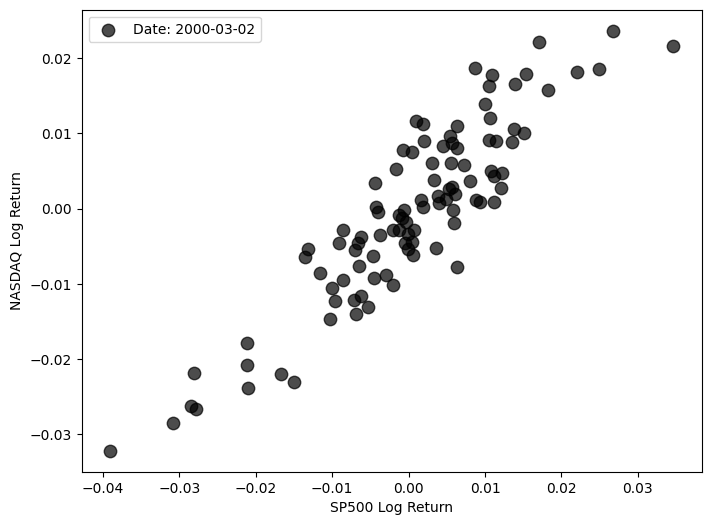

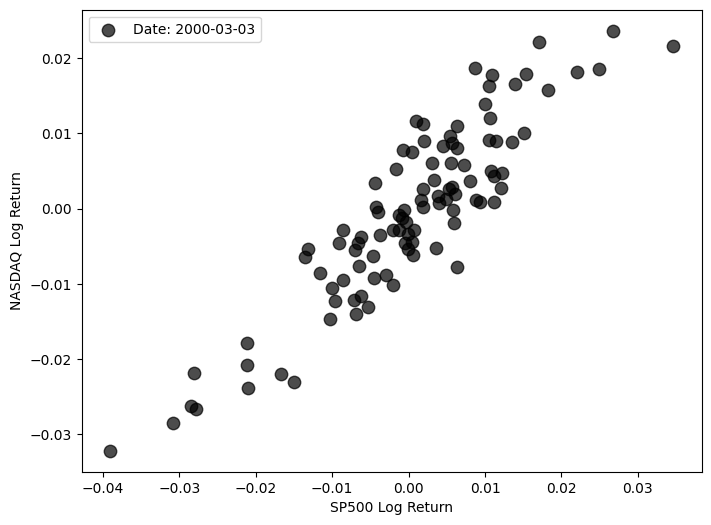

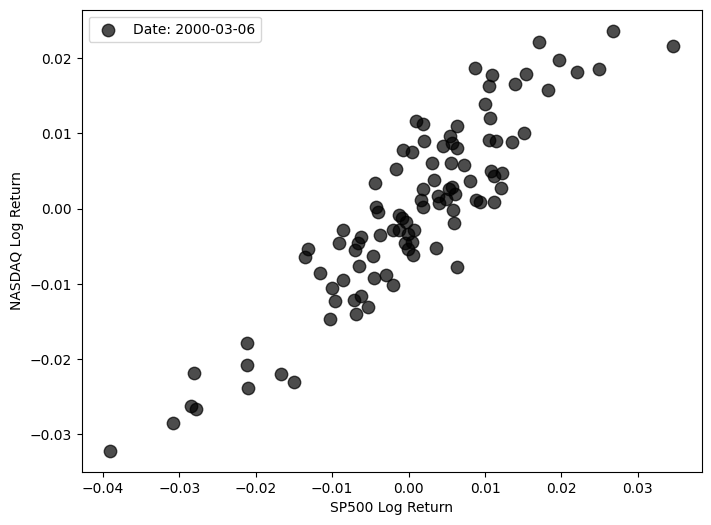

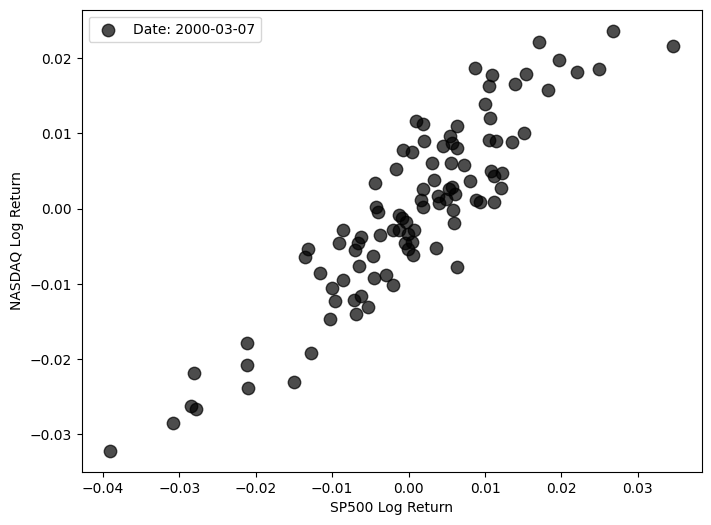

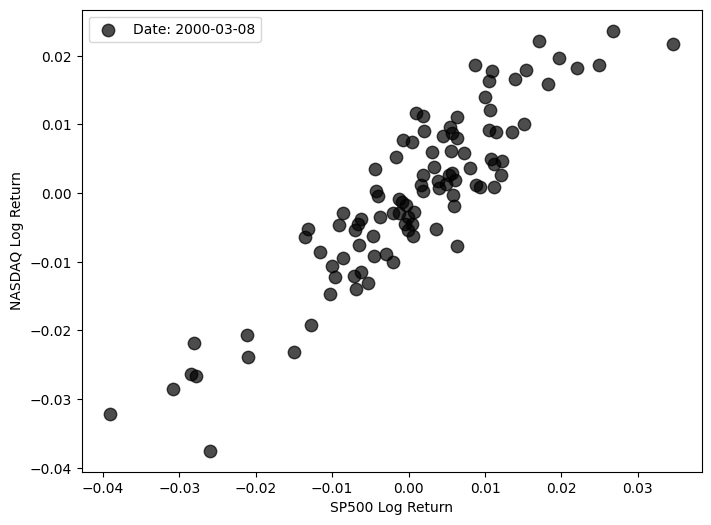

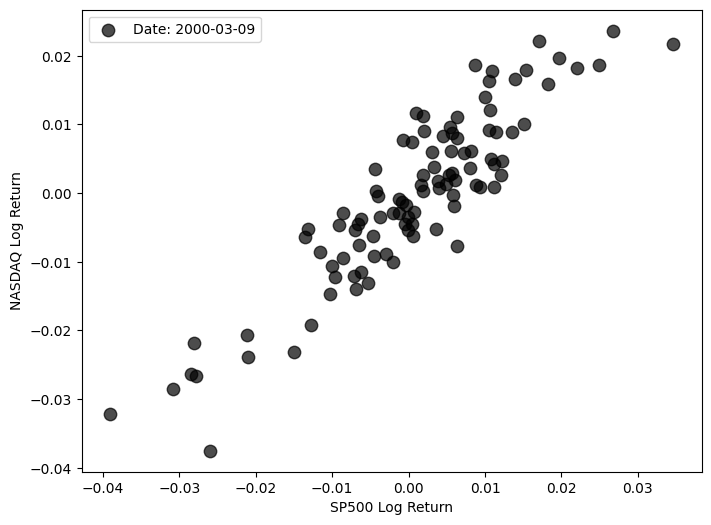

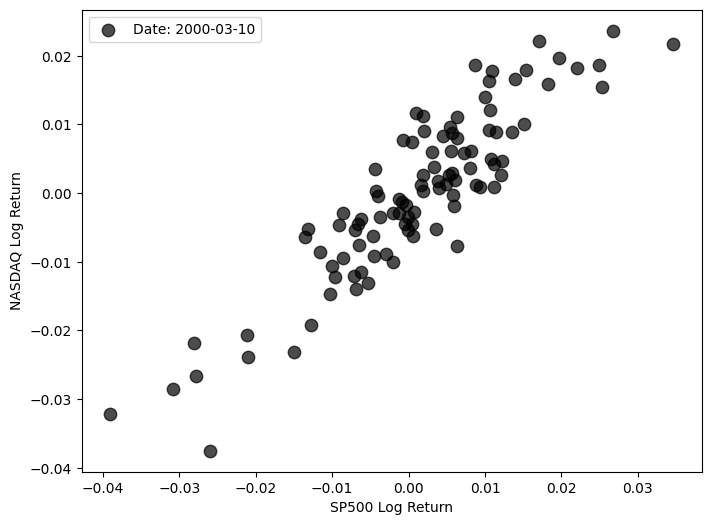

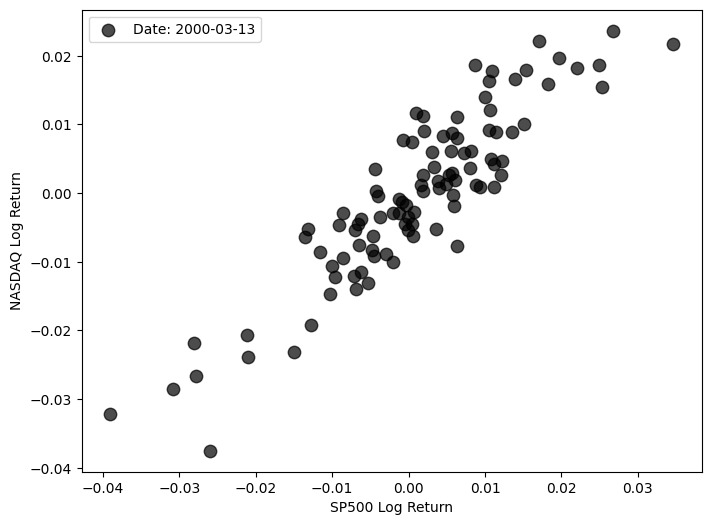

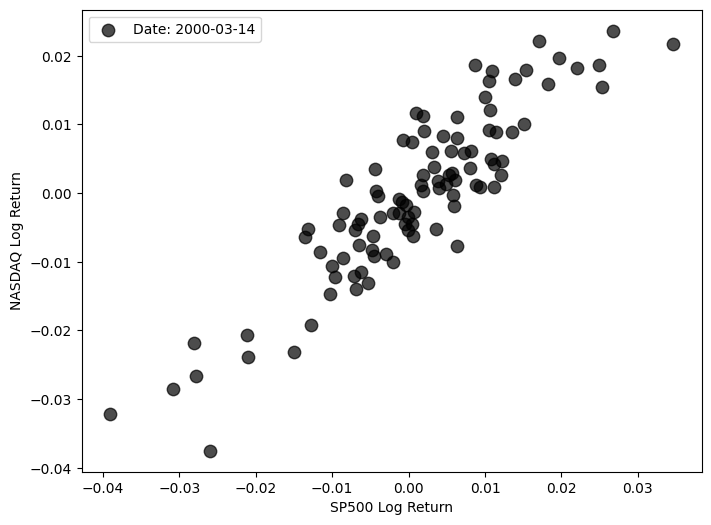

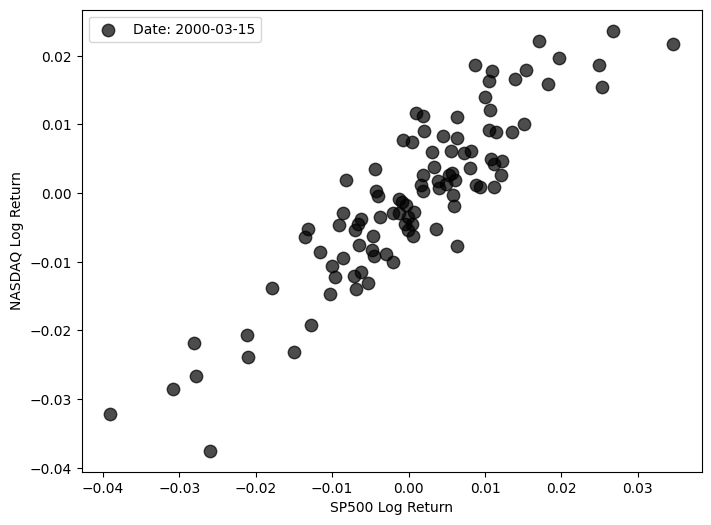

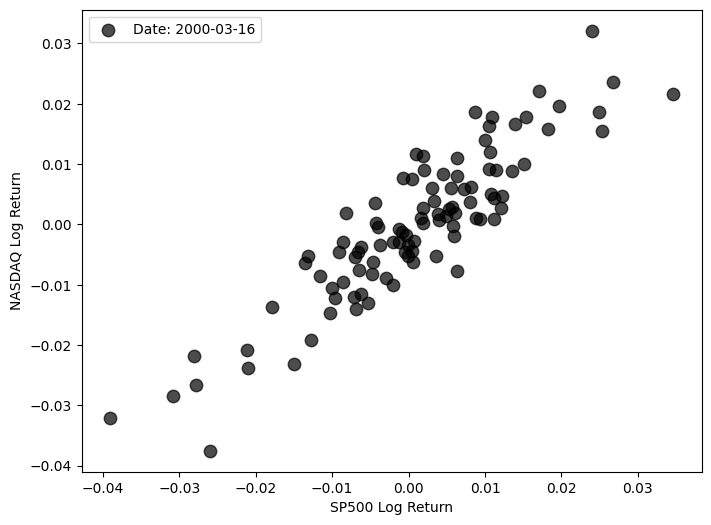

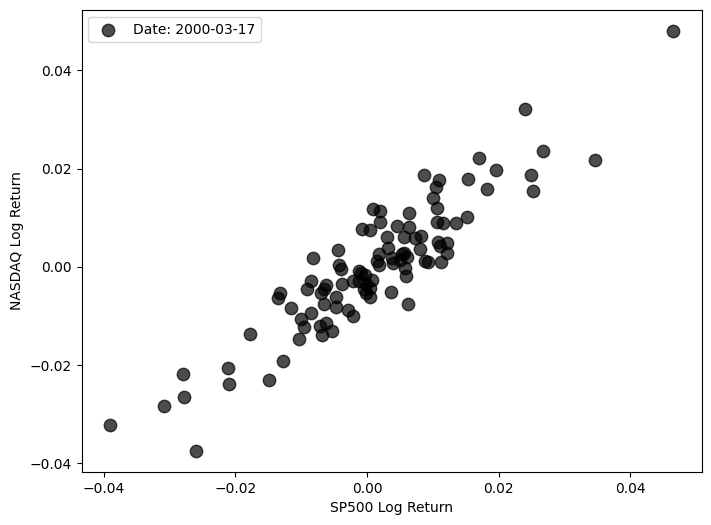

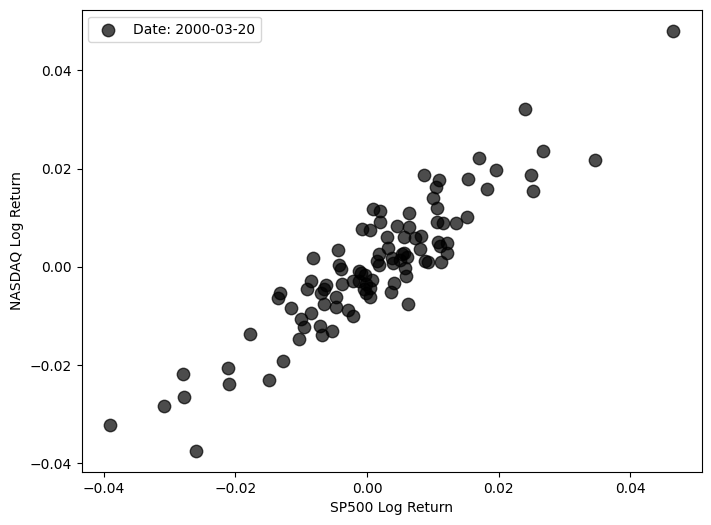

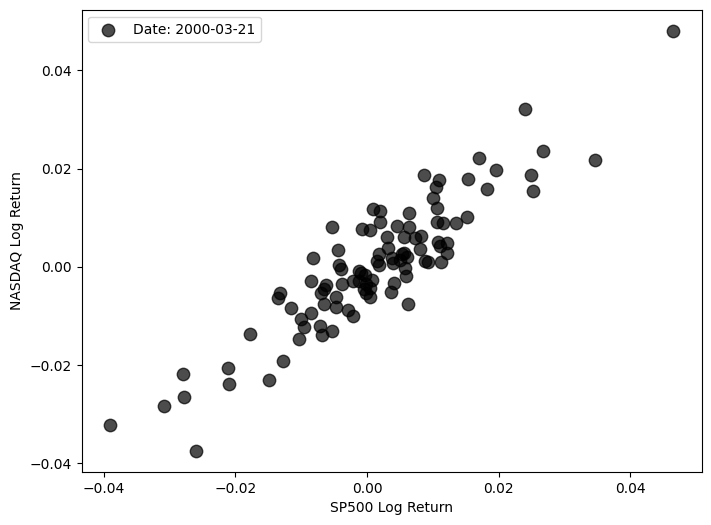

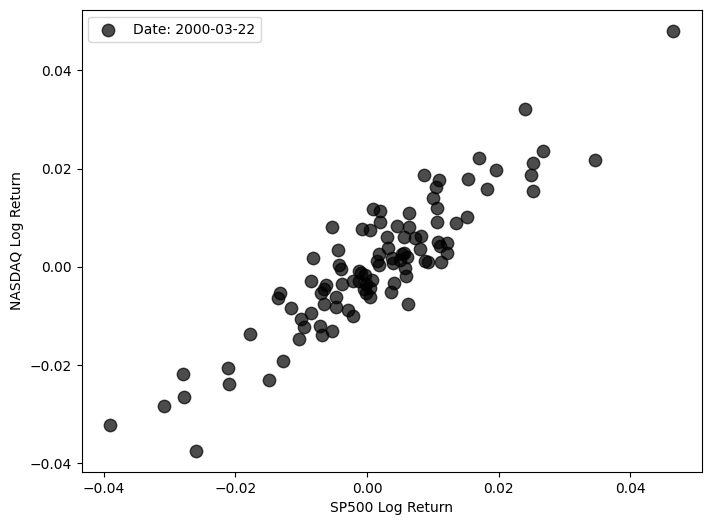

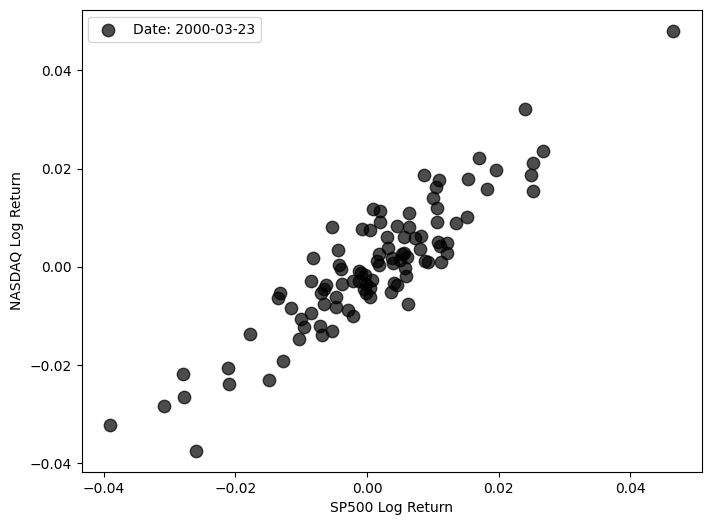

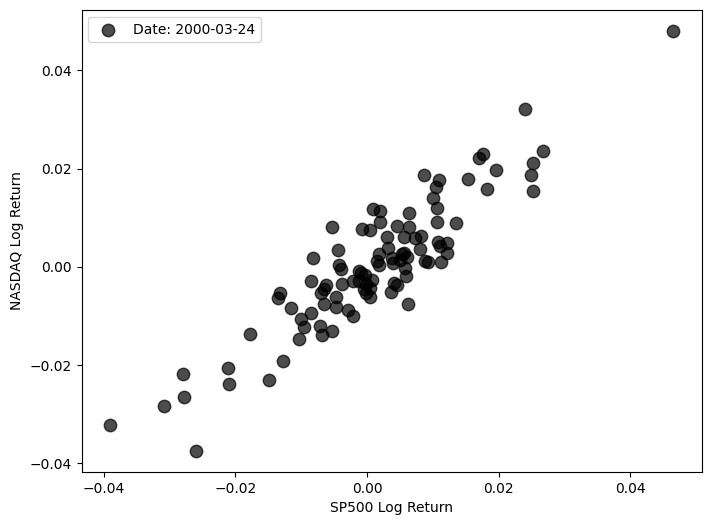

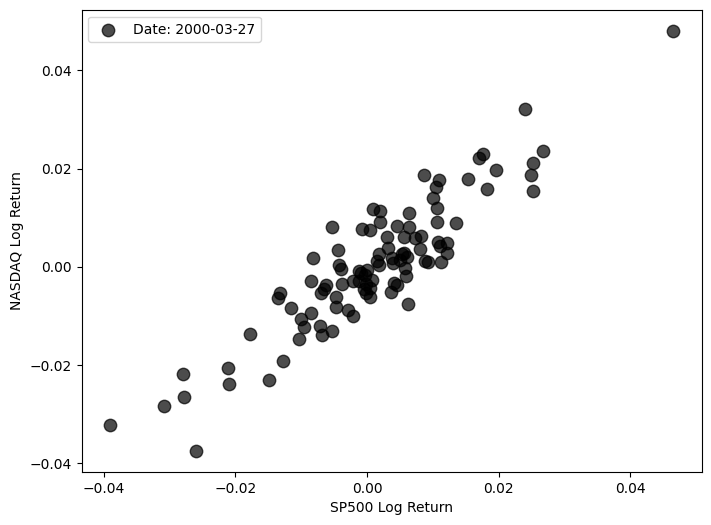

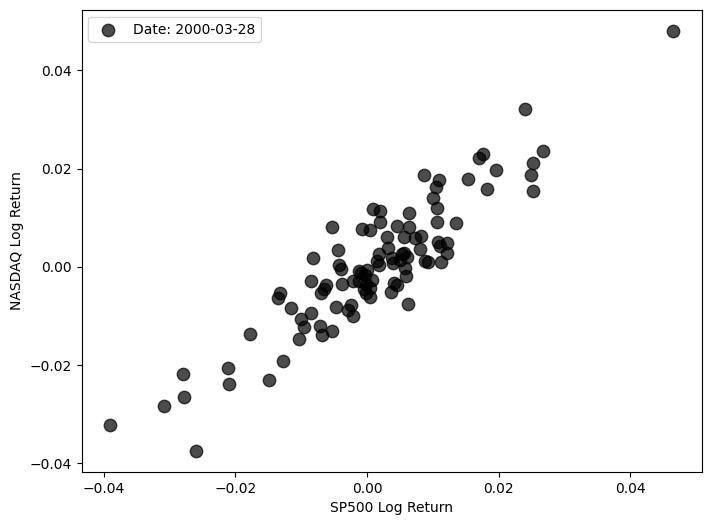

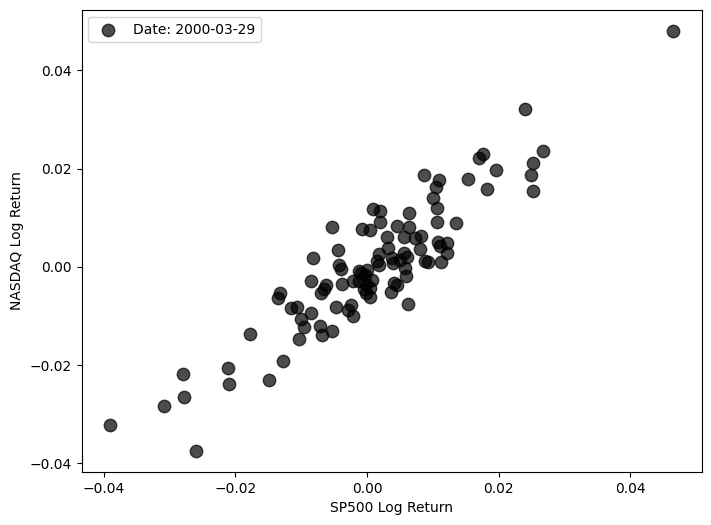

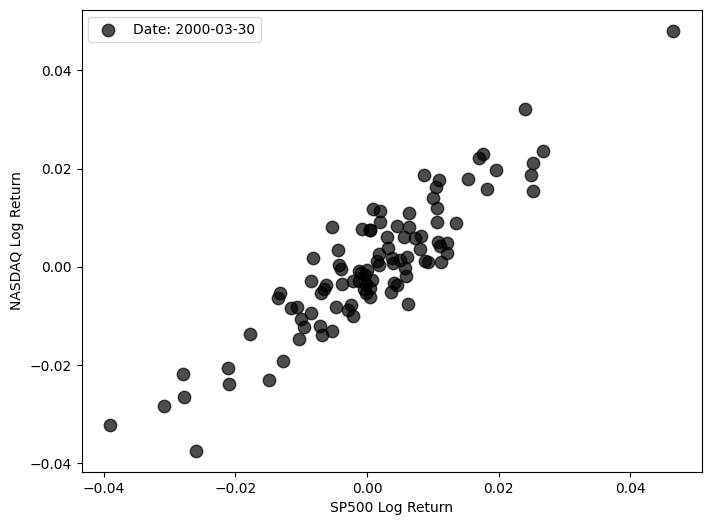

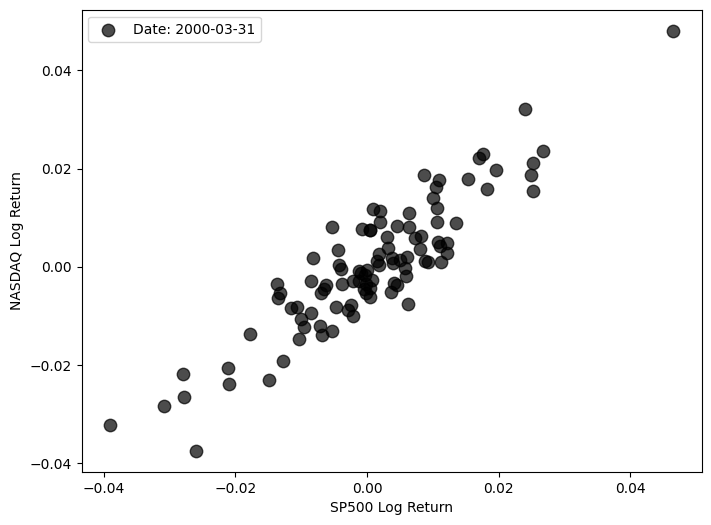

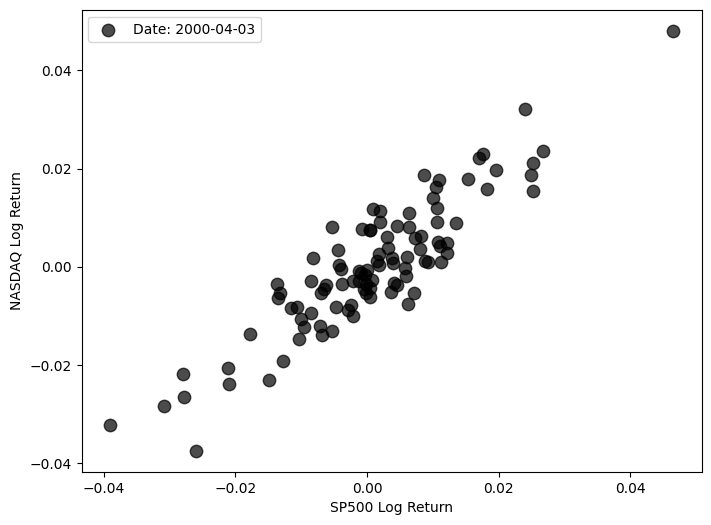

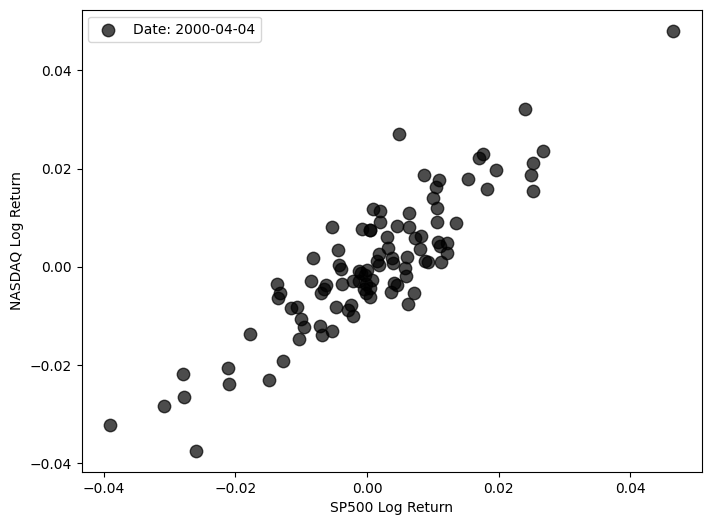

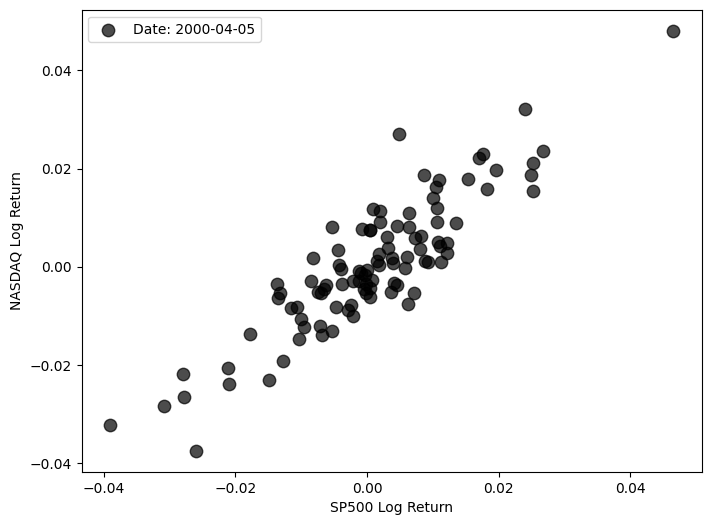

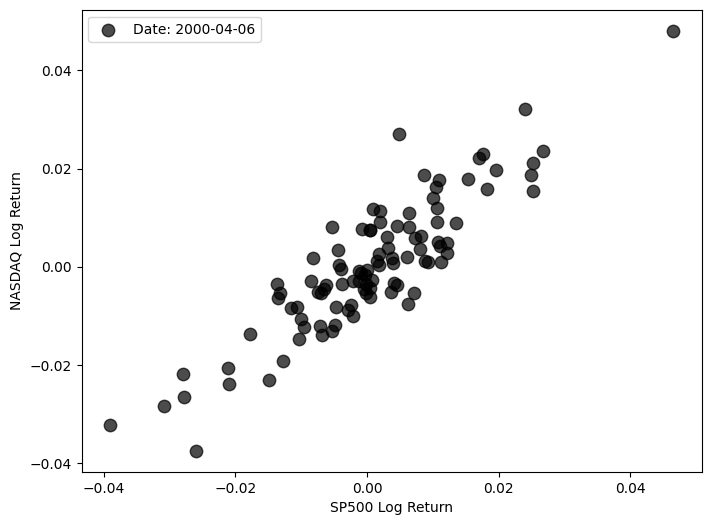

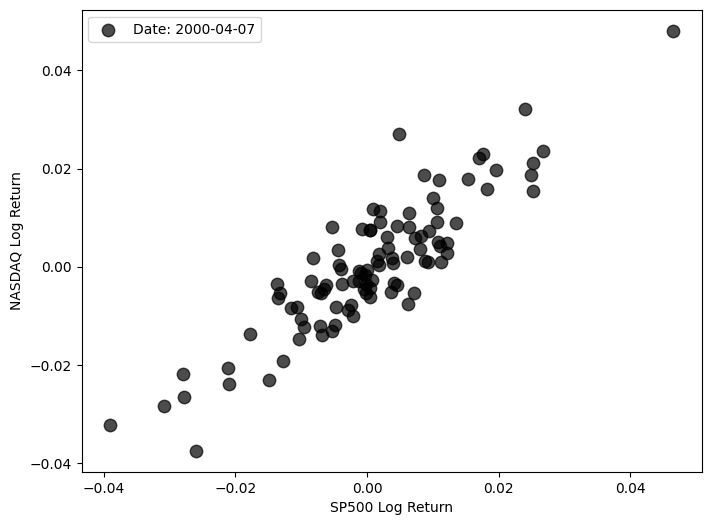

 70%|███████   | 5071/7200 [00:11<00:03, 558.02it/s]

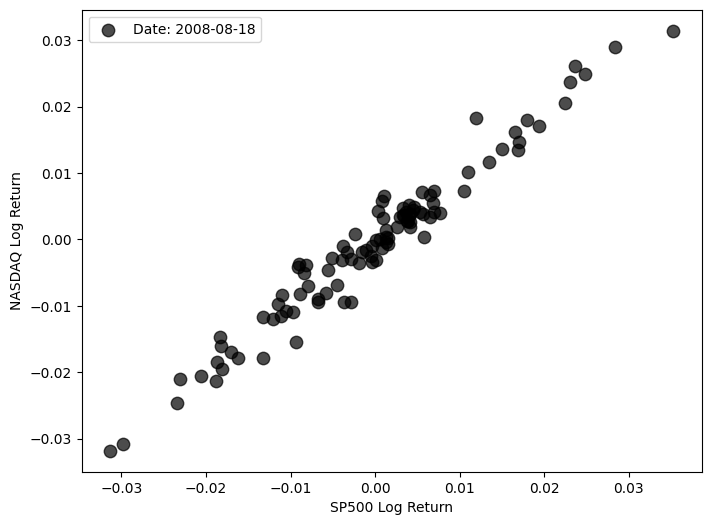

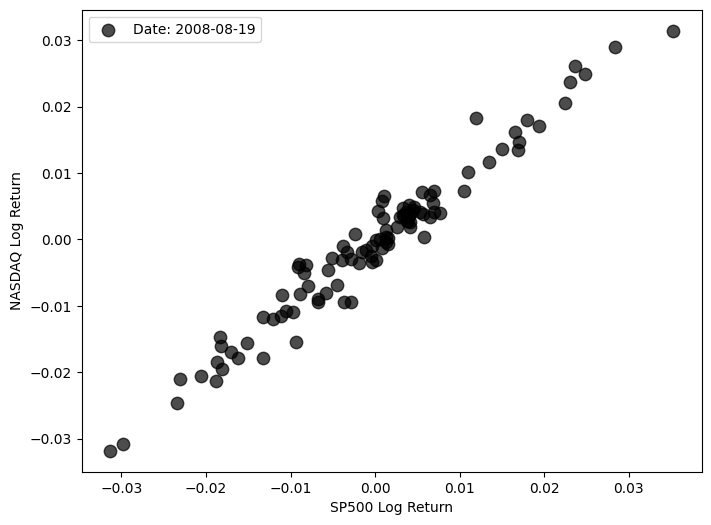

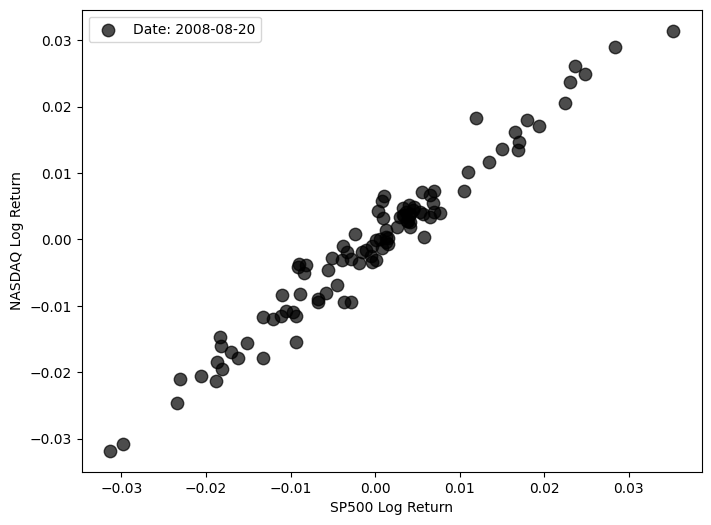

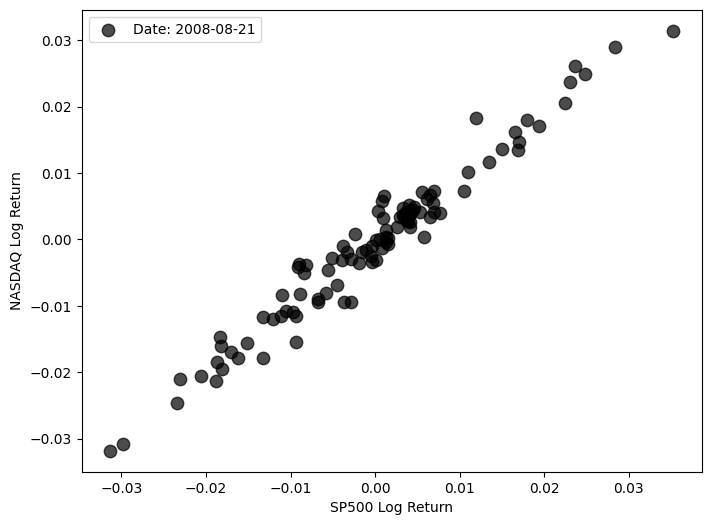

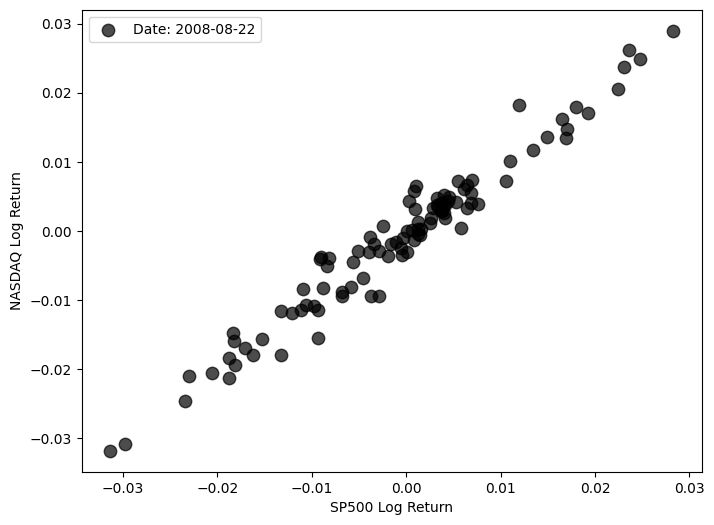

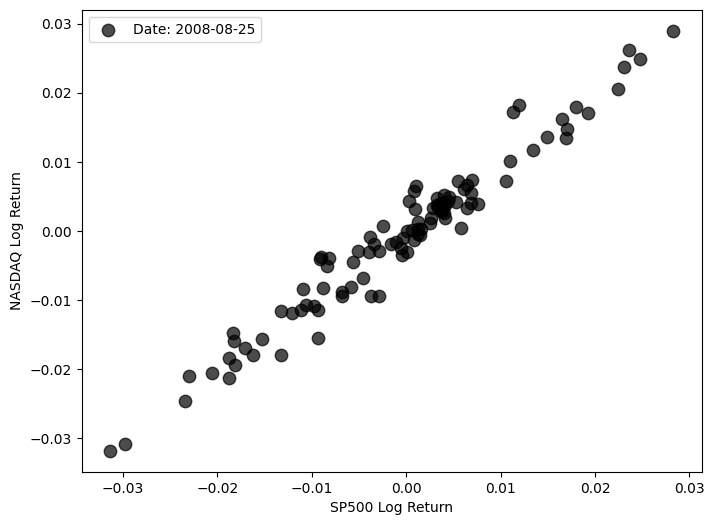

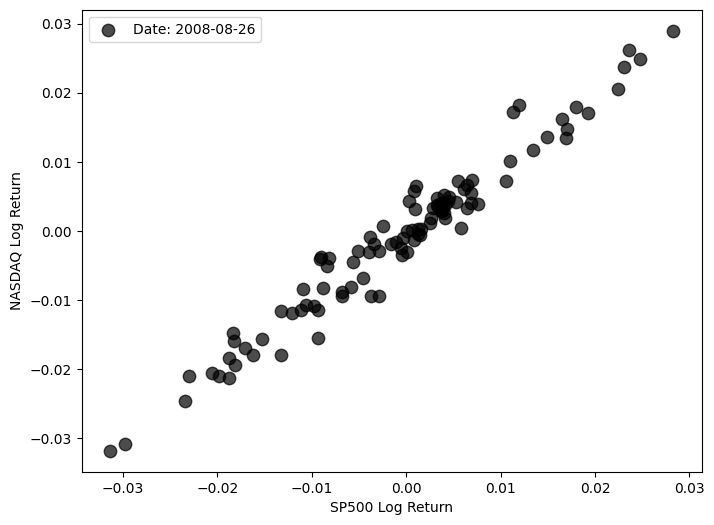

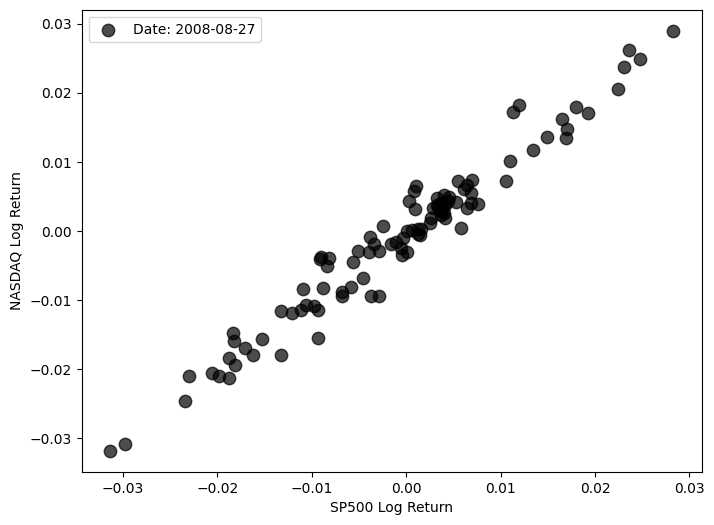

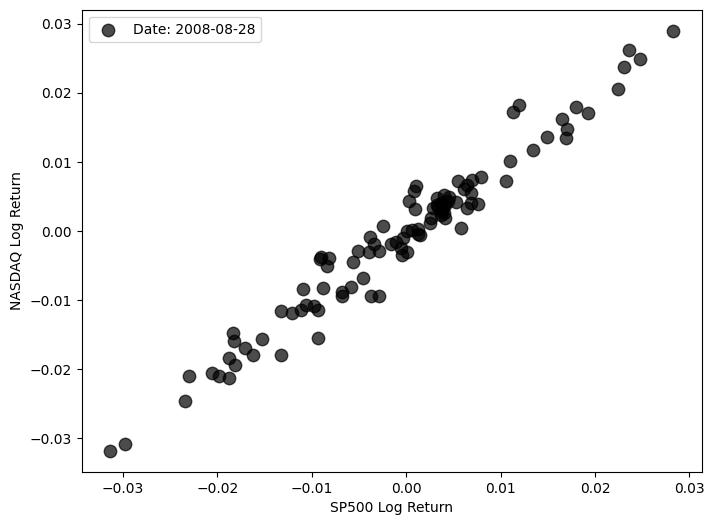

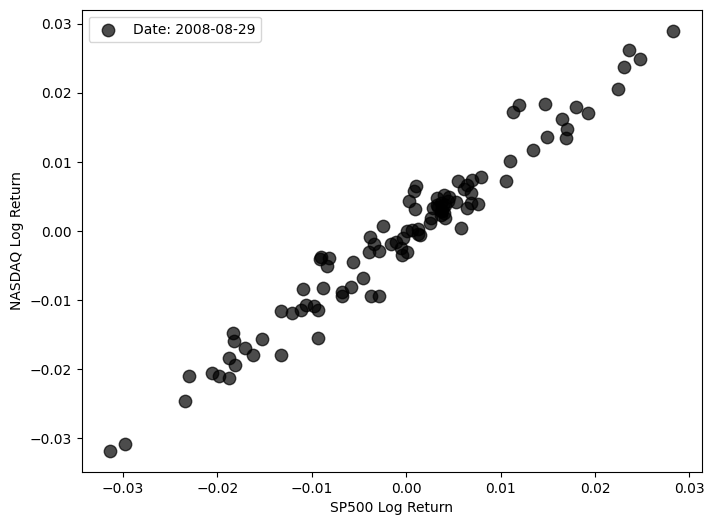

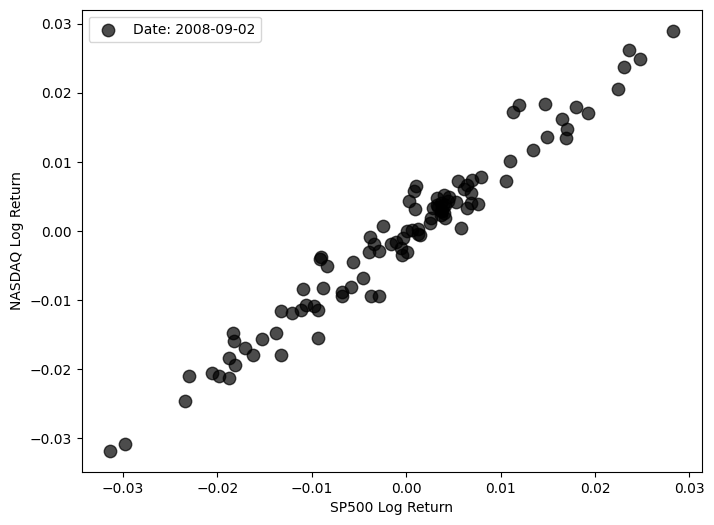

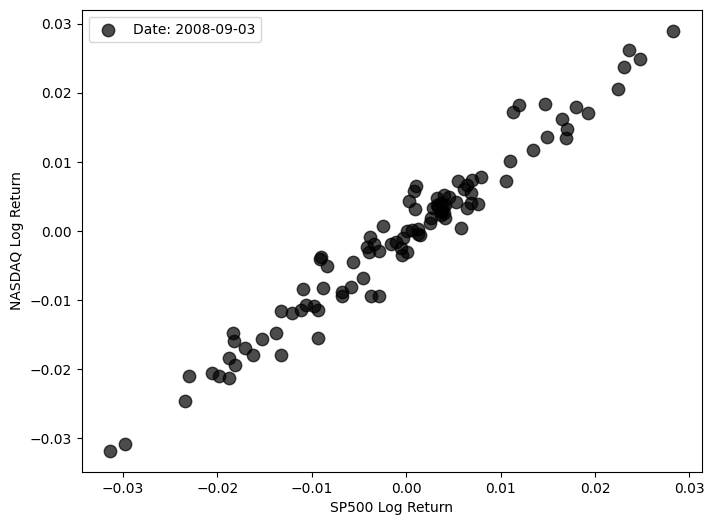

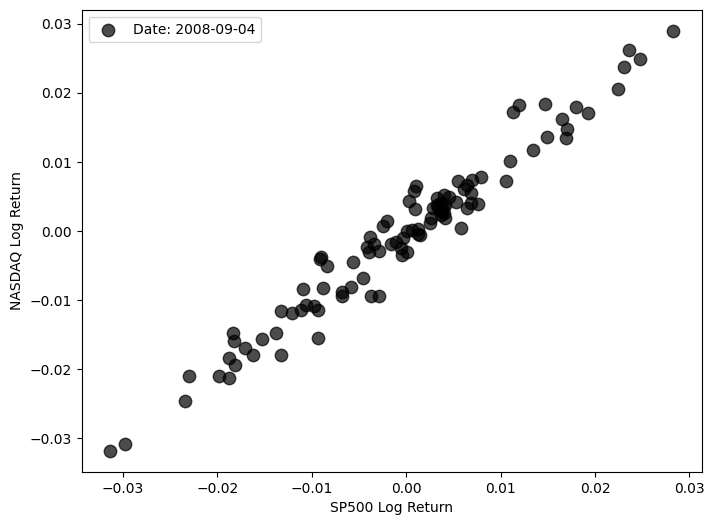

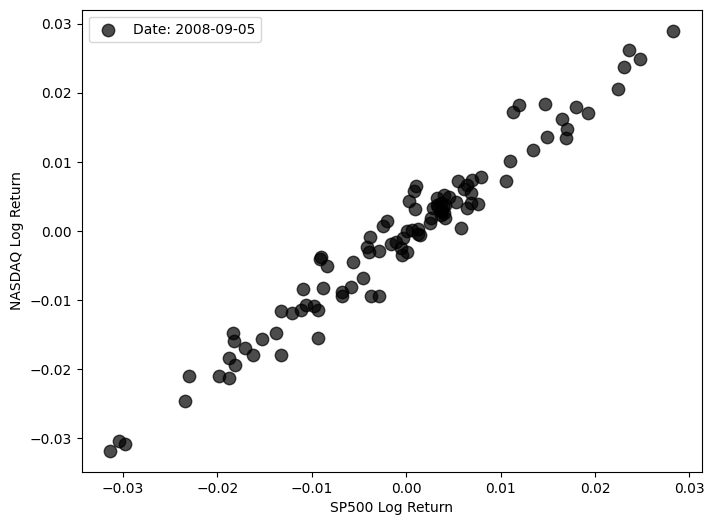

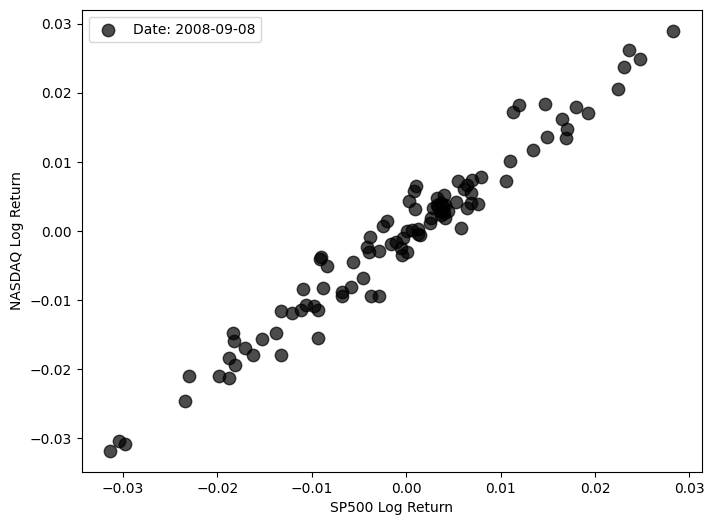

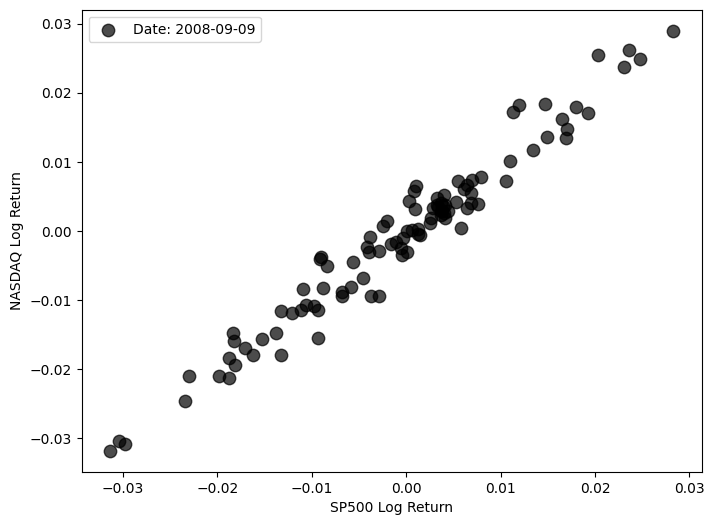

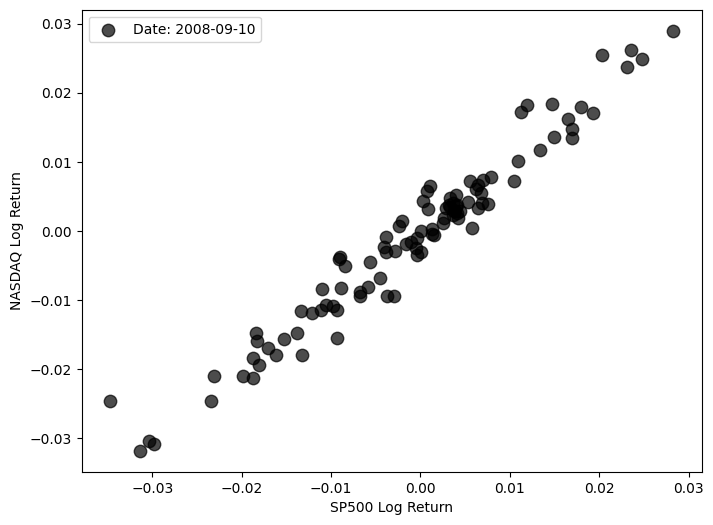

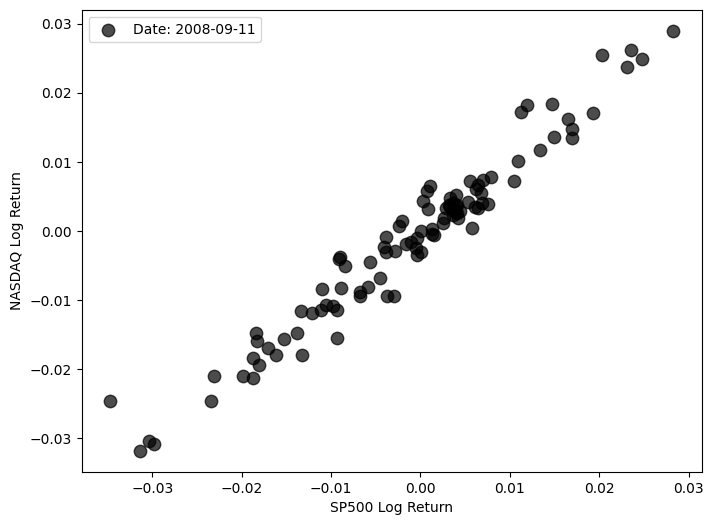

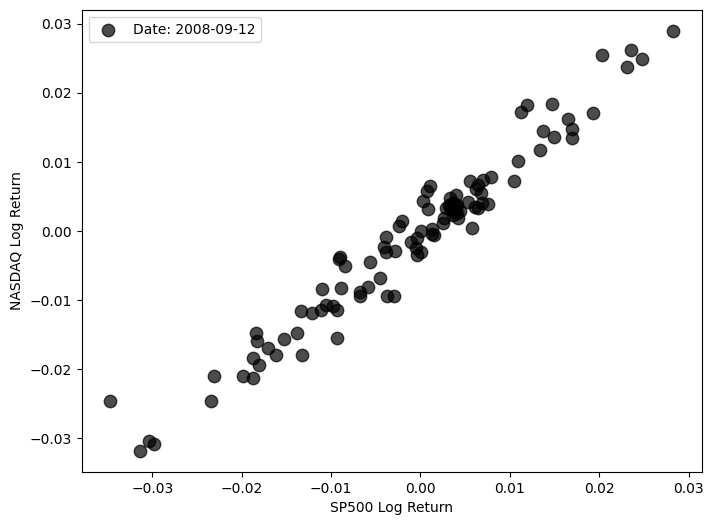

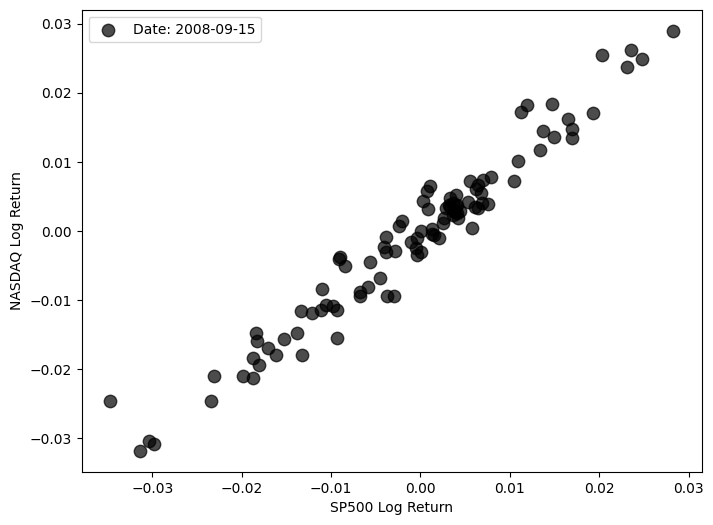

 71%|███████   | 5127/7200 [00:12<00:16, 125.71it/s]

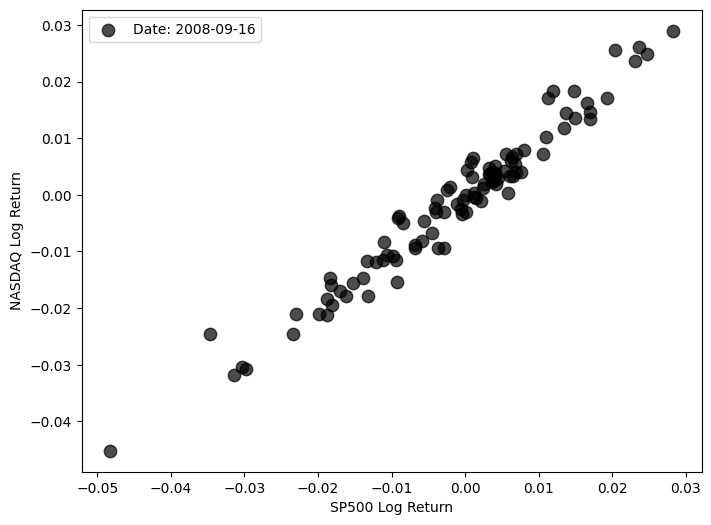

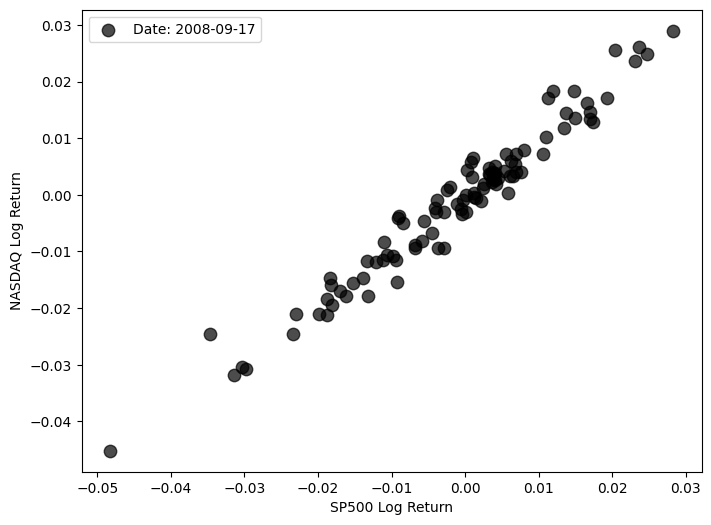

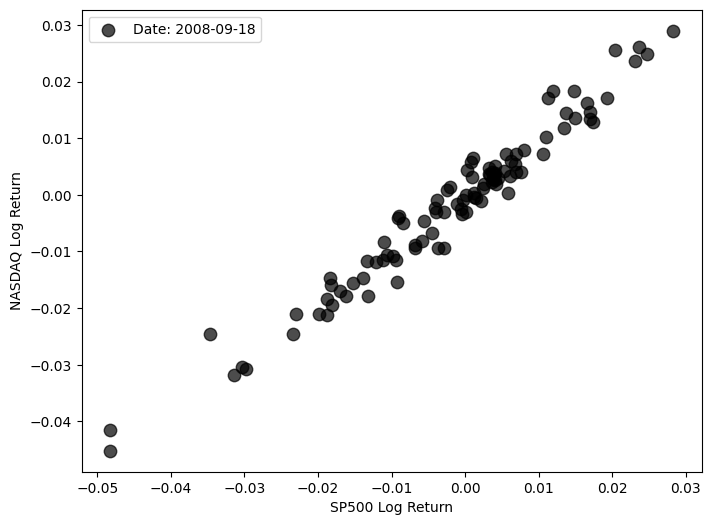

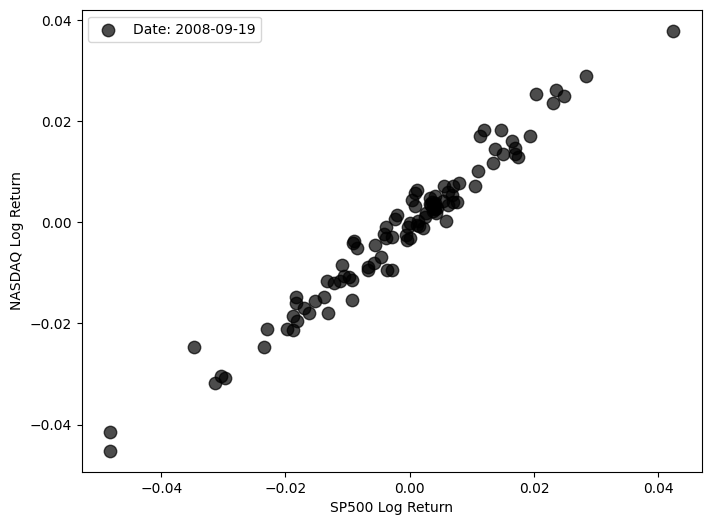

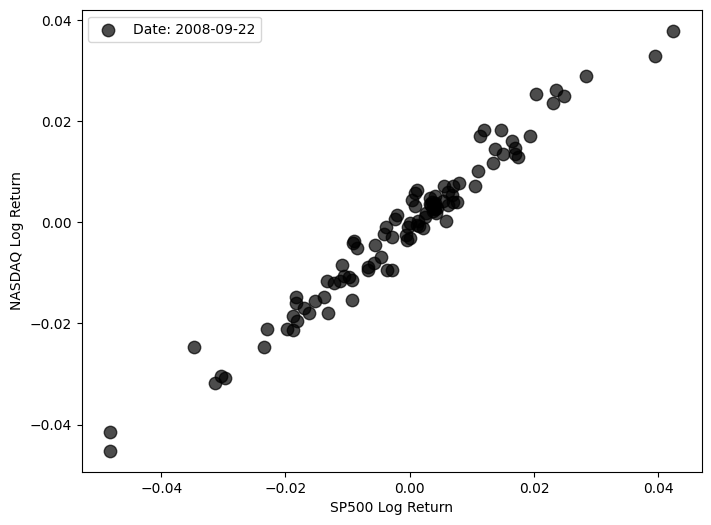

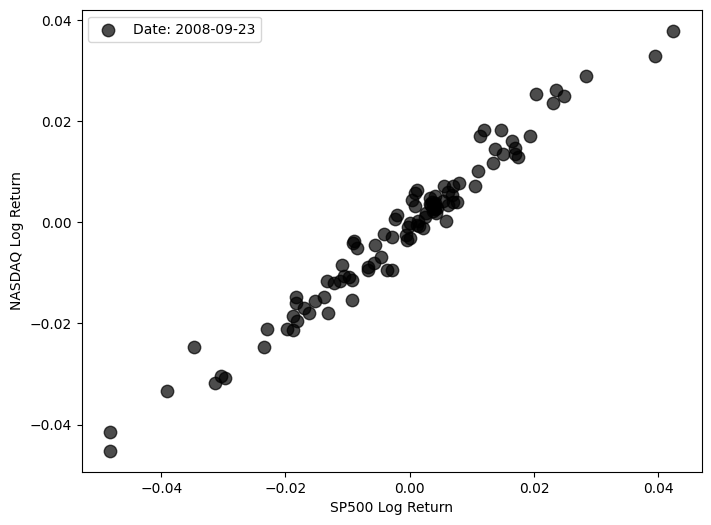

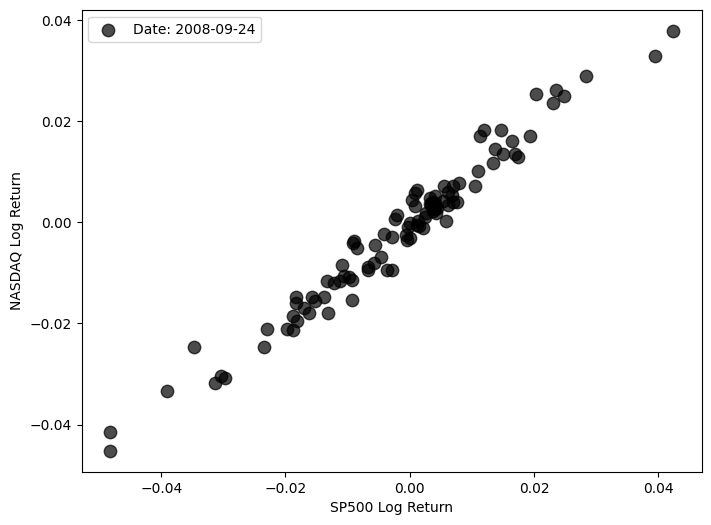

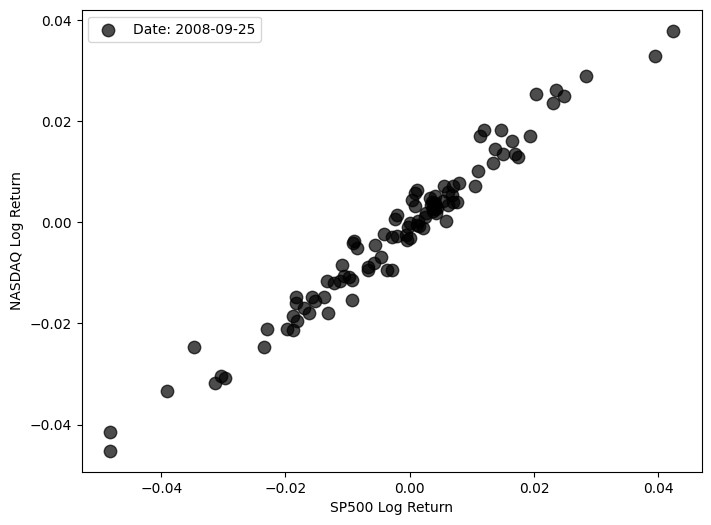

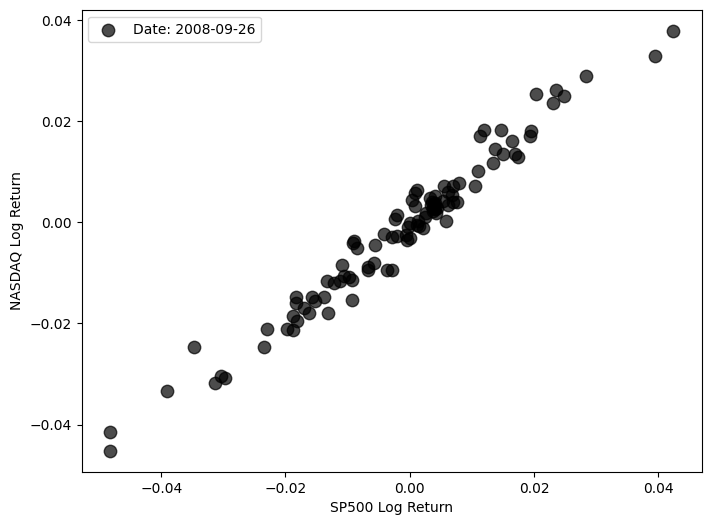

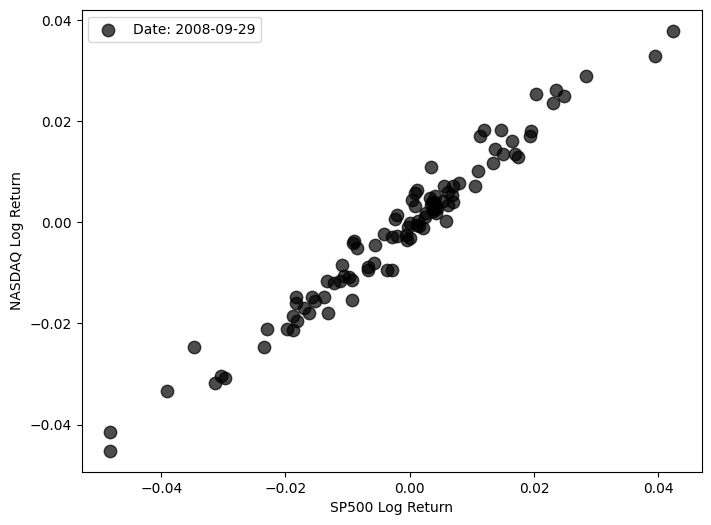

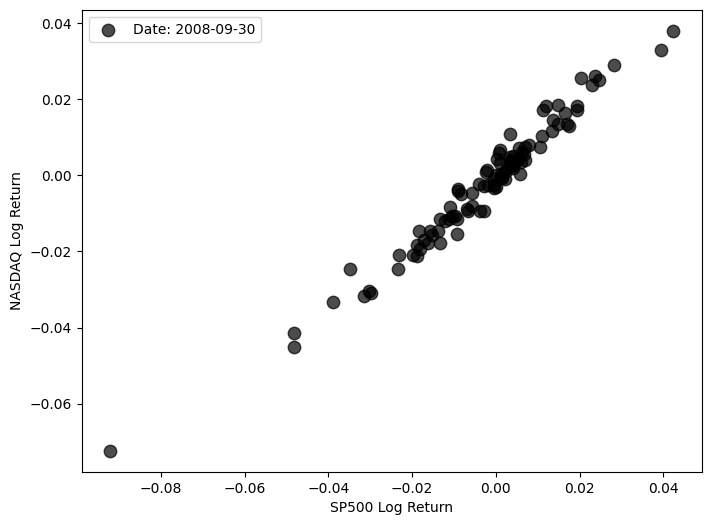

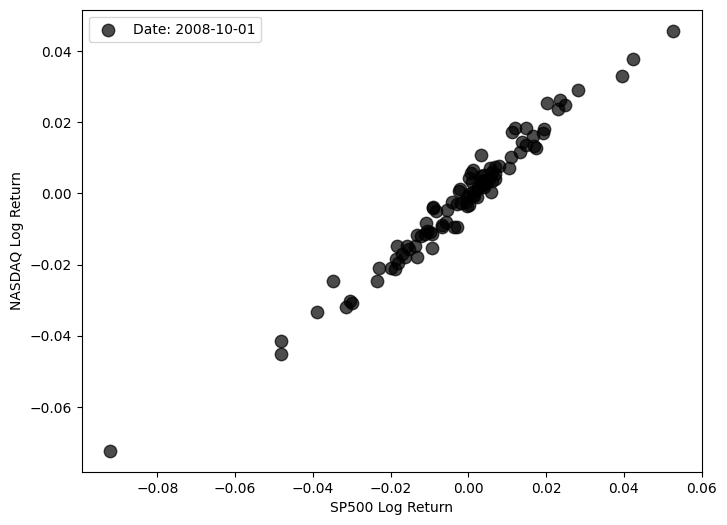

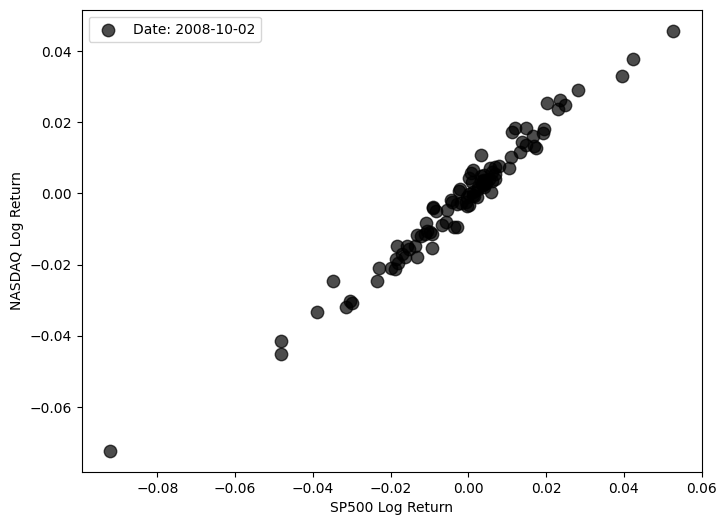

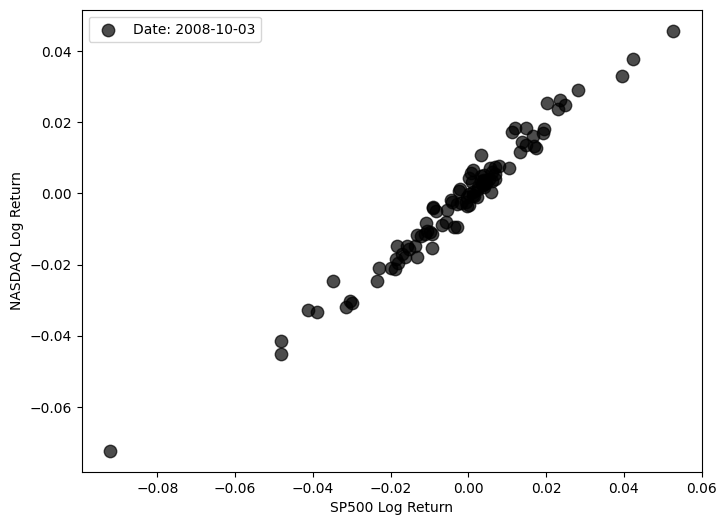

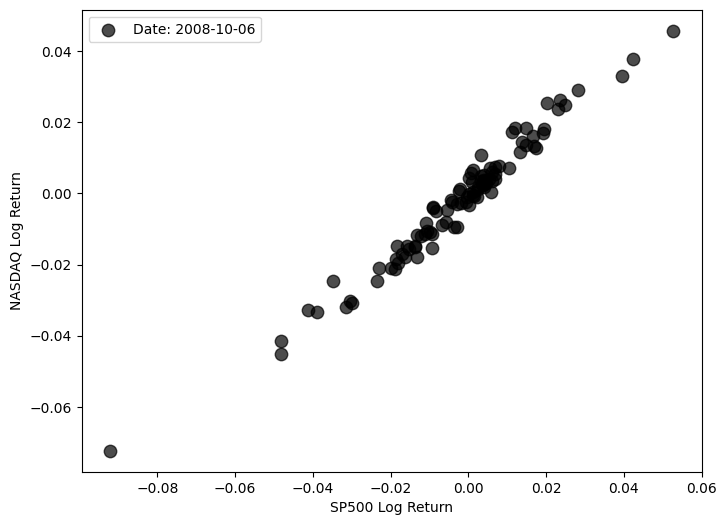

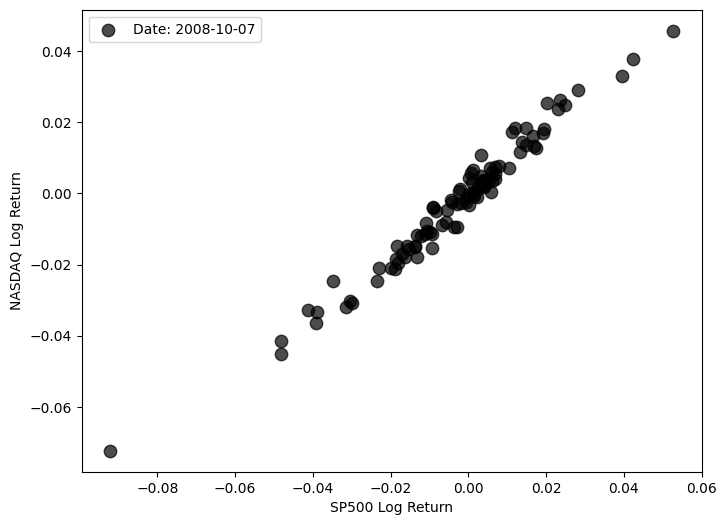

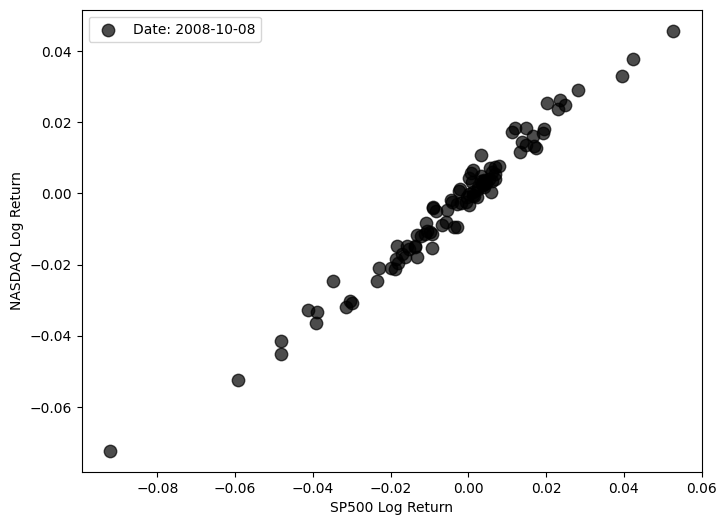

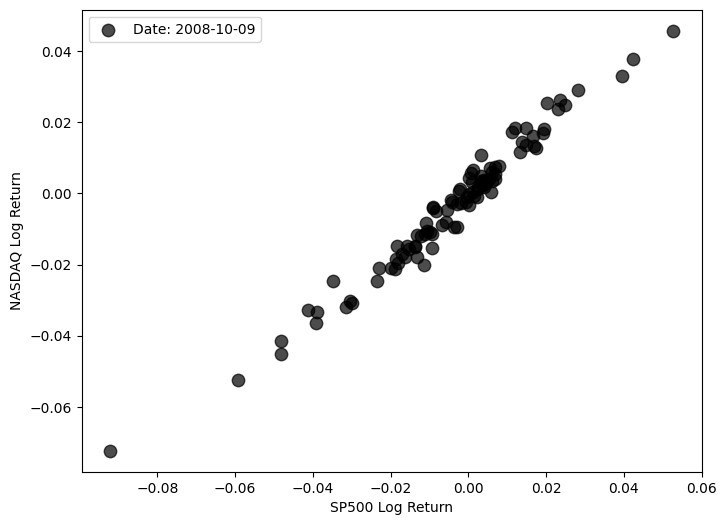

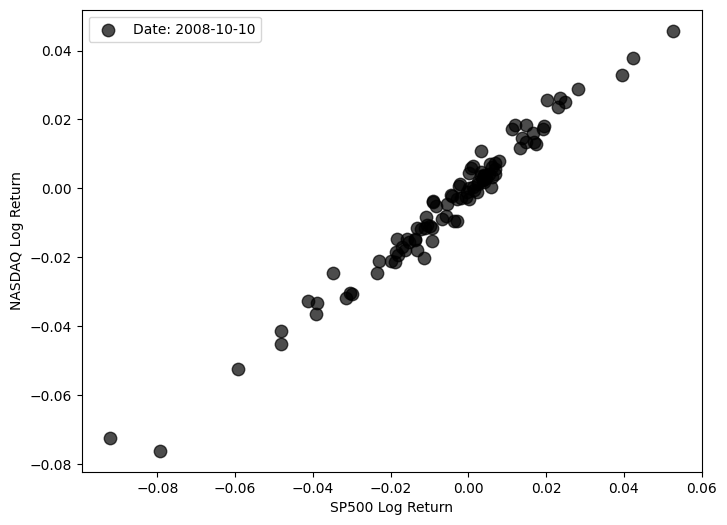

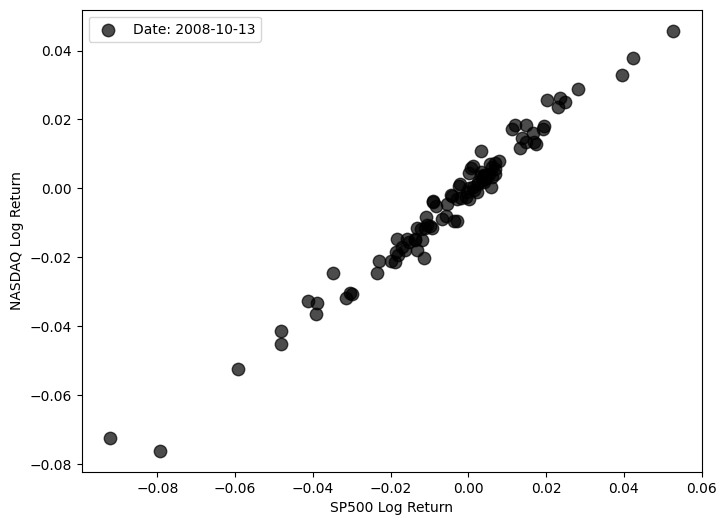

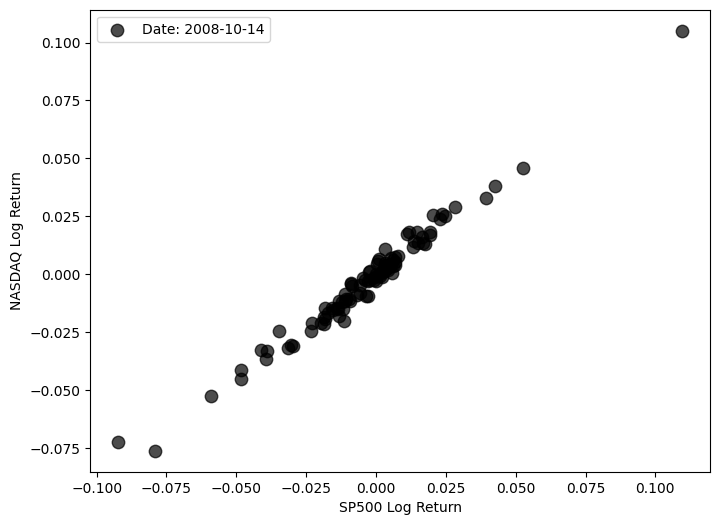

100%|██████████| 7200/7200 [00:18<00:00, 399.68it/s]


In [16]:
dotcom_date = pd.Timestamp("2000-03-10")
financial_crisis_date = pd.Timestamp("2008-09-15")

# compute persistence diagrams over sliding windows
w = 100 # window size
diagrams_returns = []
for i in tqdm(range(w, len(log_returns))):
    # use a backward-looking window to avoid look-ahead bias
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if np.abs(log_returns.index[i] - dotcom_date) < pd.Timedelta(days=30) or np.abs(log_returns.index[i] - financial_crisis_date) < pd.Timedelta(days=30):
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        plt.xlabel("SP500 Log Return")
        plt.ylabel("NASDAQ Log Return")
        date = log_returns.index[i]
        plt.scatter(window[:, 0], window[:, 1], c='black', s=80, alpha=0.7, label=f'Date: {date.date()}')
        plt.legend()
        plt.show()

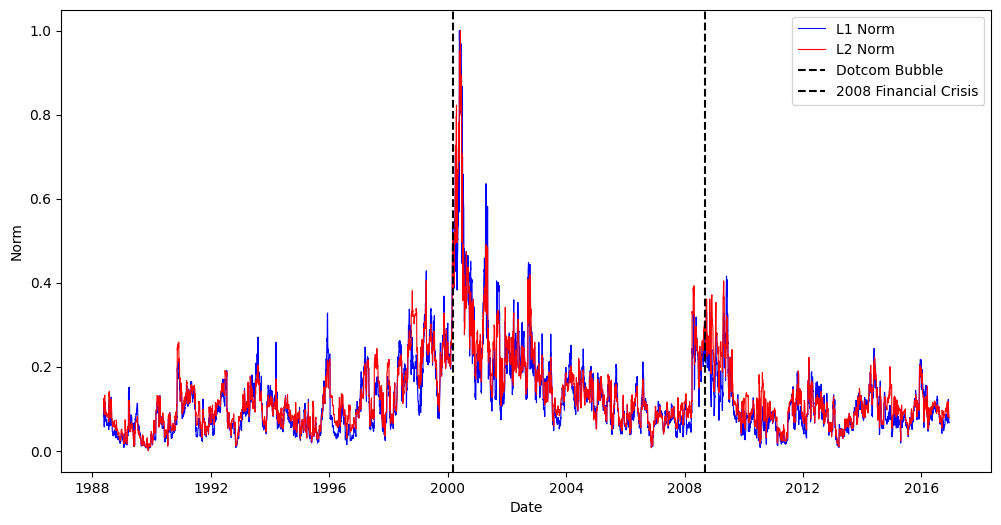

In [ ]:
# compute the persistence landscapes L^1 and L^2 norms for log-returns
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# plot the L^1 and L^2 norms of the persistence landscapes over time
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Norm")
plt.legend()
plt.savefig("plots/dotcom_norms.png", dpi=300)
plt.show()

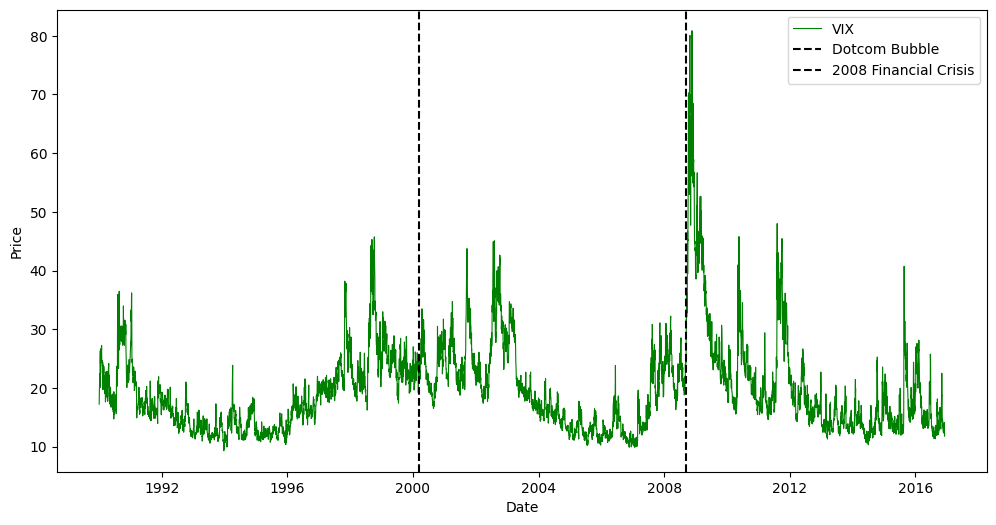

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], data.loc[dates[w:], '^VIX'], label='VIX', color='green', linewidth=0.8)
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("plots/vix_timeseries.png", dpi=300)
plt.show()

In [19]:
# change point detection on L2 norm time series
l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=2)

In [20]:
dotcom_index = np.where(dates[w:] == pd.Timestamp('2000-03-10'))[0][0]
financial_crisis_index = np.where(dates[w:] == pd.Timestamp('2008-09-15'))[0][0]

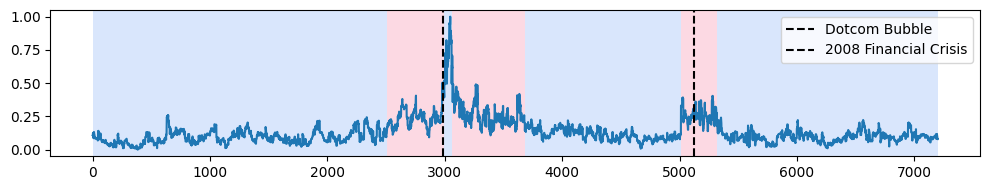

In [21]:
# plot the change points on the L2 norm time series
rpt.display(l2_signal, result)
plt.axvline(dotcom_index, color='black', linestyle='--', label='Dotcom Bubble')
plt.axvline(financial_crisis_index, color='black', linestyle='--', label='2008 Financial Crisis')
plt.legend()
plt.savefig("plots/dotcom_norms_change_points.png", dpi=300)
plt.show()

In [22]:
# print the detected change points dates
change_point_dates = [dates[w:][cp - 1] for cp in result[:-1]]
print("Detected Change Points Dates:")
for date in change_point_dates:
    print(date)

# print dotcom bubble and 2008 financial crisis dates
print("Dotcom Bubble date:", dates[dotcom_index])
print("2008 Financial Crisis date:", dates[financial_crisis_index])

Detected Change Points Dates:
1998-04-21 00:00:00
2000-03-22 00:00:00
2000-06-30 00:00:00
2002-12-13 00:00:00
2008-03-31 00:00:00
2009-06-22 00:00:00
Dotcom Bubble date: 1999-10-18 00:00:00
2008 Financial Crisis date: 2008-04-23 00:00:00


In [ ]:
# compute statistical features on L2 norm time series
window_size = 500
variances = []
avg_spectral_densities = []
firstlags = []

for i in tqdm(range(window_size, len(l2_norms_returns))):
    window = pd.Series(l2_norms_returns[i-window_size:i])
    
    variance = window.var()
    variances.append(variance)
    
    f, Pxx = welch(window.values, fs=1.0)
    low_freq_indices = f < 0.1
    avg_spectral_density = Pxx[low_freq_indices].mean()
    avg_spectral_densities.append(avg_spectral_density)

    # first lag of the ACF
    acf_values = sm.tsa.acf(window.values, nlags=1, fft=True)
    firstlag = acf_values[1].mean()
    firstlags.append(firstlag)

100%|██████████| 6700/6700 [00:01<00:00, 5301.46it/s]


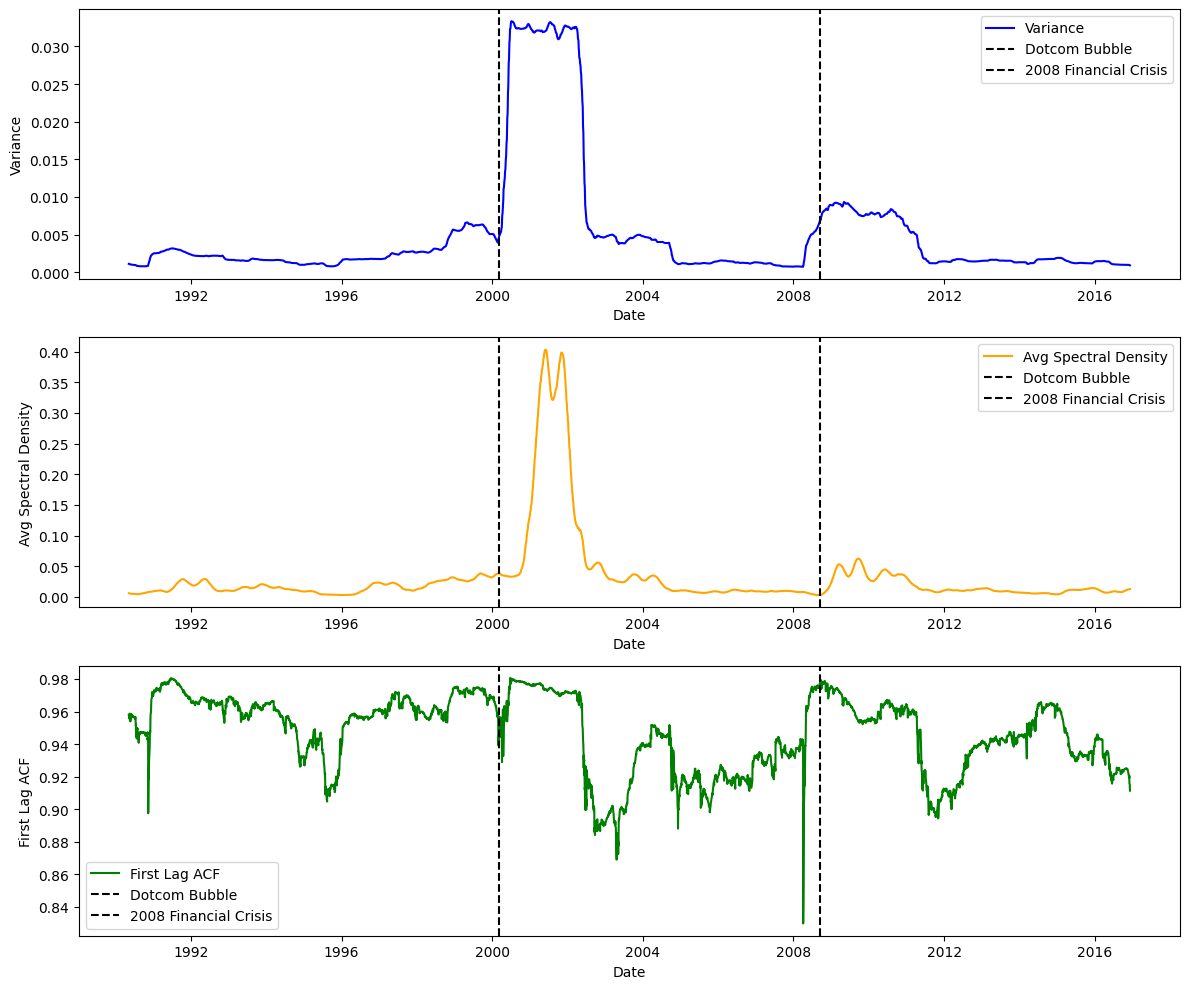

In [24]:
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(dates[window_size+100:], variances, label='Variance', color='blue')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(dates[window_size+100:], avg_spectral_densities, label='Avg Spectral Density', color='orange')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("Avg Spectral Density")
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(dates[window_size+100:], firstlags, label='First Lag ACF', color='green')
plt.axvline(pd.Timestamp("2000-03-10"), color='black', linestyle='--',  label='Dotcom Bubble')
plt.axvline(pd.Timestamp("2008-09-15"), color='black', linestyle='--',  label='2008 Financial Crisis')
plt.xlabel("Date")
plt.ylabel("First Lag ACF")
plt.legend()
plt.tight_layout()
plt.savefig("plots/dotcom_l2_features.png", dpi=300)
plt.show()

# Empirical analysis of financial data - Covid-19 crisis and 2022 market turndown

In [25]:
# download financial data : SP500, Dow Jones, NASDAQ, Russell 2000, VIX
tickers = ['^GSPC', '^DJI', '^IXIC', '^RUT', '^VIX']
data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_15088\1912341353.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']
[*********************100%***********************]  5 of 5 completed


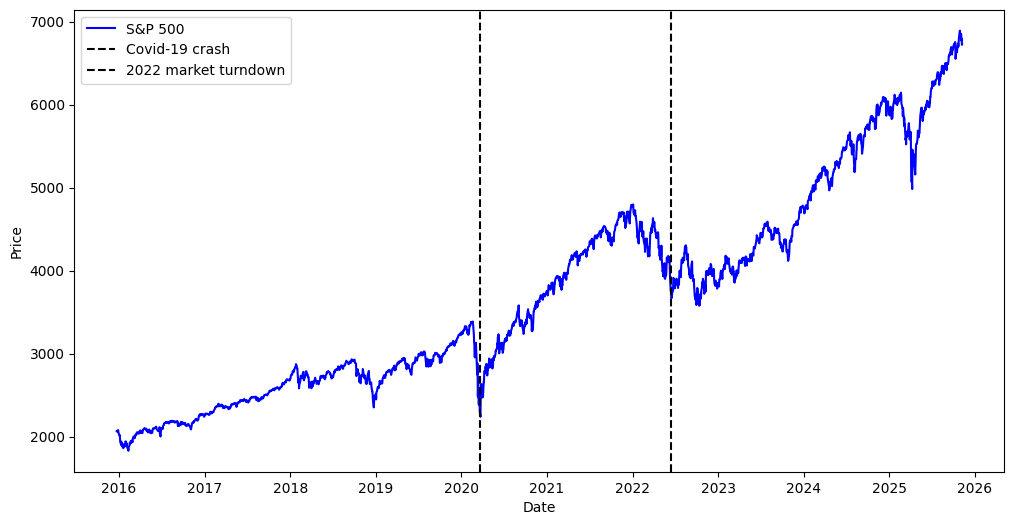

In [26]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^GSPC'], label='S&P 500', color='blue')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("plots/covid_sp500.png", dpi=300)
plt.show()

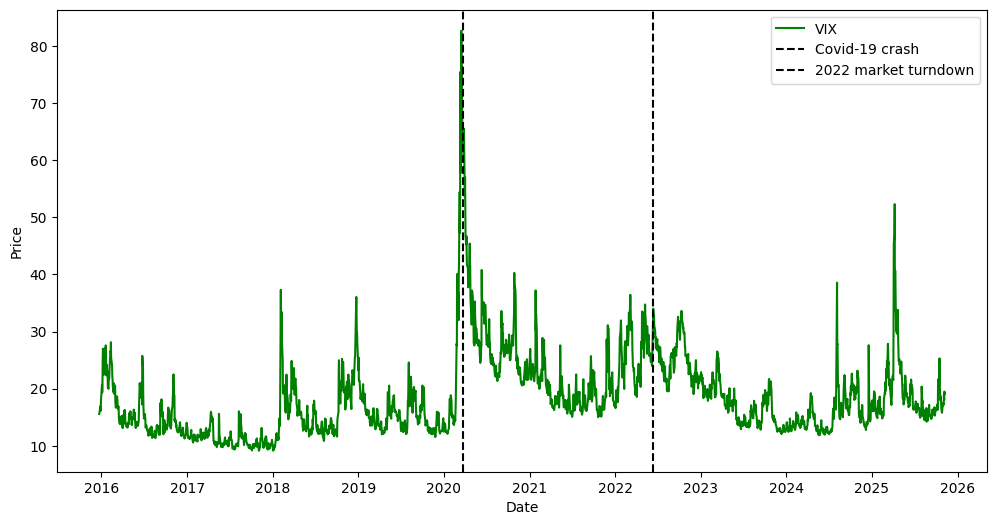

In [27]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='green')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("plots/covid_vix.png", dpi=300)
plt.show()

In [28]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).fillna(0)

 37%|███▋      | 890/2384 [00:01<00:02, 546.88it/s]

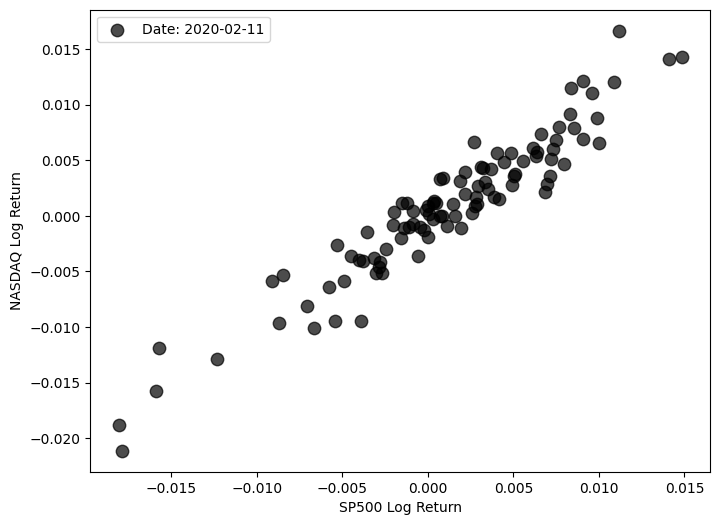

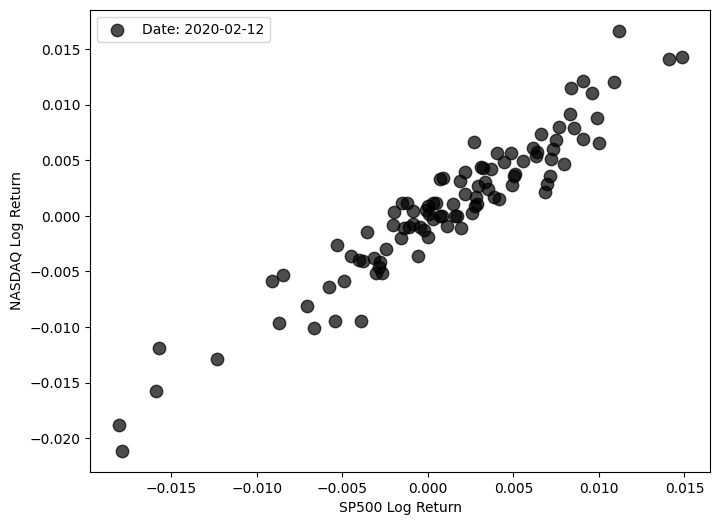

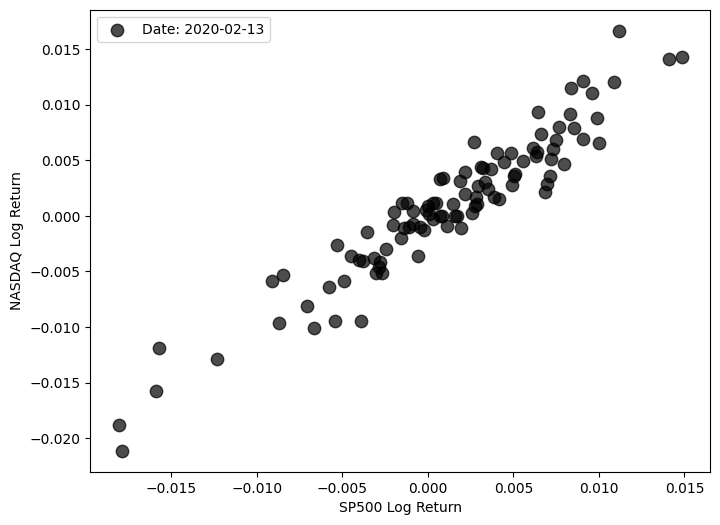

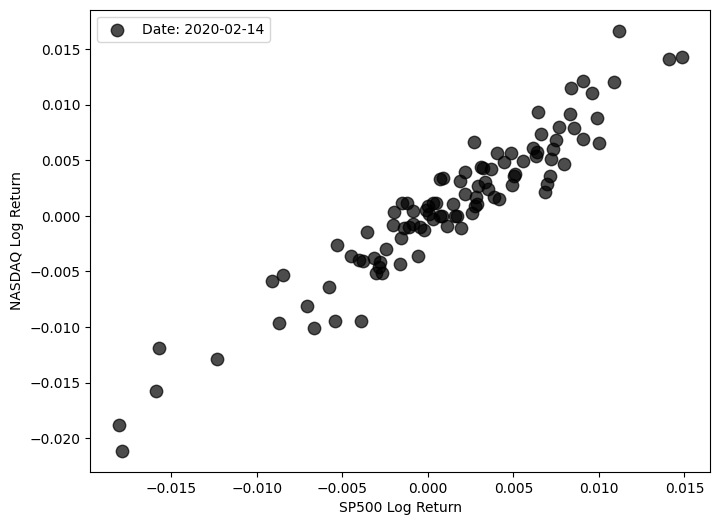

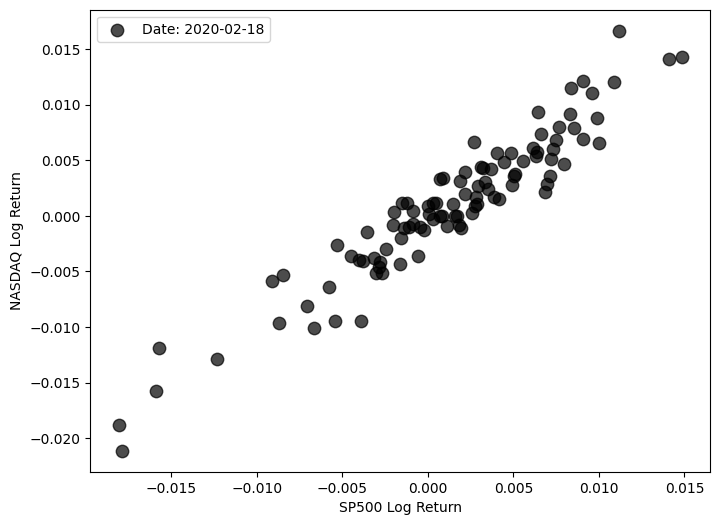

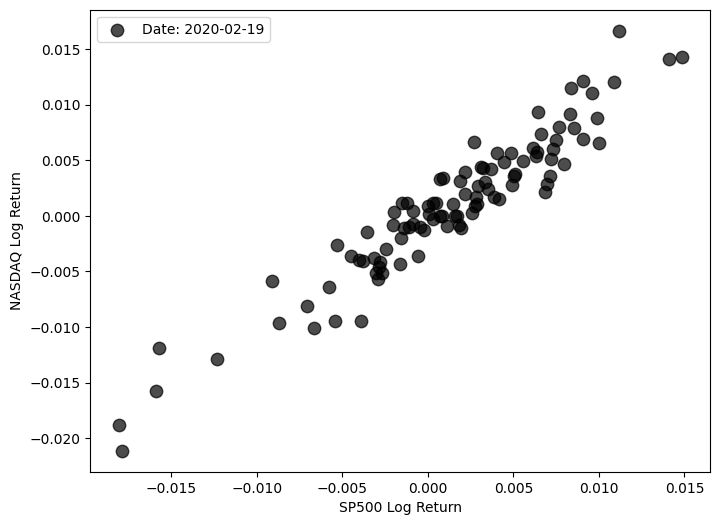

 40%|███▉      | 945/2384 [00:02<00:05, 243.41it/s]

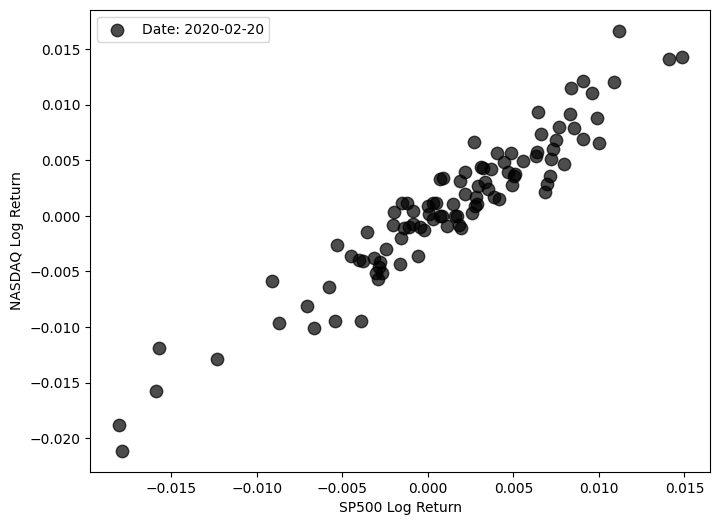

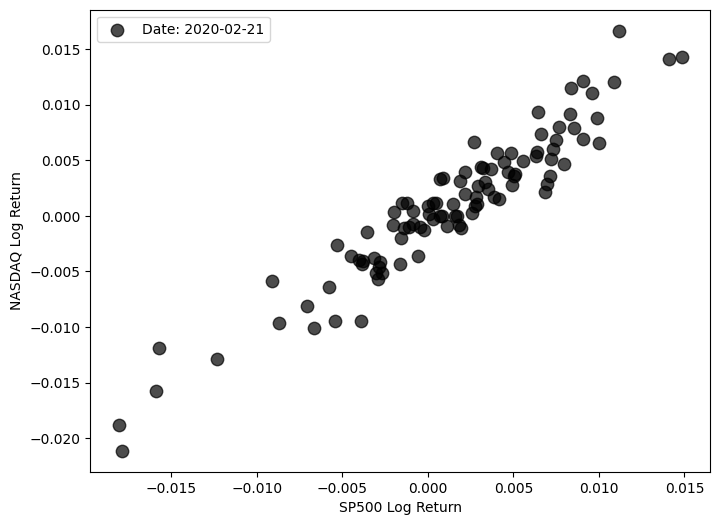

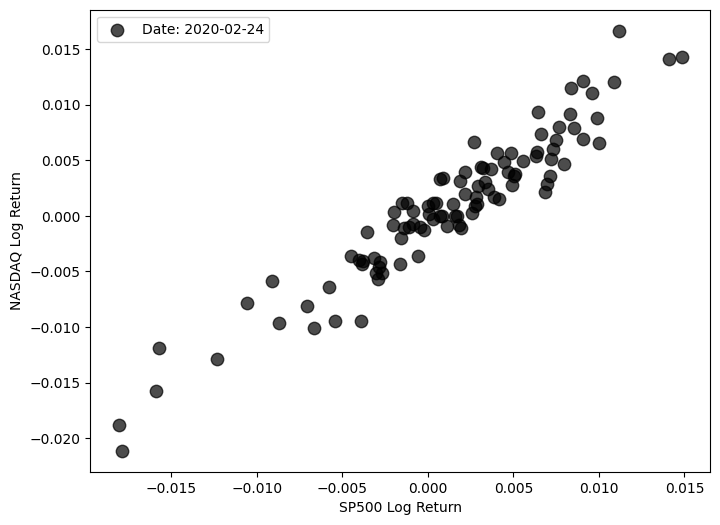

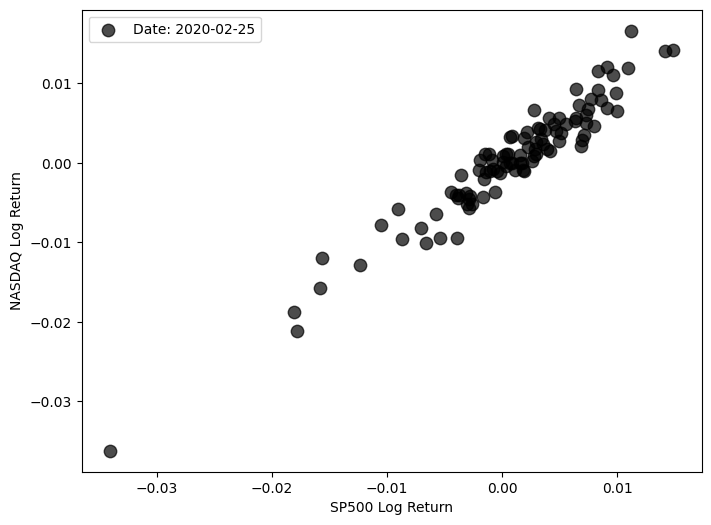

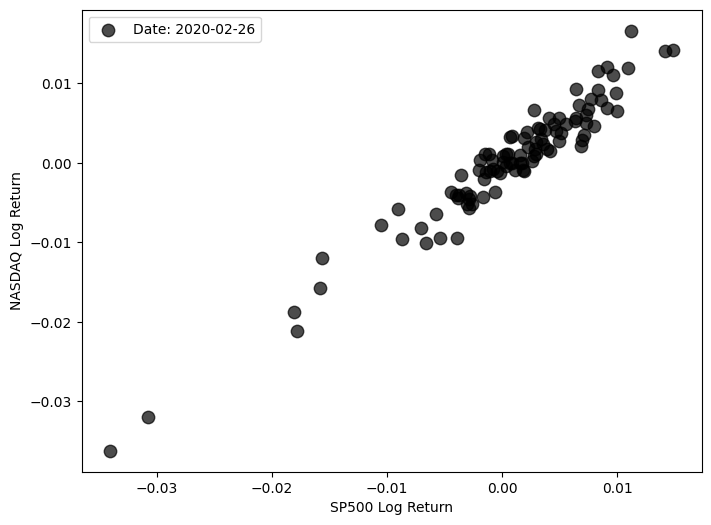

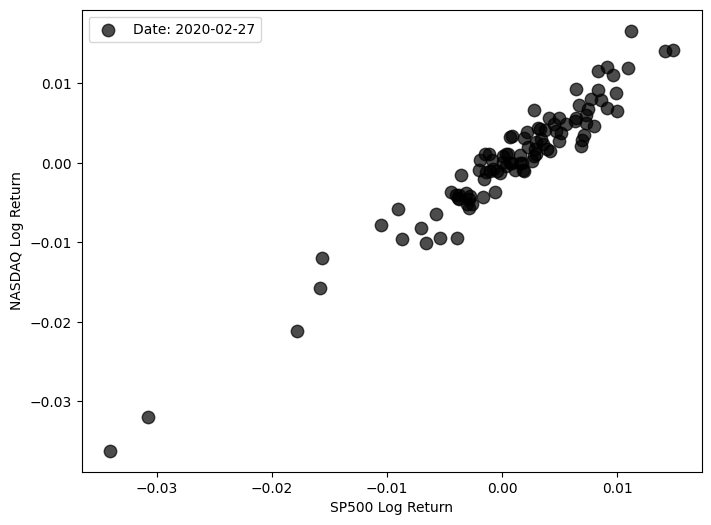

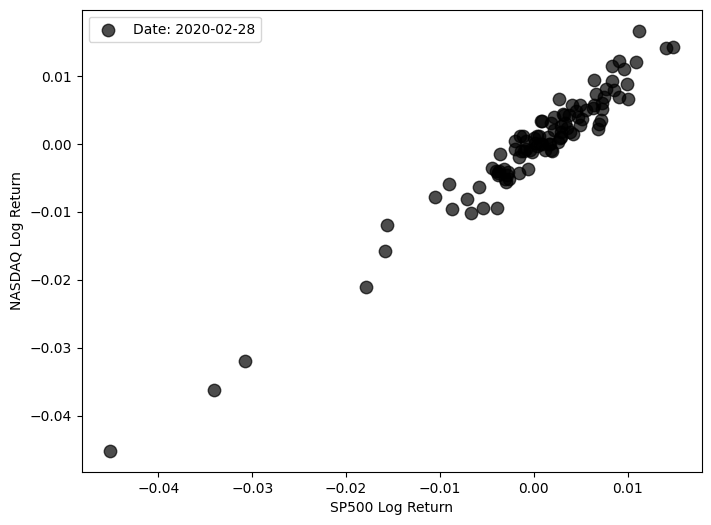

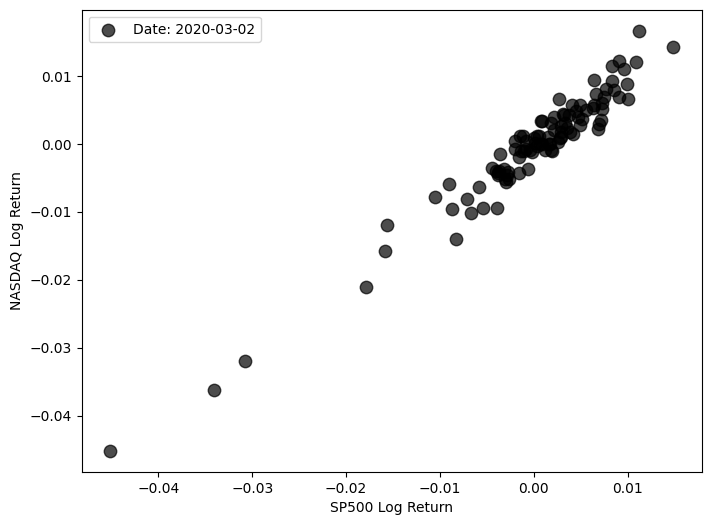

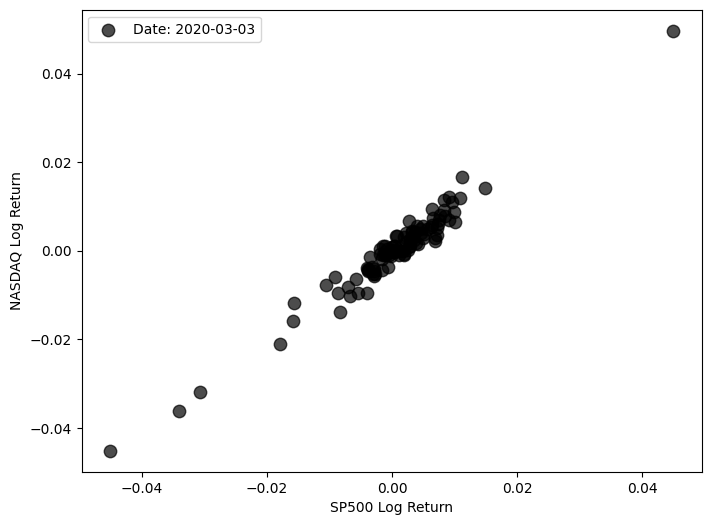

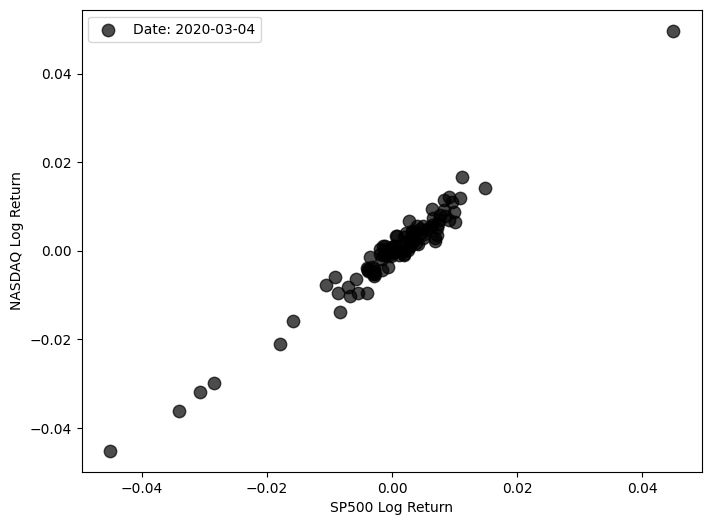

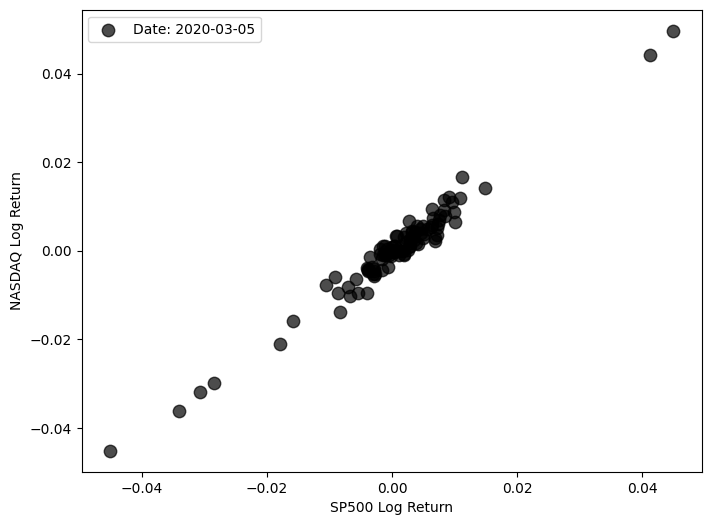

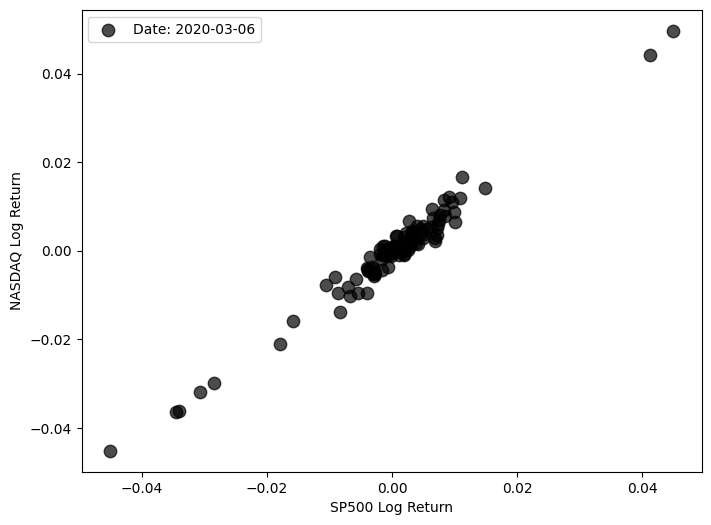

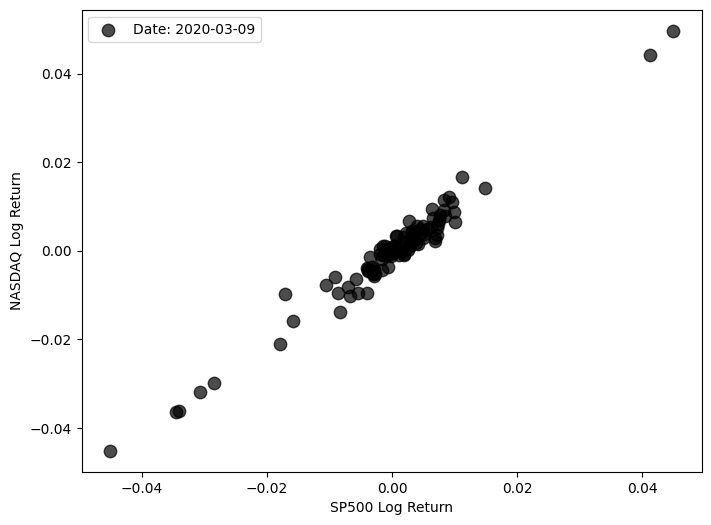

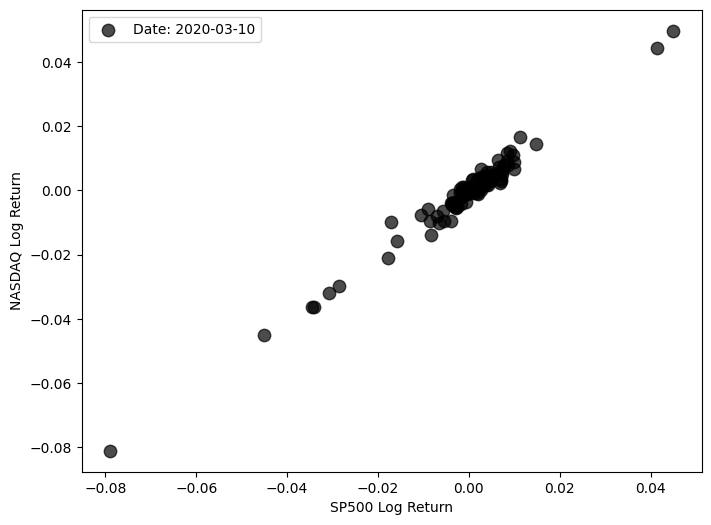

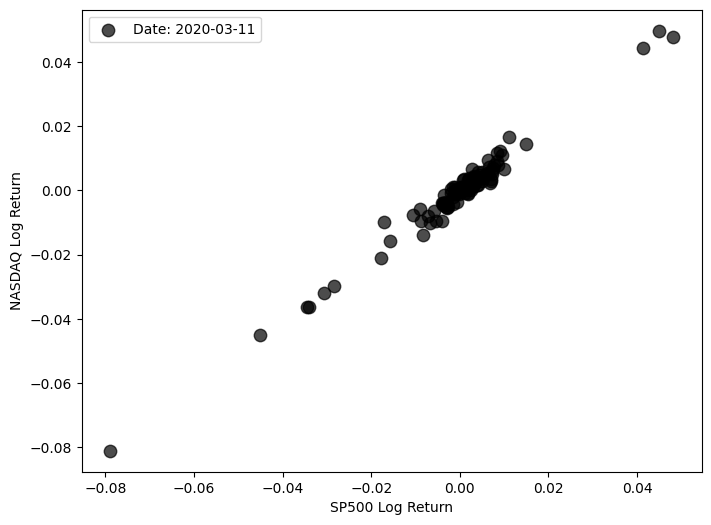

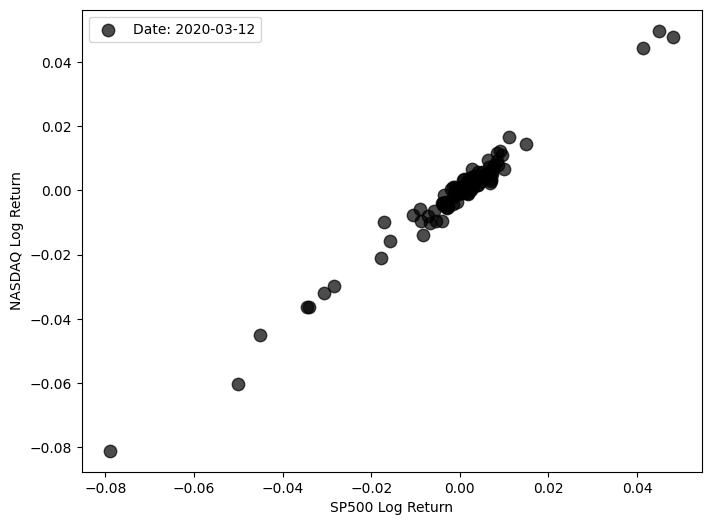

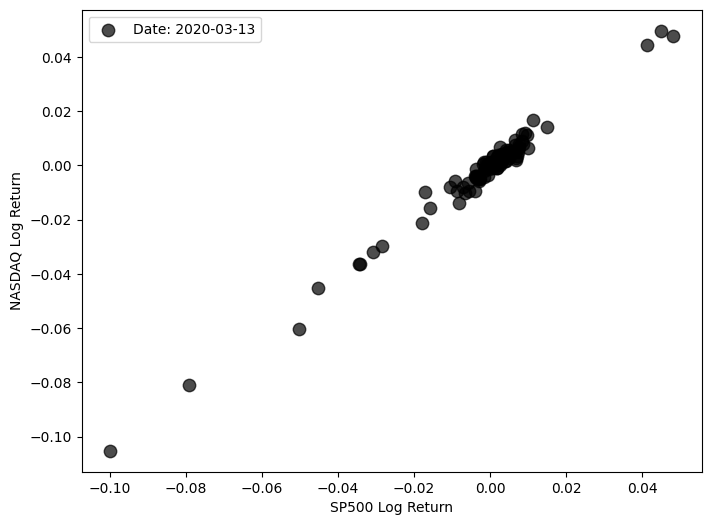

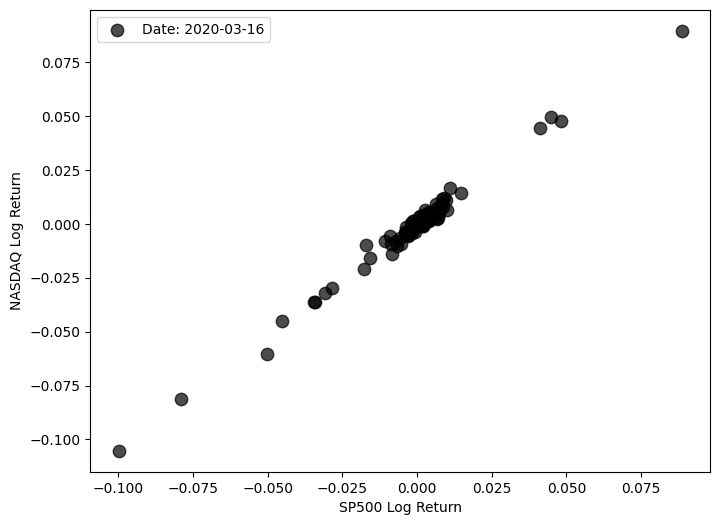

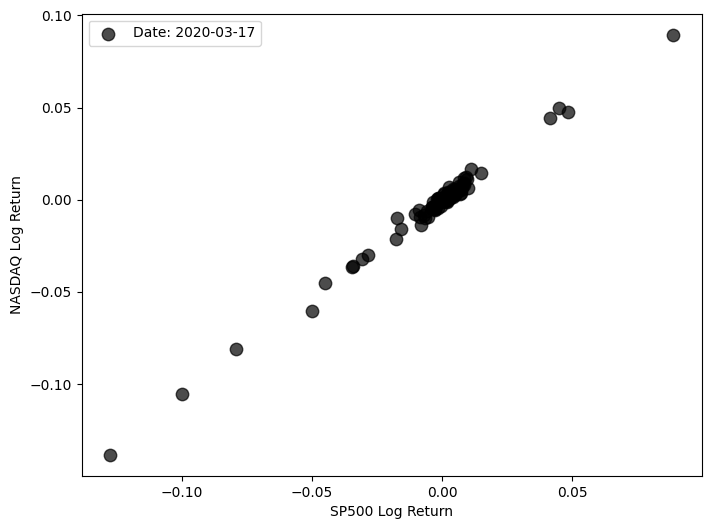

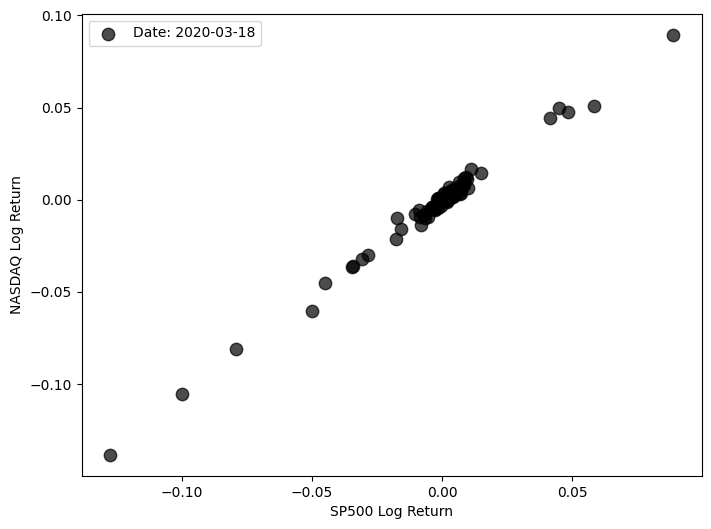

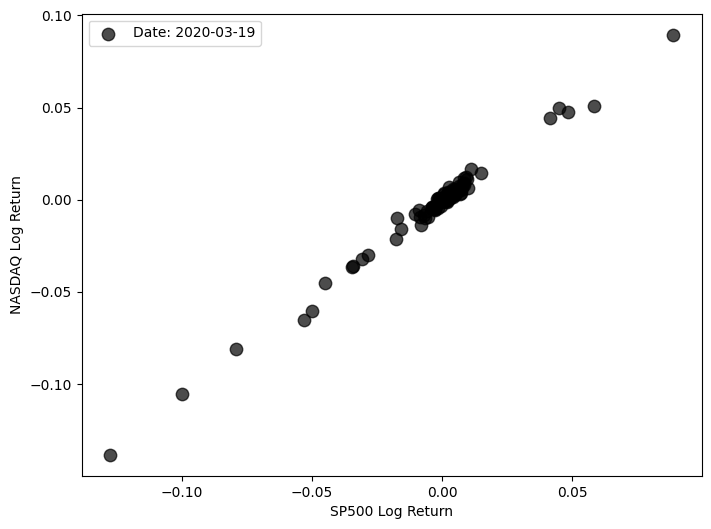

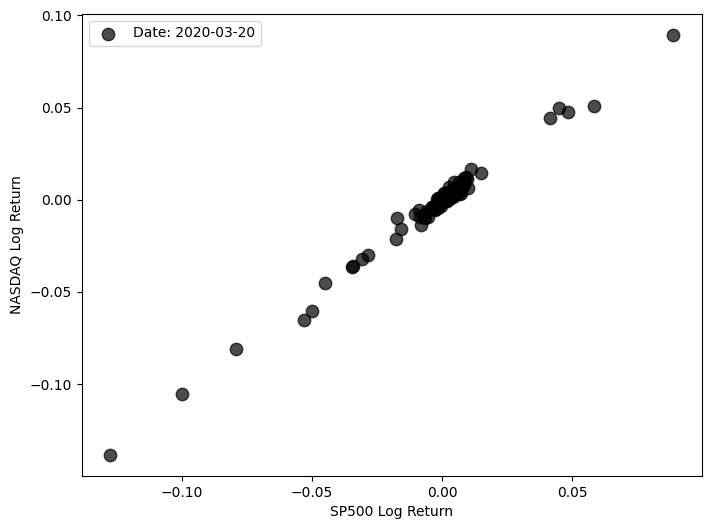

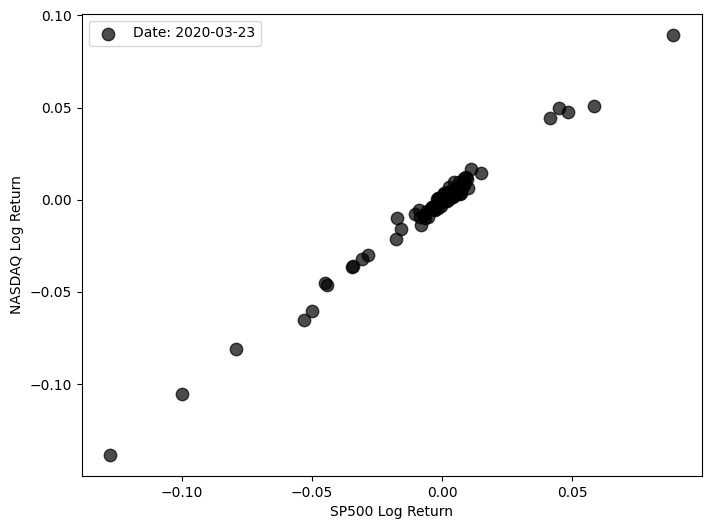

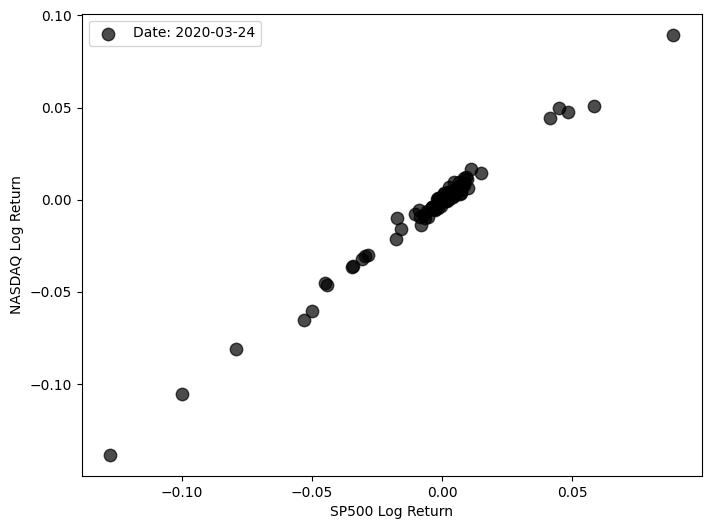

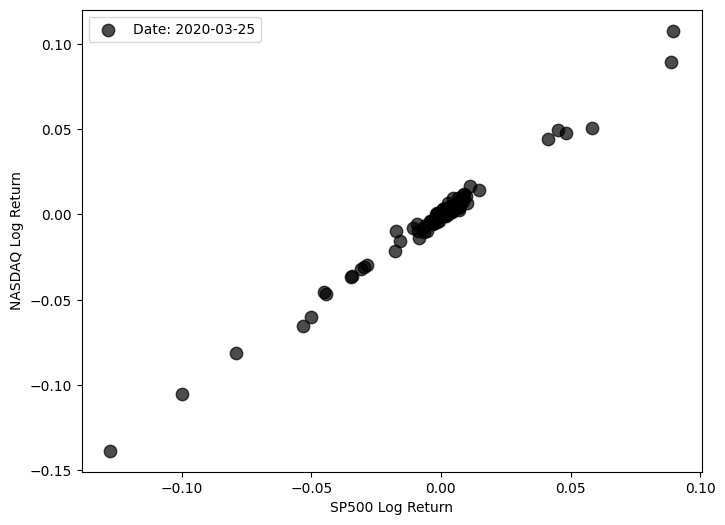

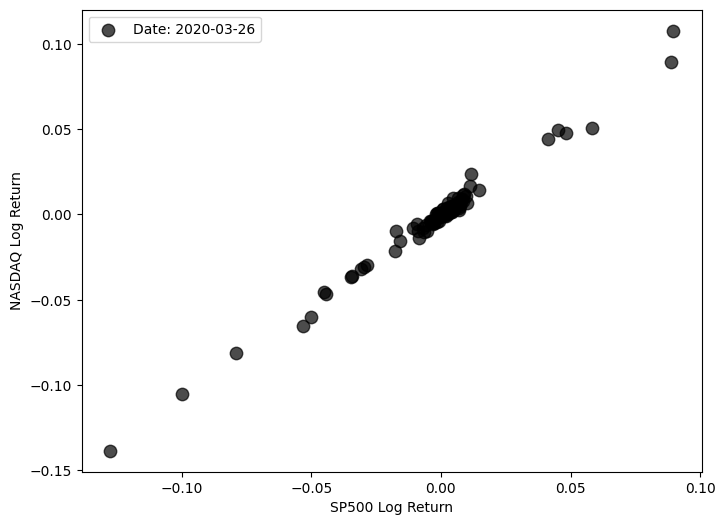

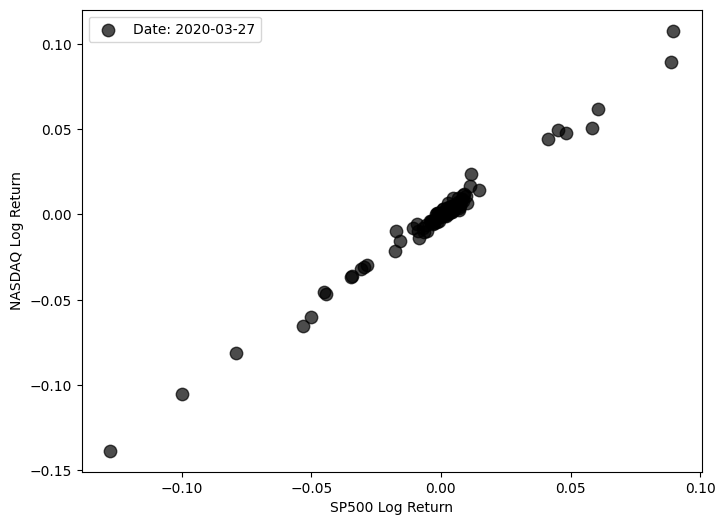

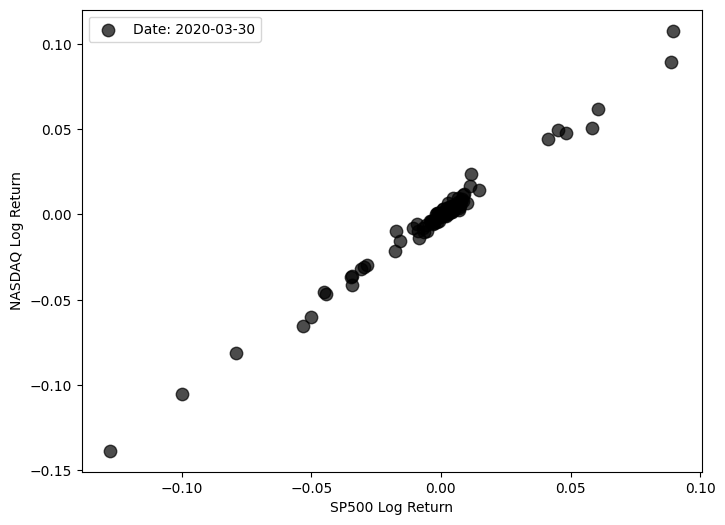

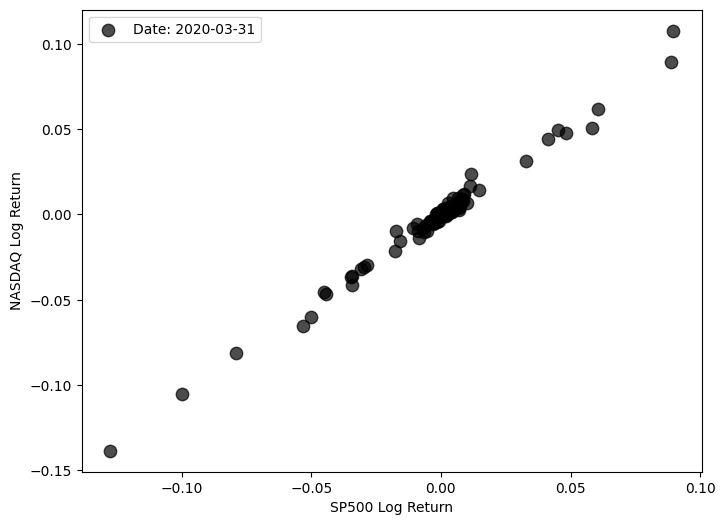

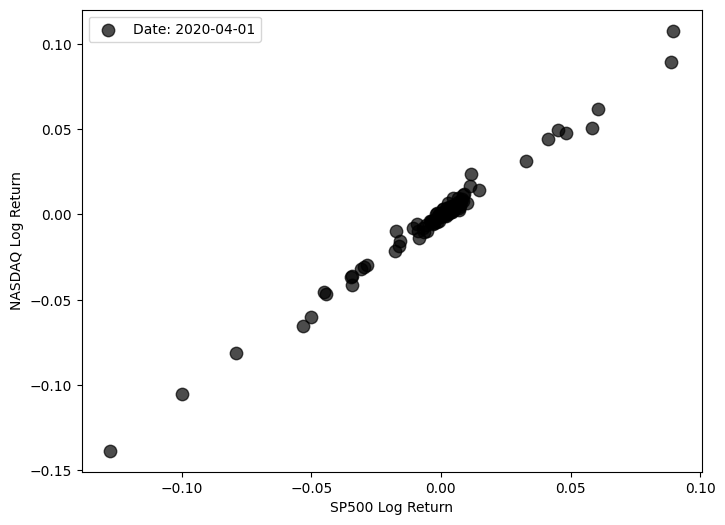

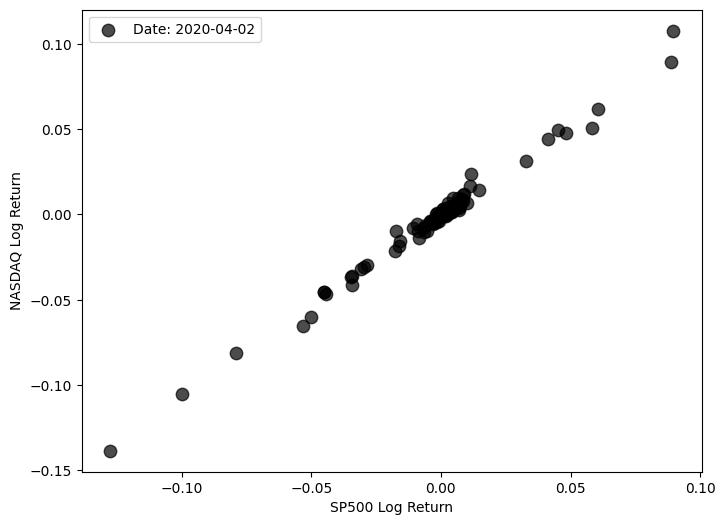

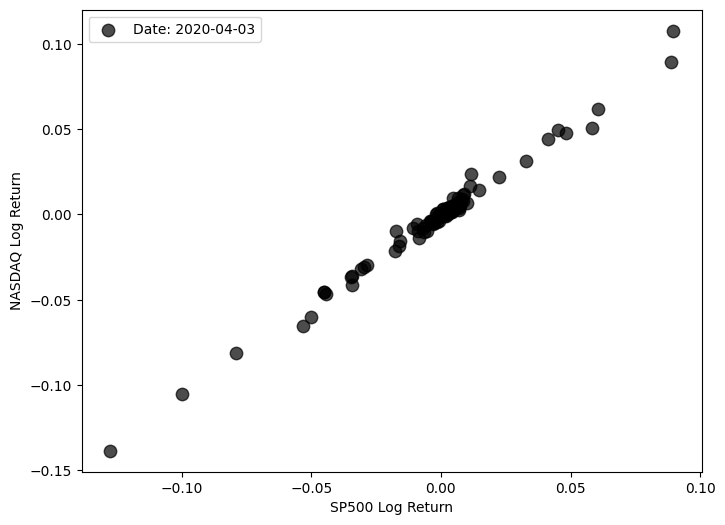

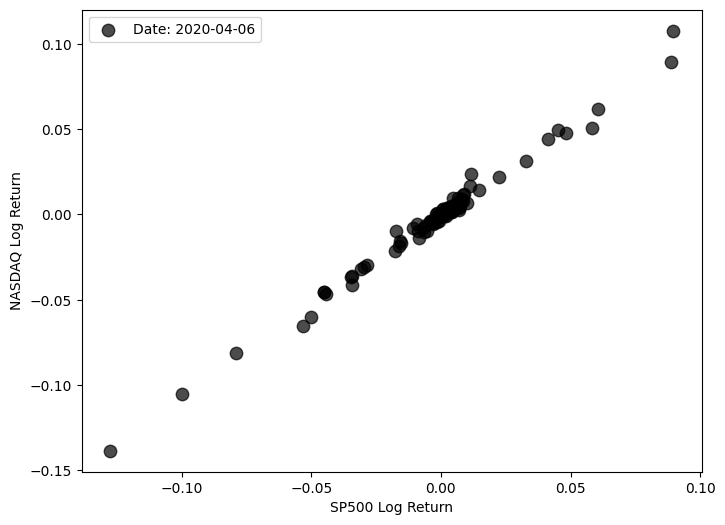

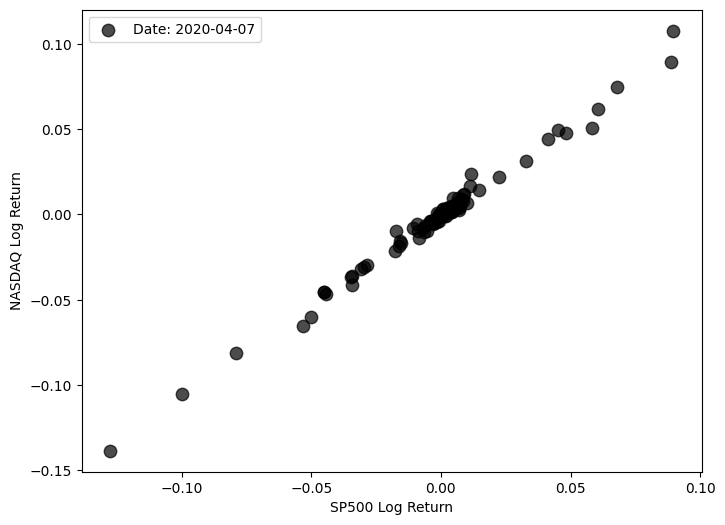

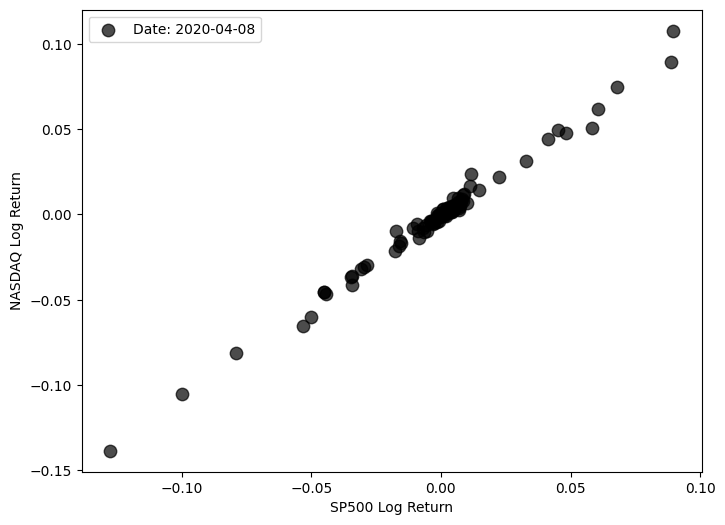

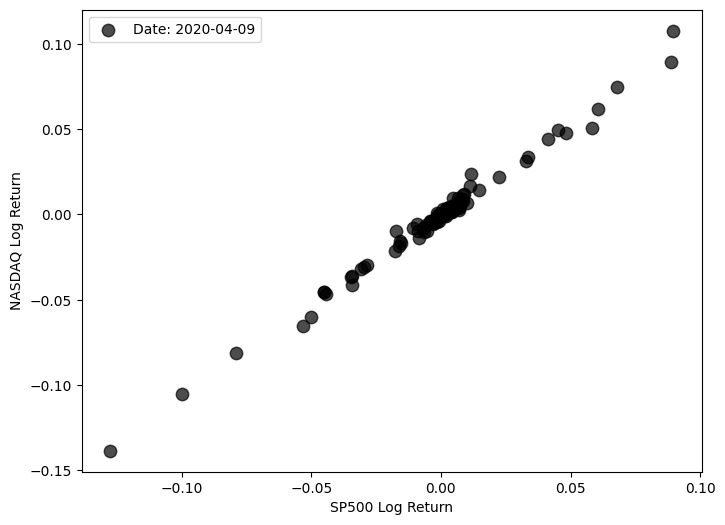

100%|██████████| 2384/2384 [00:07<00:00, 333.96it/s]


In [29]:
# compute persistence diagrams over sliding windows
w = 100 # window size
diagrams_returns = []
j = 0

covid_date = pd.Timestamp("2020-03-11")
for i in tqdm(range(w, len(log_returns))):
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if np.abs(log_returns.index[i] - covid_date) < pd.Timedelta(days=30):
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        date = log_returns.index[i]
        plt.scatter(window[:, 0], window[:, 1], c='black', s=80, alpha=0.7, label=f'Date: {date.date()}')
        plt.xlabel("SP500 Log Return")
        plt.ylabel("NASDAQ Log Return")
        plt.legend()
        if j % 10 == 0:
            plt.savefig(f"plots/covid_pointcloud_{j}.png", dpi=300)
        plt.show()
        j += 1

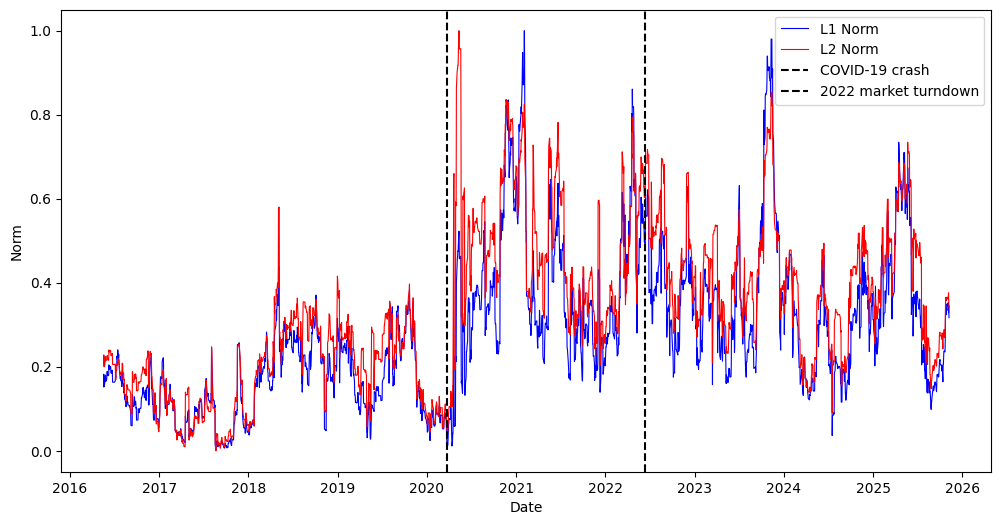

In [ ]:
# compute the persistence landscapes L^1 and L^2 norms for log-returns
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# plot the L^1 and L^2 norms of the persistence landscapes over time
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.axvline(pd.Timestamp('2020-03-23'), color='black', linestyle='--', label='COVID-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='BLACK', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Norm")
plt.legend()
plt.savefig("plots/covid_norms.png", dpi=300)
plt.show()

In [31]:
# change point detection on L2 norm time series
l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=4)

In [32]:
# find the index corresponding to covid crash and 2022 market turndown
covid_index = np.where(dates[w:] == pd.Timestamp('2020-03-23'))[0][0]
crash2022_index = np.where(dates[w:] == pd.Timestamp('2022-06-13'))[0][0]

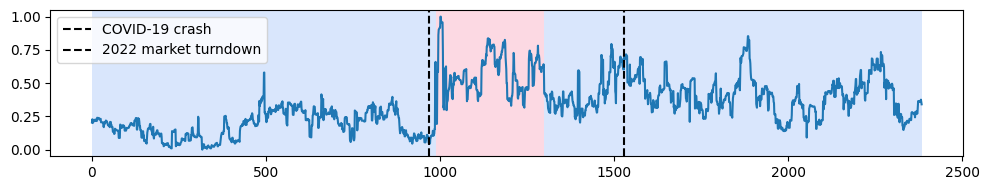

In [33]:
rpt.display(l2_signal, result)
plt.axvline(covid_index, color='black', linestyle='--', label='COVID-19 crash')
plt.axvline(crash2022_index, color='black', linestyle='--', label='2022 market turndown')
plt.legend()
plt.savefig("plots/covid_norms_changepoints.png", dpi=300)
plt.show()

In [34]:
# find the dates of the detected change points
change_point_dates = [dates[w + cp] for cp in result[:-1]]
print("Detected Change Points Dates:")
for date in change_point_dates:
    print(date)

# print Covid-19 market crash and 2022 market turndown dates
print("COVID-19 market crash date:", dates[covid_index])
print("2022 market turndown date:", dates[crash2022_index])

Detected Change Points Dates:
2020-04-24 00:00:00
2021-07-19 00:00:00
COVID-19 market crash date: 2019-10-28 00:00:00
2022 market turndown date: 2022-01-19 00:00:00


In [35]:
# compute statistical features on L2 norm time series
window_size = 500
variances = []
avg_spectral_densities = []
firstlags = []

for i in tqdm(range(window_size, len(l2_norms_returns))):
    window = pd.Series(l2_norms_returns[i-window_size:i])
    
    variance = window.var()
    variances.append(variance)
    
    f, Pxx = welch(window.values, fs=1.0)
    low_freq_indices = f < 0.1
    avg_spectral_density = Pxx[low_freq_indices].mean()
    avg_spectral_densities.append(avg_spectral_density)

    # first lag of the Auto-Correlation Function (ACF)
    acf_values = sm.tsa.acf(window.values, nlags=1, fft=True)
    firstlag = acf_values[1].mean()
    firstlags.append(firstlag)

100%|██████████| 1884/1884 [00:00<00:00, 5337.43it/s]


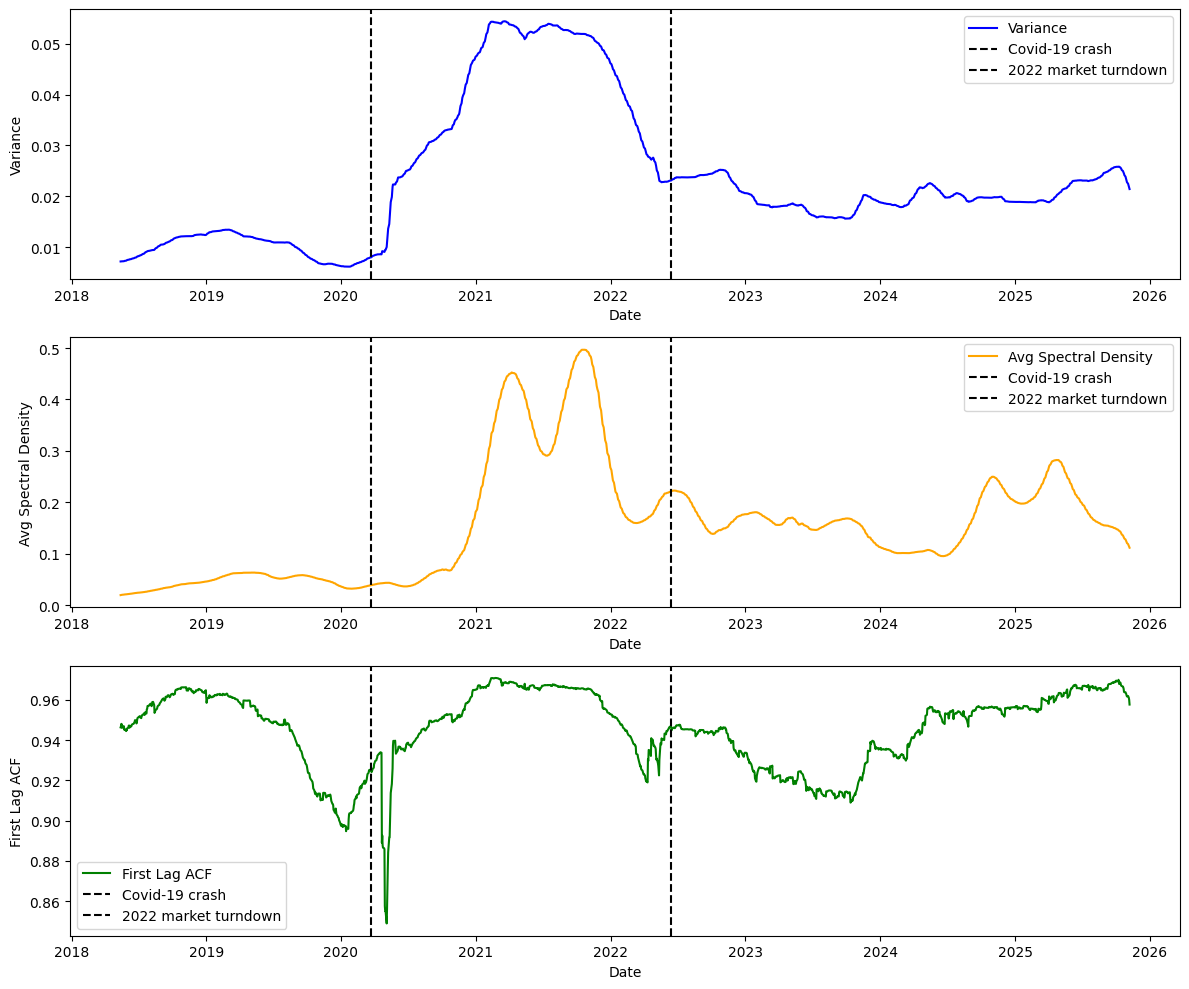

In [36]:
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(dates[window_size+100:], variances, label='Variance', color='blue')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(dates[window_size+100:], avg_spectral_densities, label='Avg Spectral Density', color='orange')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Avg Spectral Density")
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(dates[window_size+100:], firstlags, label='First Lag ACF', color='green')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("First Lag ACF")
plt.tight_layout()
plt.savefig("plots/covid_l2_features.png", dpi=300)
plt.legend()
plt.show()

# Empirical analysis of financial data (ETF) - Covid-19 crisis and 2022 market turndown

In [37]:
# download financial data : sector ETFs and VIX
tickers = ['XLY', 'XLP', 'XLE', 'XLF', 'XLV', 'XLI', 'XLB', 'XLK', 'XLU', 'SPY', '^VIX']
data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']

C:\Users\eliot\AppData\Local\Temp\ipykernel_15088\495045260.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start='2015-12-23', end='2025-11-08')['Close']
[*********************100%***********************]  11 of 11 completed


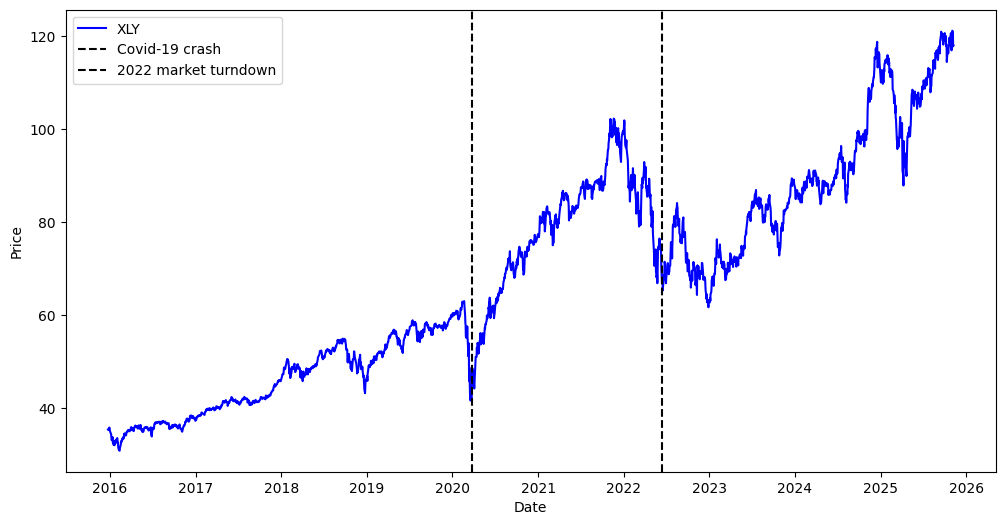

In [38]:
# plot SP500 time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['XLY'], label='XLY', color='blue')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.savefig("plots/covid_xly.png", dpi=300)
plt.show()

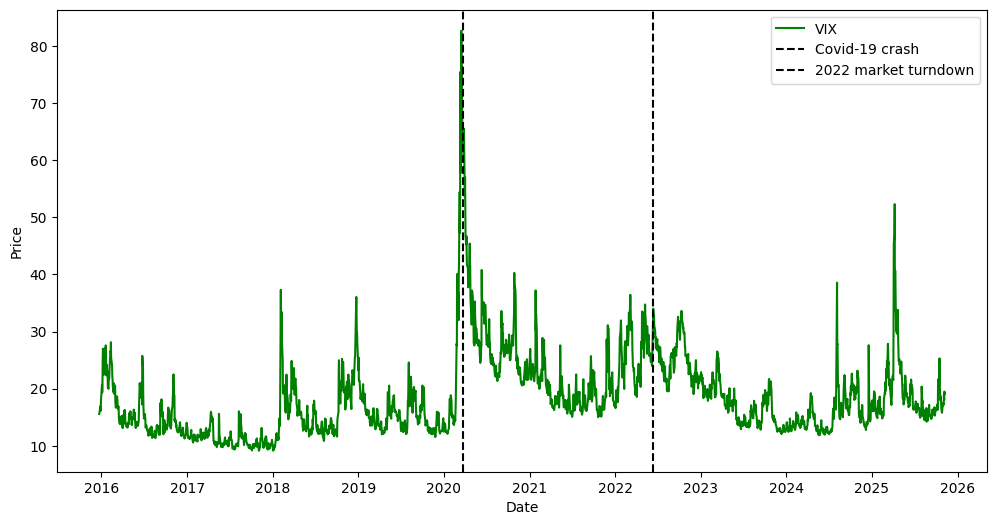

In [39]:
# plot VIX time series
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['^VIX'], label='VIX', color='green')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

In [40]:
# calculate log returns for all tickers except VIX
log_returns = np.log(data[tickers[:-1]] / data[tickers[:-1]].shift(1)).fillna(0)

 37%|███▋      | 890/2384 [00:01<00:02, 518.11it/s]

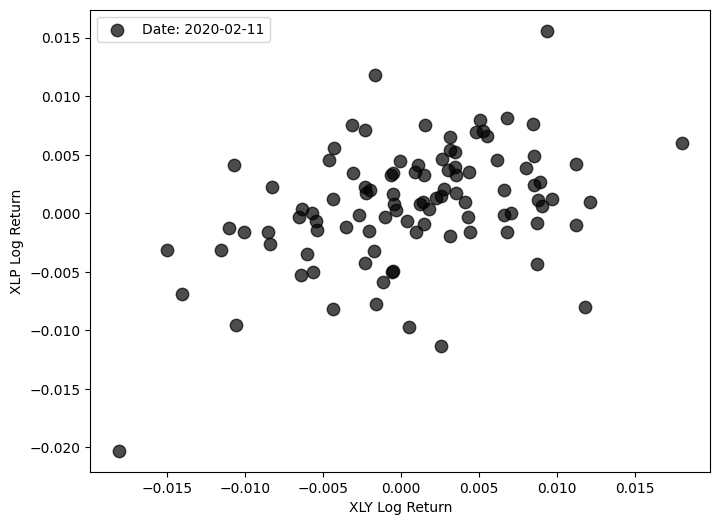

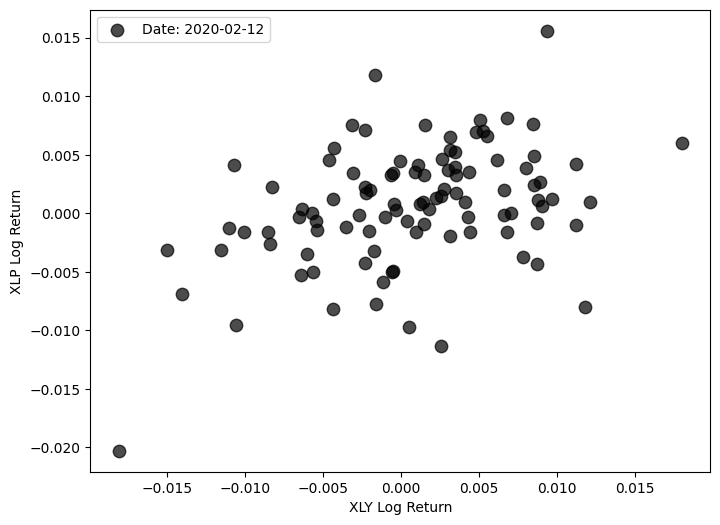

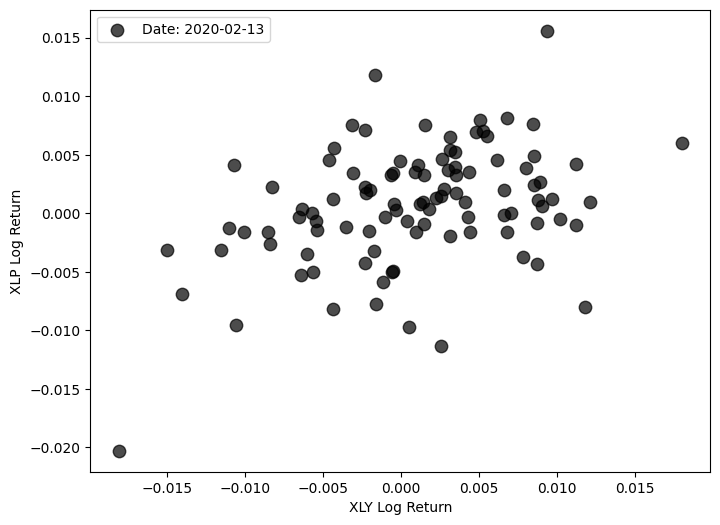

 40%|███▉      | 942/2384 [00:02<00:05, 266.19it/s]

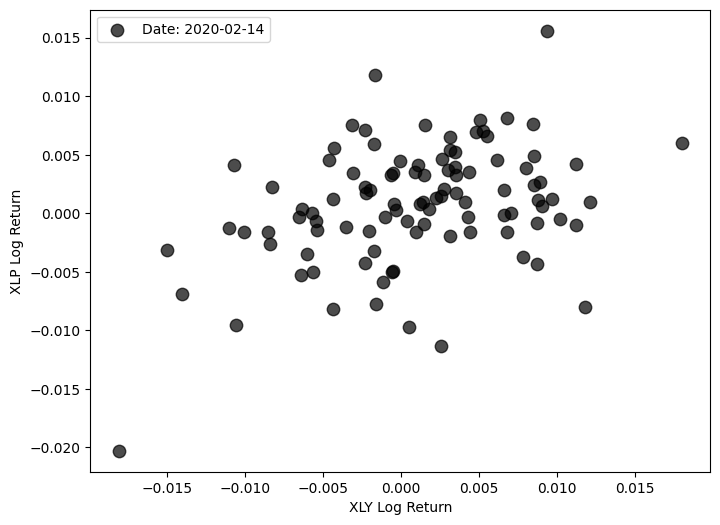

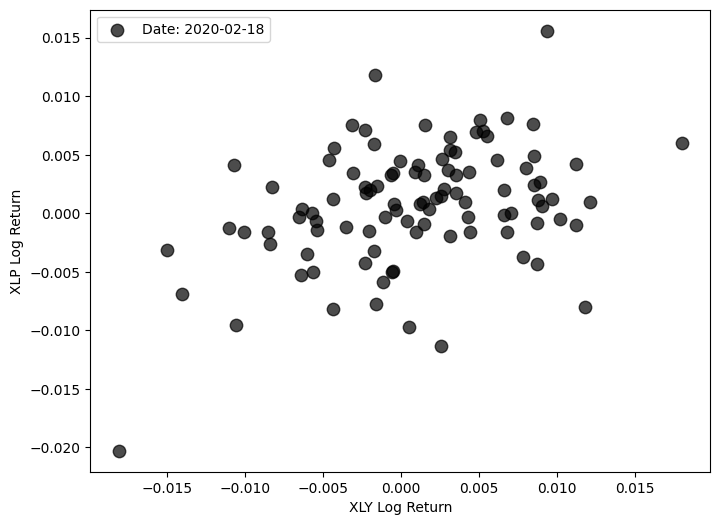

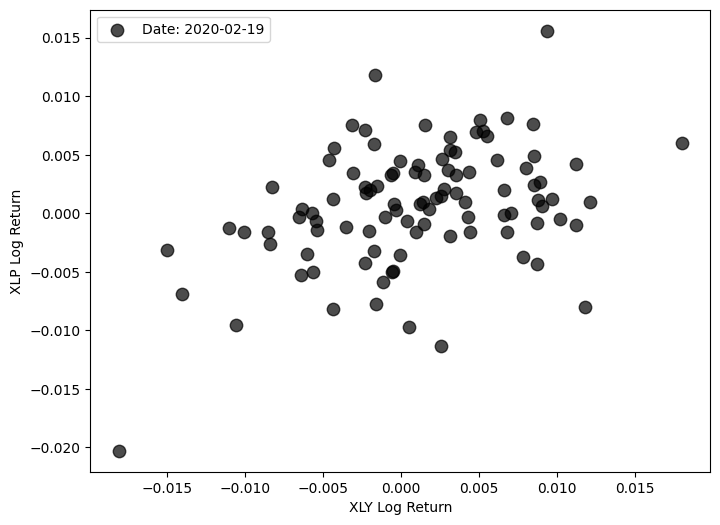

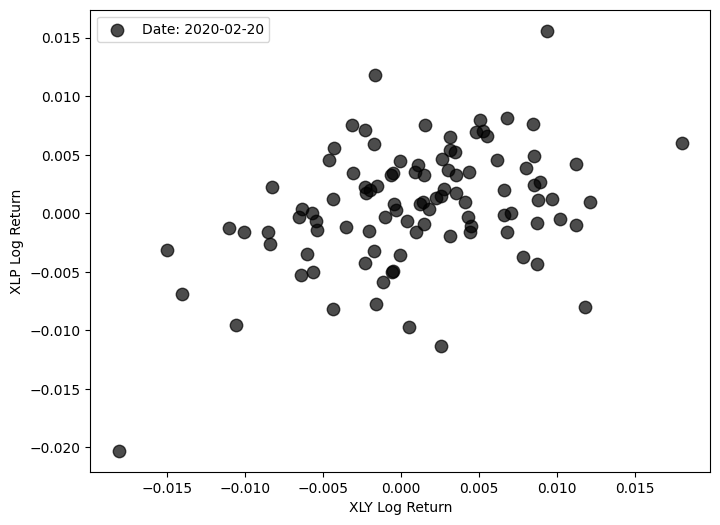

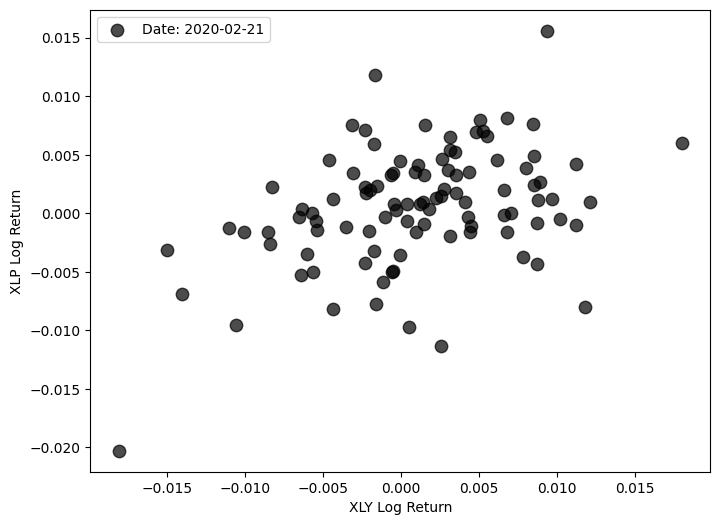

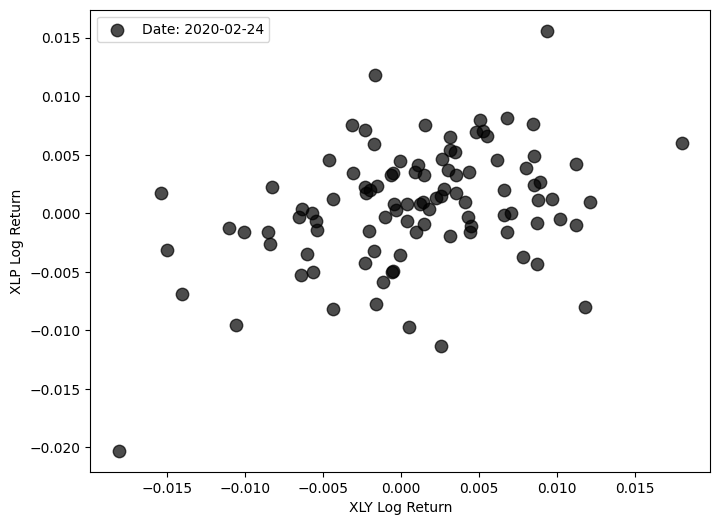

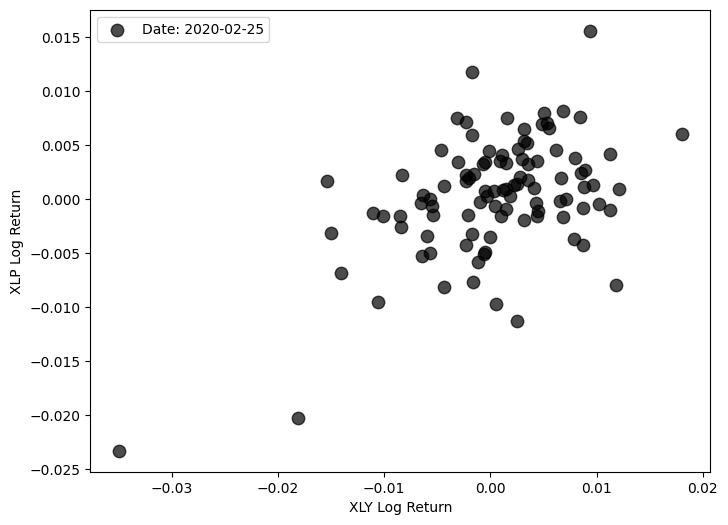

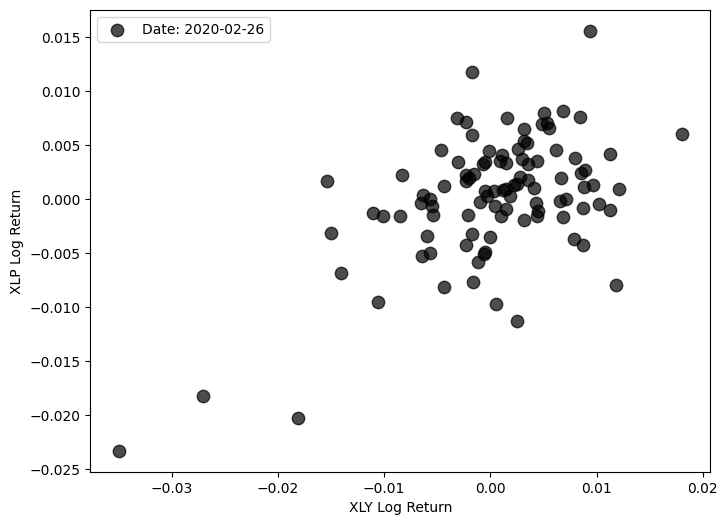

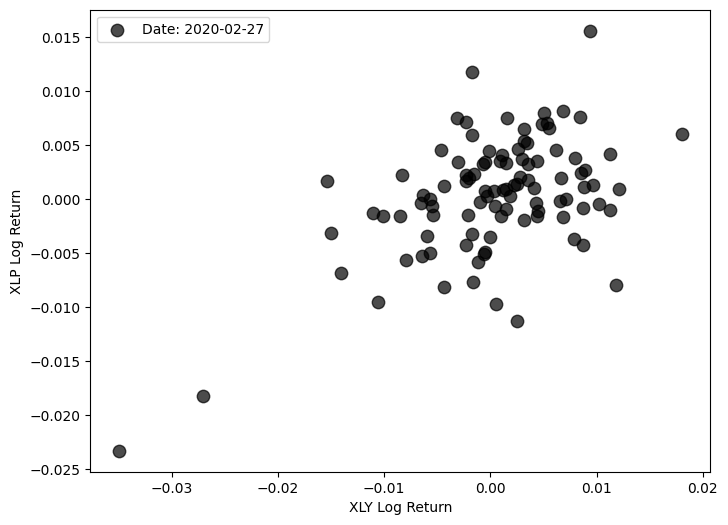

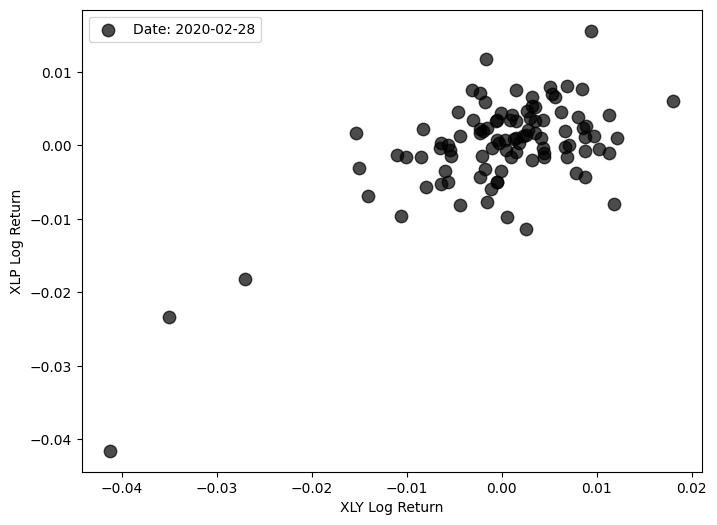

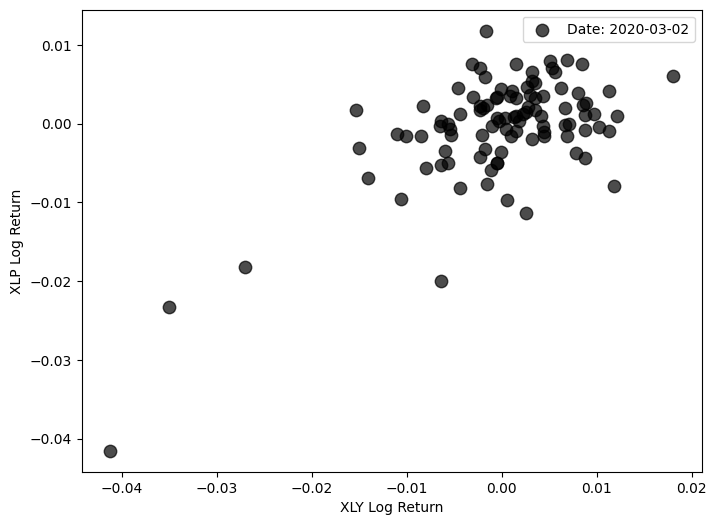

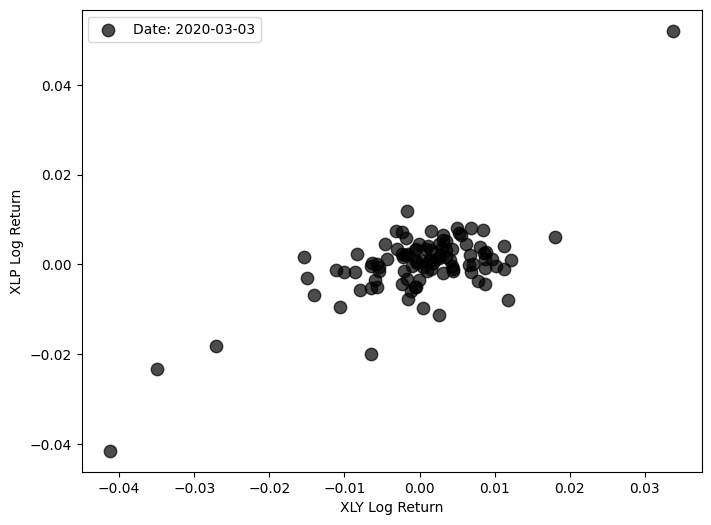

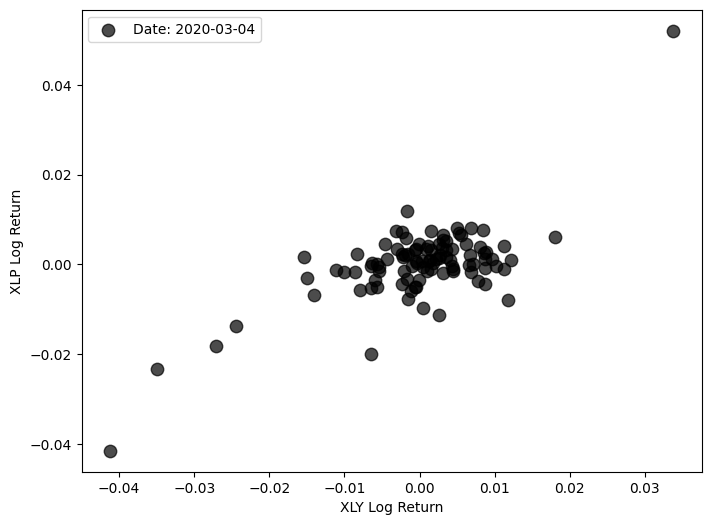

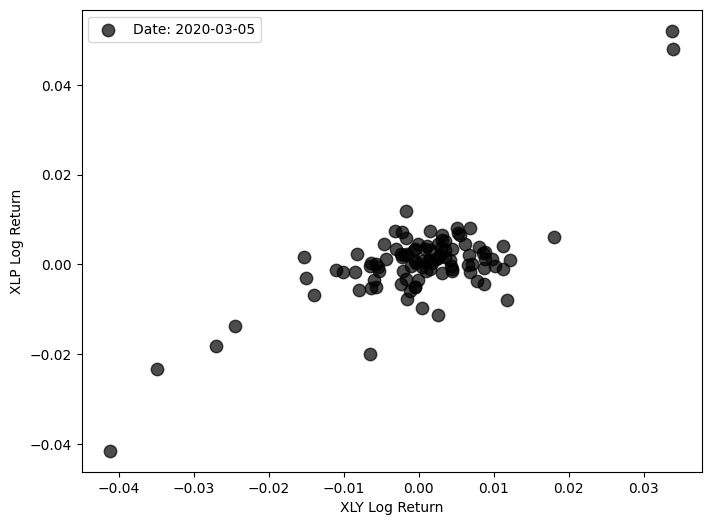

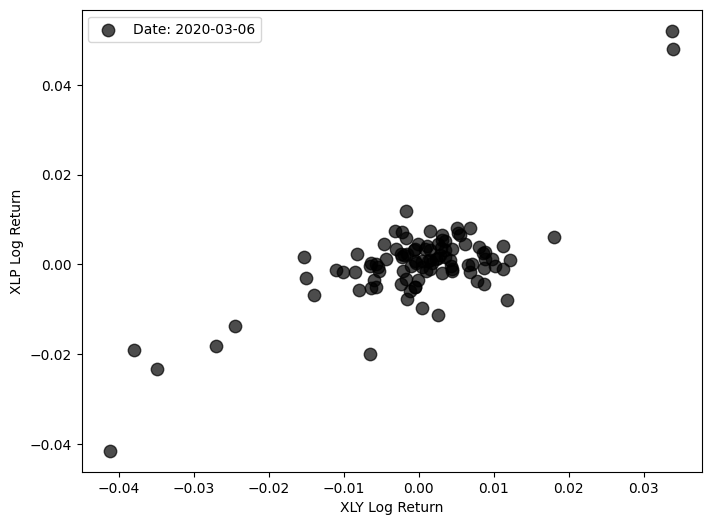

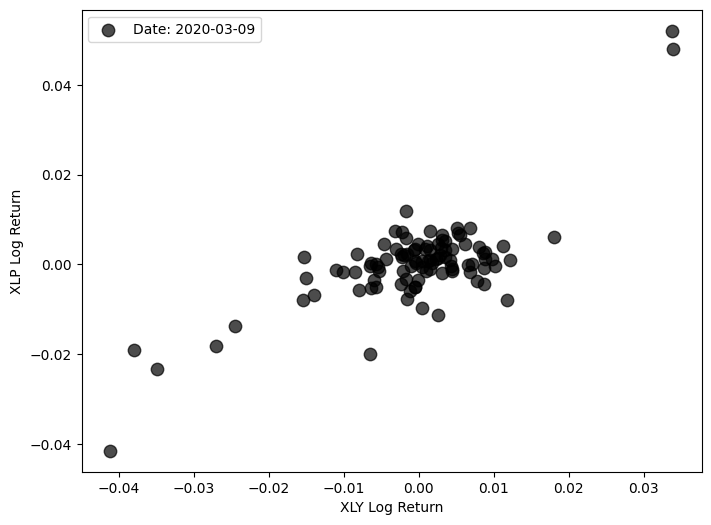

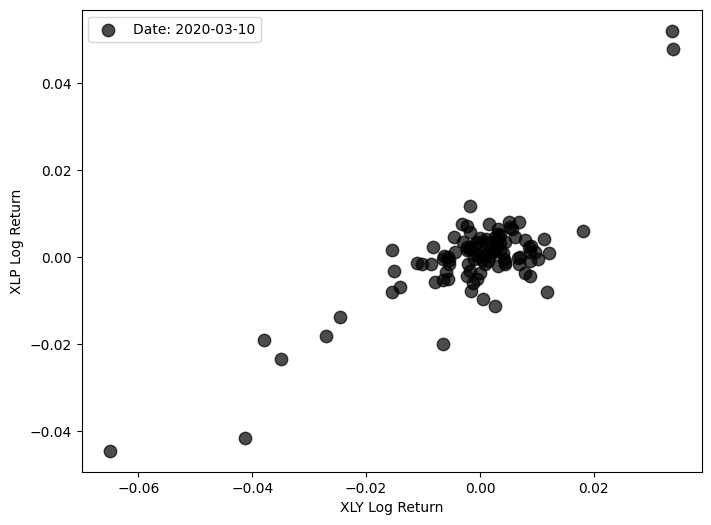

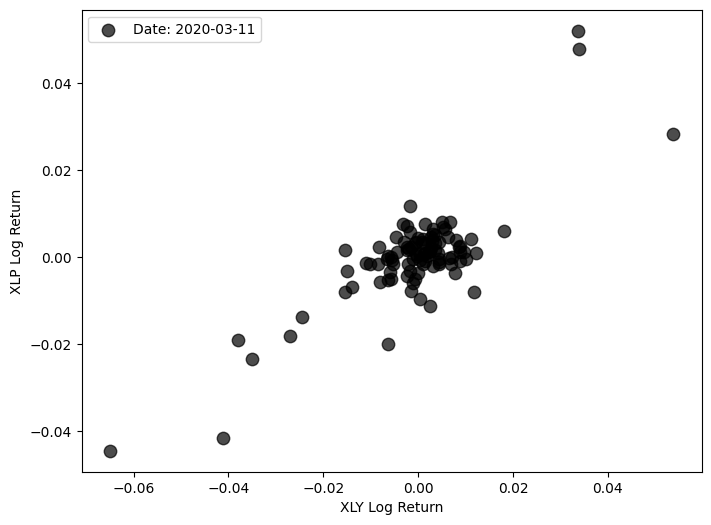

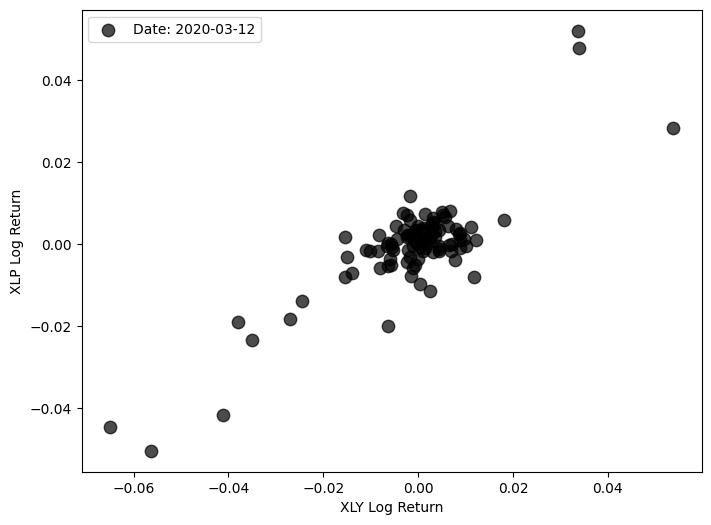

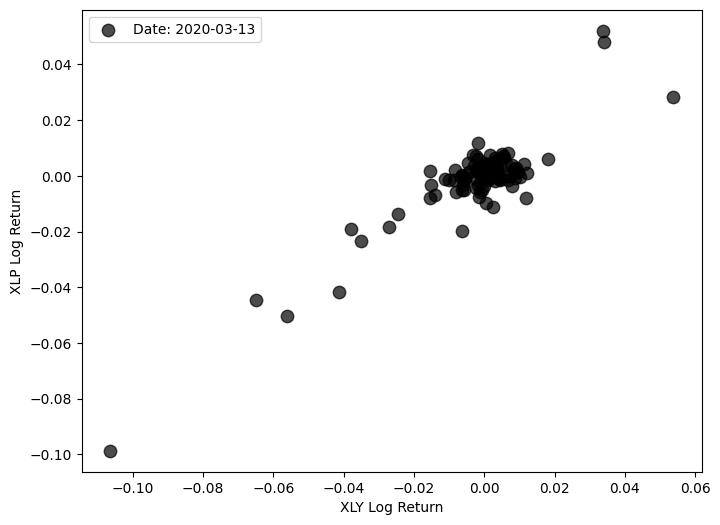

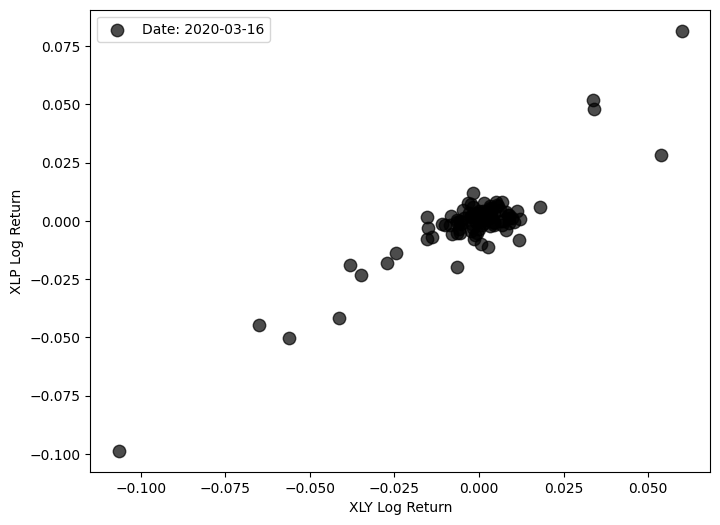

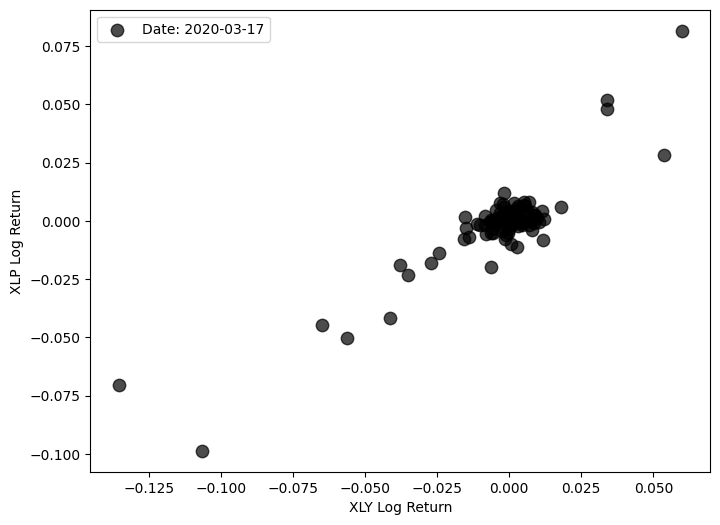

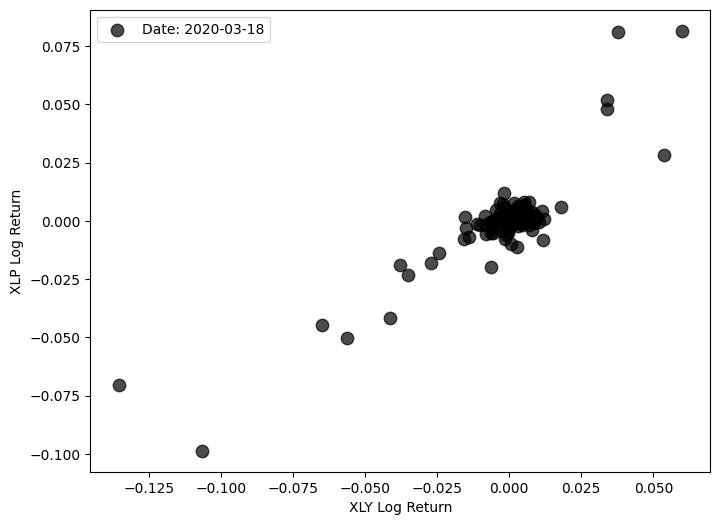

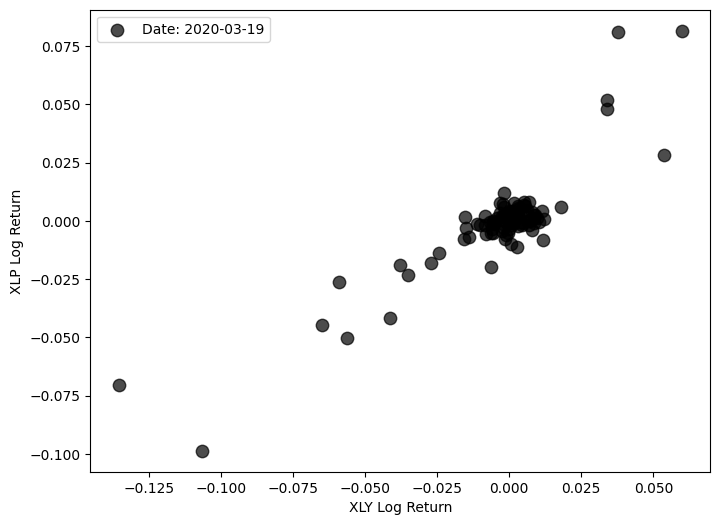

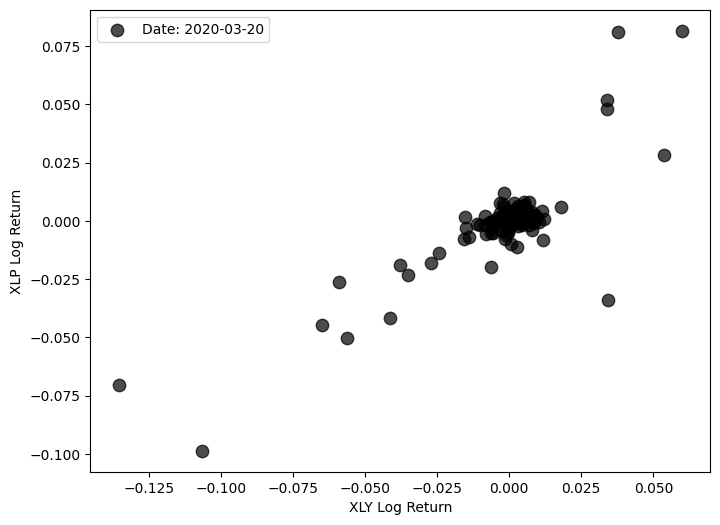

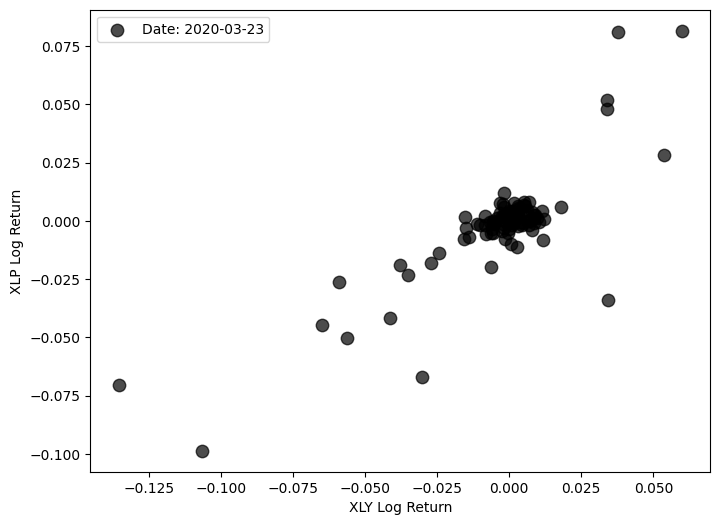

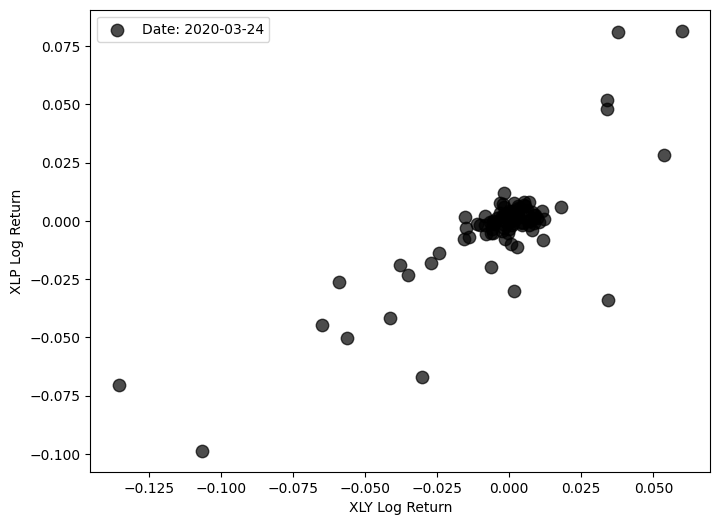

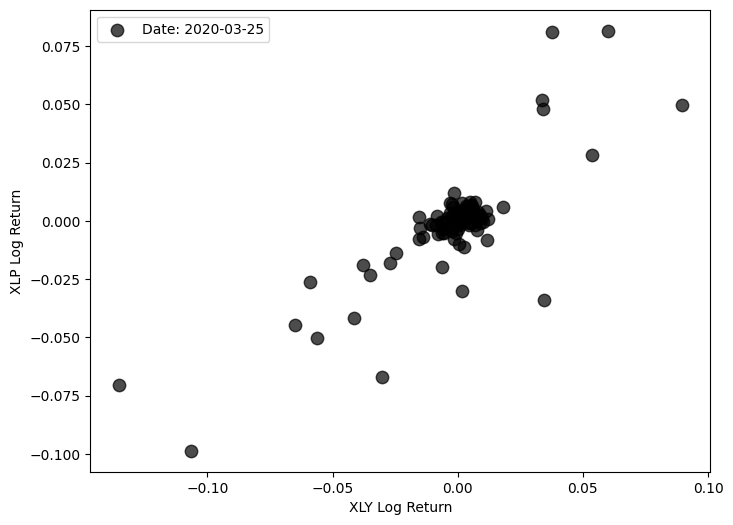

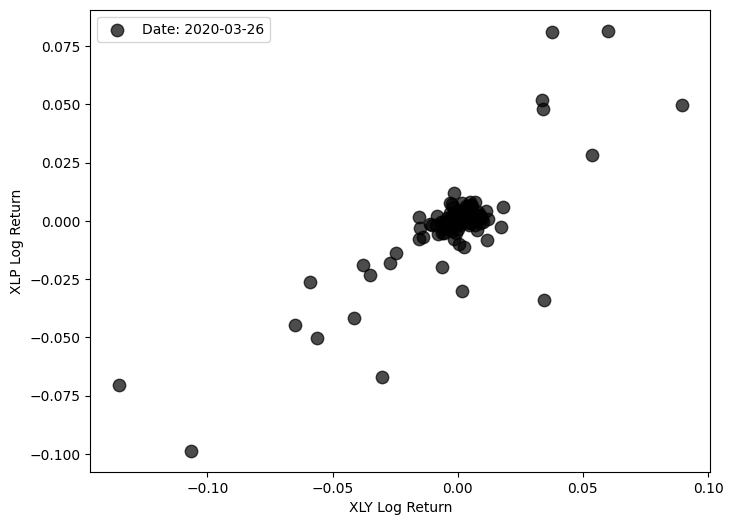

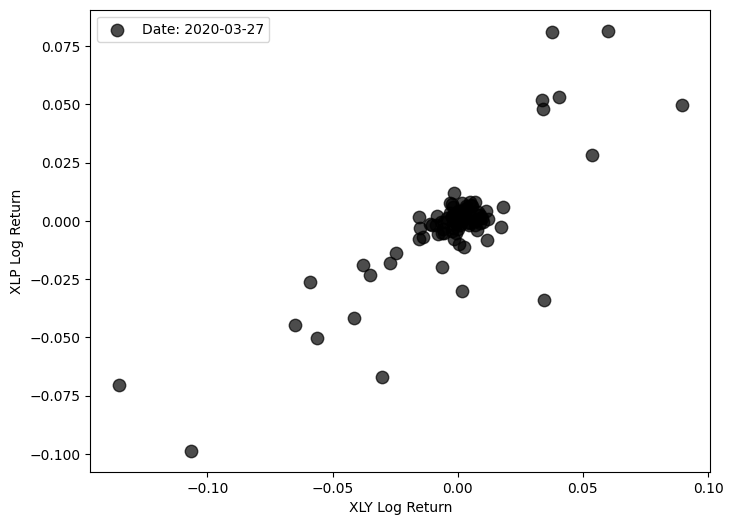

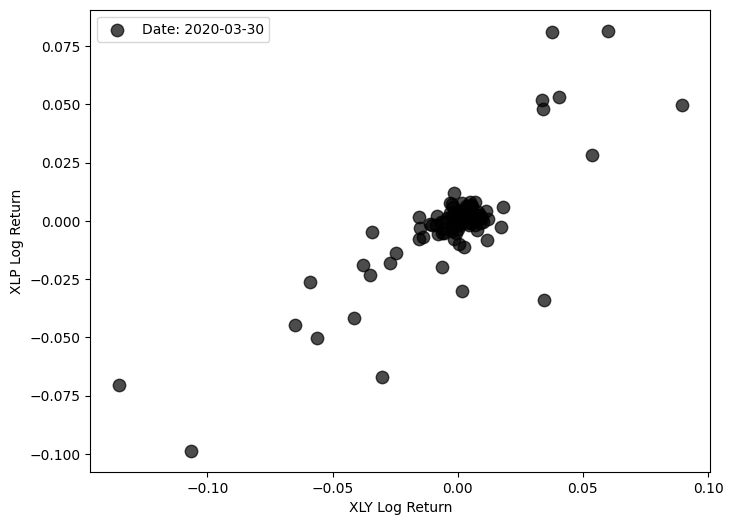

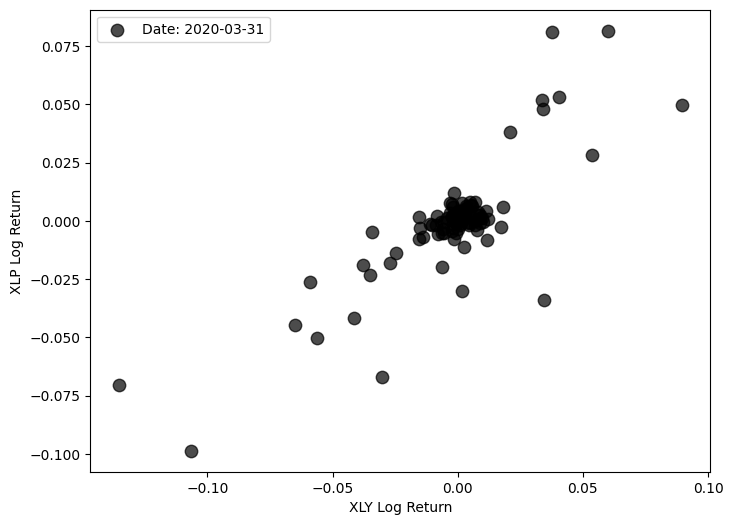

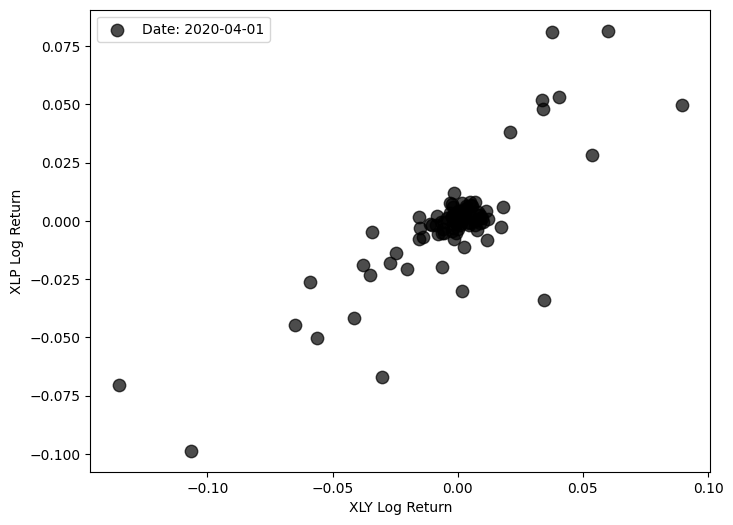

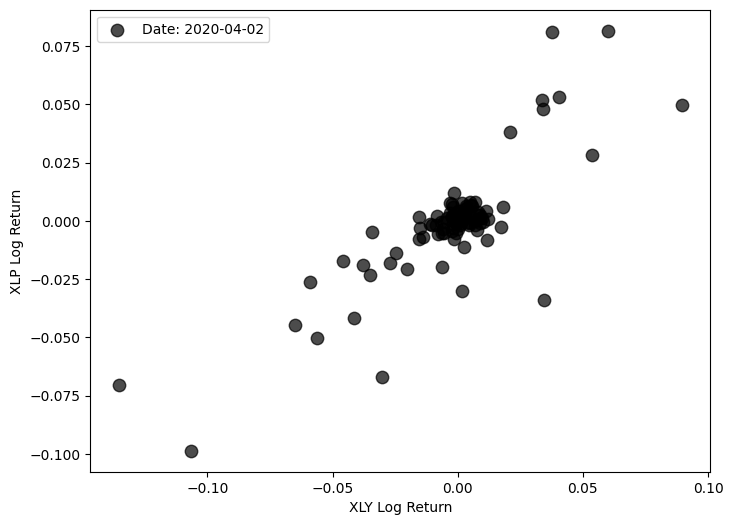

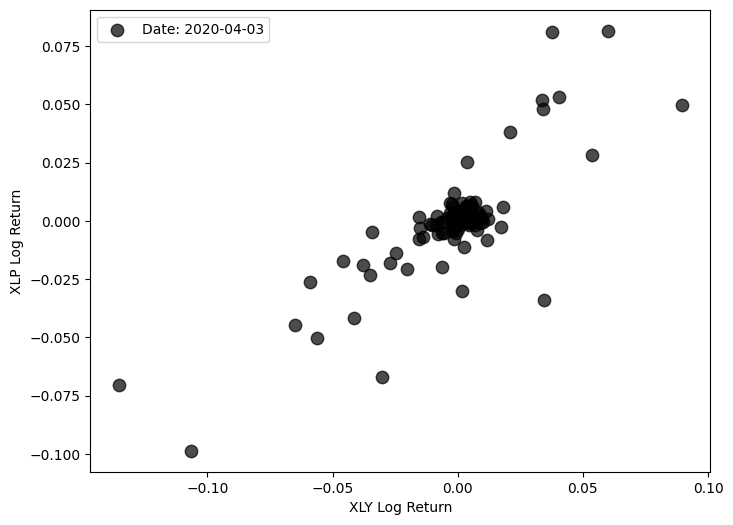

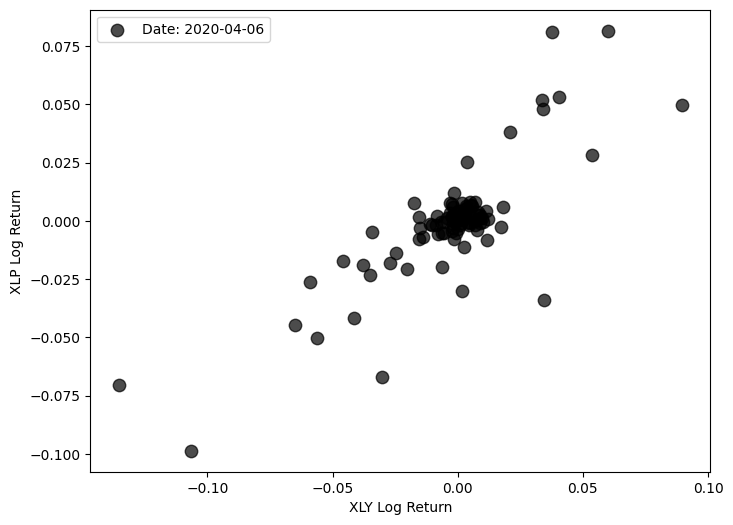

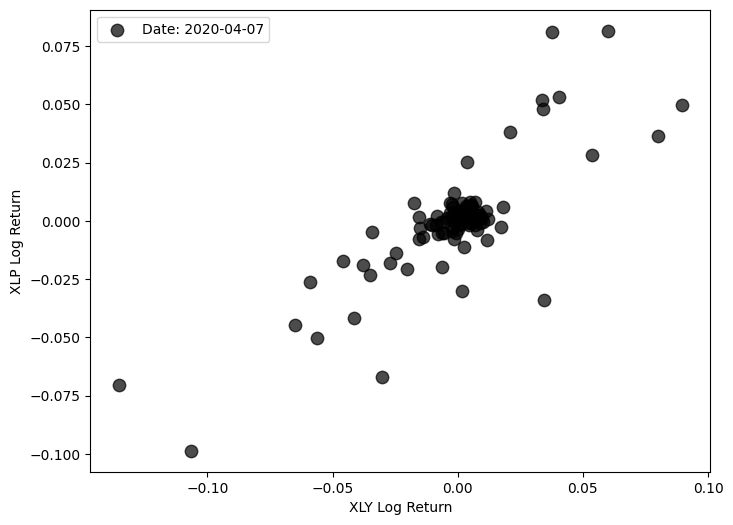

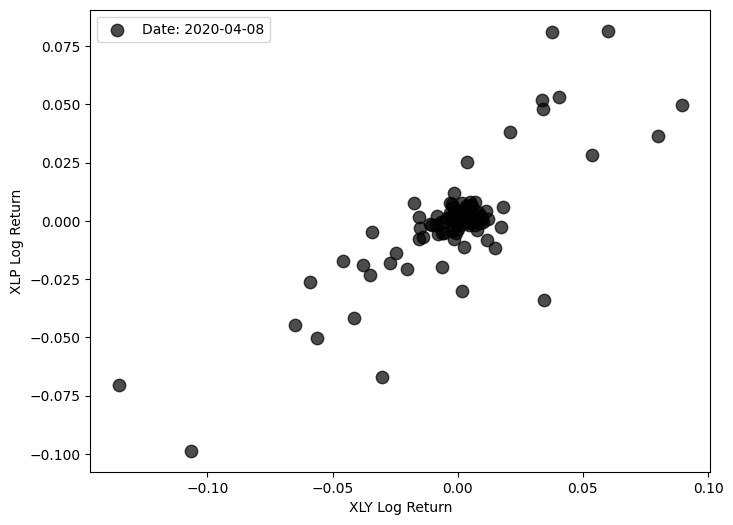

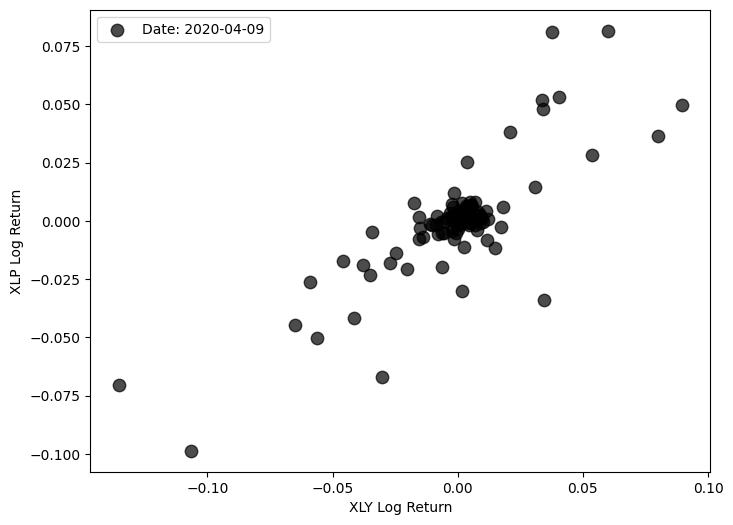

100%|██████████| 2384/2384 [00:07<00:00, 318.40it/s]


In [41]:
# compute persistence diagrams over sliding windows
w = 100 # window size
diagrams_returns = []
j = 0

covid_date = pd.Timestamp("2020-03-11")
for i in tqdm(range(w, len(log_returns))):
    window = log_returns.iloc[i-w:i].values  # shape (w, 4)
    rips = ripser.ripser(window)
    diagrams_returns.append(rips['dgms'])

    if np.abs(log_returns.index[i] - covid_date) < pd.Timedelta(days=30):
        # plot the point cloud of the current window
        plt.figure(figsize=(8, 6))
        date = log_returns.index[i]
        plt.scatter(window[:, 0], window[:, 1], c='black', s=80, alpha=0.7, label=f'Date: {date.date()}')
        plt.xlabel("XLY Log Return")
        plt.ylabel("XLP Log Return")
        plt.legend()
        if j % 10 == 0:
            plt.savefig(f"plots/covid_pointcloud_etf_{j}.png", dpi=300)
        plt.show()
        j += 1

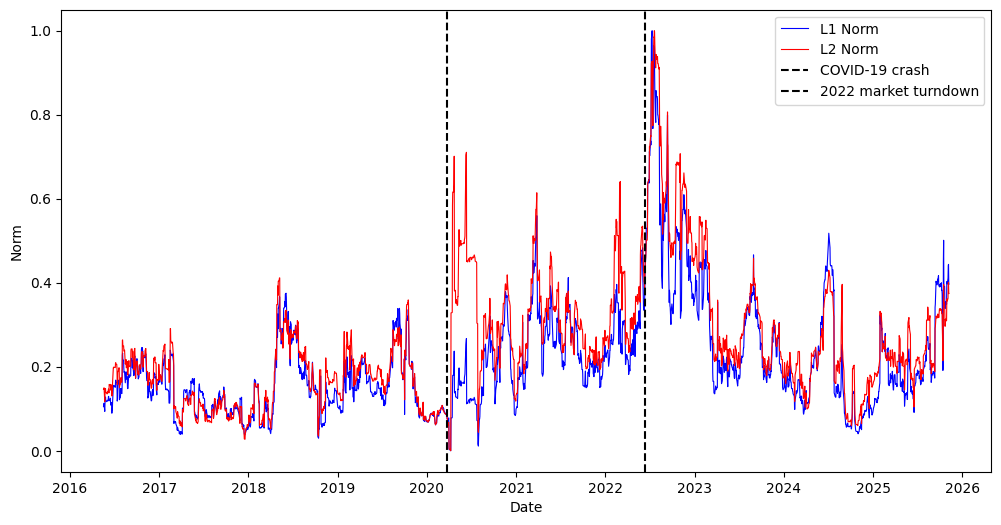

In [ ]:
# compute the persistence landscapes L^1 and L^2 norms for log-returns
l1_norms_returns = []
l2_norms_returns = []
for diag in diagrams_returns:
    pl = grepr.Landscape(num_landscapes=10, resolution=500)
    landscape = pl.fit_transform([diag[1]])[0]
    l1_norms_returns.append(np.sum(np.abs(landscape)))
    l2_norms_returns.append(np.sqrt(np.sum(landscape**2)))

# normalize the norms
l1_norms_returns = (np.array(l1_norms_returns) - np.min(l1_norms_returns)) / (np.max(l1_norms_returns) - np.min(l1_norms_returns))
l2_norms_returns = (np.array(l2_norms_returns) - np.min(l2_norms_returns)) / (np.max(l2_norms_returns) - np.min(l2_norms_returns))

dates = log_returns.index

# plot the L^1 and L^2 norms of the persistence landscapes over time
plt.figure(figsize=(12, 6))
plt.plot(dates[w:], l1_norms_returns, label='L1 Norm', color='blue', linewidth=0.8)
plt.plot(dates[w:], l2_norms_returns, label='L2 Norm', color='red', linewidth=0.8)
plt.axvline(pd.Timestamp('2020-03-23'), color='black', linestyle='--', label='COVID-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='BLACK', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Norm")
plt.legend()
plt.savefig("plots/covid_norms_etf.png", dpi=300)
plt.show()

In [43]:
# change point detection on L2 norm time series
l2_signal = l2_norms_returns.reshape(-1, 1)
model = "l2"
algo = rpt.Pelt(model=model).fit(l2_signal)
result = algo.predict(pen=3)

In [44]:
# find the index corresponding to covid crash and 2022 market turndown
covid_index = np.where(dates[w:] == pd.Timestamp('2020-03-23'))[0][0]
crash2022_index = np.where(dates[w:] == pd.Timestamp('2022-06-13'))[0][0]

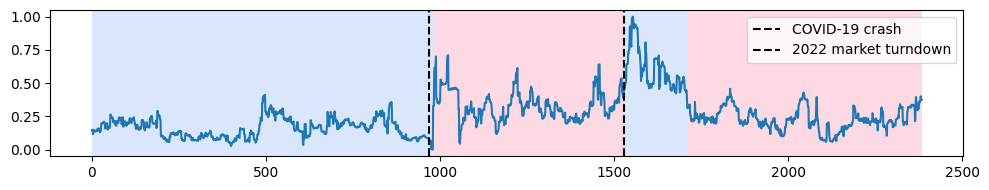

In [45]:
# plot the change points on the L2 norm time series
rpt.display(l2_signal, result)
plt.axvline(covid_index, color='black', linestyle='--', label='COVID-19 crash')
plt.axvline(crash2022_index, color='black', linestyle='--', label='2022 market turndown')
plt.legend()
plt.savefig("plots/covid_etf_norms_changepoints.png", dpi=300)
plt.show()

In [46]:
change_point_dates = [dates[w + cp] for cp in result[:-1]]
print("Detected Change Points Dates:")
for date in change_point_dates:
    print(date)

# print Covid-19 market crash and 2022 market turndown dates
print("COVID-19 market crash date:", dates[covid_index])
print("2022 market turndown date:", dates[crash2022_index])

Detected Change Points Dates:
2020-04-09 00:00:00
2022-06-15 00:00:00
2023-03-06 00:00:00
COVID-19 market crash date: 2019-10-28 00:00:00
2022 market turndown date: 2022-01-19 00:00:00


In [47]:
# compute statistical features on L2 norm time series around Covid-19 crash
window_size = 500
variances = []
avg_spectral_densities = []
firstlags = []

for i in tqdm(range(window_size, len(l2_norms_returns))):
    window = pd.Series(l2_norms_returns[i-window_size:i])
    
    variance = window.var()
    variances.append(variance)
    
    f, Pxx = welch(window.values, fs=1.0)
    low_freq_indices = f < 0.1
    avg_spectral_density = Pxx[low_freq_indices].mean()
    avg_spectral_densities.append(avg_spectral_density)

    # first lag of the Auto-Correlation Function (ACF)
    acf_values = sm.tsa.acf(window.values, nlags=1, fft=True)
    firstlag = acf_values[1].mean()
    firstlags.append(firstlag)

100%|██████████| 1884/1884 [00:00<00:00, 5204.75it/s]


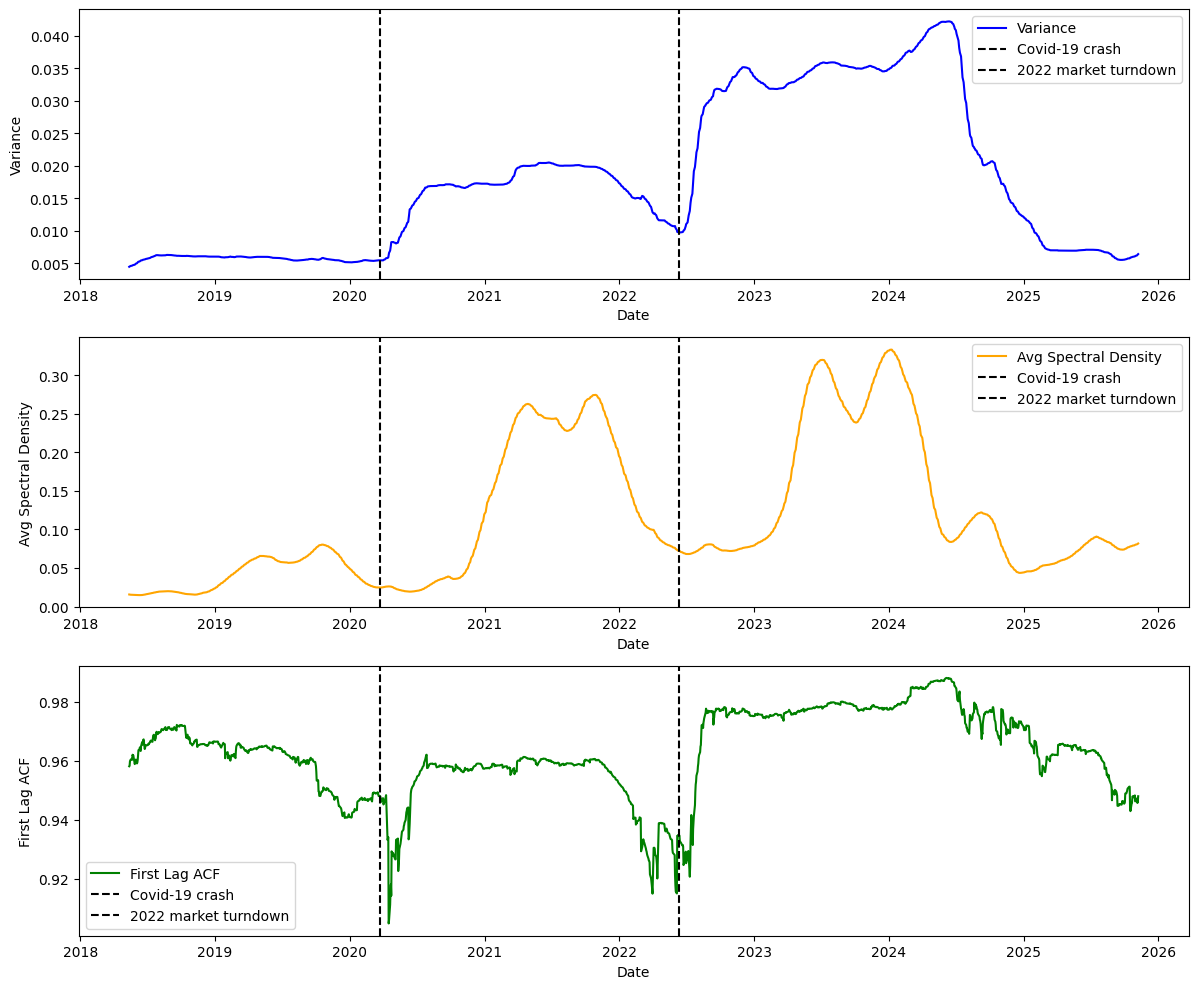

In [48]:
plt.figure(figsize=(12, 10))
plt.subplot(3, 1, 1)
plt.plot(dates[window_size+100:], variances, label='Variance', color='blue')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Variance")
plt.legend()
plt.subplot(3, 1, 2)
plt.plot(dates[window_size+100:], avg_spectral_densities, label='Avg Spectral Density', color='orange')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("Avg Spectral Density")
plt.legend()
plt.subplot(3, 1, 3)
plt.plot(dates[window_size+100:], firstlags, label='First Lag ACF', color='green')
plt.axvline(pd.Timestamp("2020-03-23"), color='black', linestyle='--',  label='Covid-19 crash')
plt.axvline(pd.Timestamp('2022-06-13'), color='black', linestyle='--', label='2022 market turndown')
plt.xlabel("Date")
plt.ylabel("First Lag ACF")
plt.legend()
plt.tight_layout()
plt.savefig("plots/covid_etf_l2_features.png", dpi=300)
plt.show()